# exp05 — diagnostics, sanity checks, and key results

exp05 is the **latent-dynamics axis**: 12 cells x 4 seeds = 48 runs at geometry window=256 / seq_len=16,
sweeping the GRU dynamics weight `lambda_dyn` across modes {off, fwd, fwd+bwd, multistep}.

Two pre-registered criteria (plan `docs/plans/2026-07-22-exp05-dynamics-axis.md`):

| criterion | question | verdict |
|---|---|---|
| **1 — representation** | does weighting the dynamics term up improve the *frozen* representation? | **MET** |
| **2 — learned physics** | does a free-running rollout beat copy-last persistence *on periodic stars more than quiet ones*? | **PARTIAL** |

Criterion 2 is **PARTIAL, not failed and not reversed**: the rollout beats persistence on *every* class
(gain ratio > 1 everywhere, up to 2.7x), so the dynamics do carry real predictive signal — but the
pre-registered *periodic > quiet* ordering did not appear. It is an open improvement target for exp06.

**Structure.** `A` run integrity · `B` latent health + the collapse-reversal mechanism ·
`C` reconstruction + lightcurve panels · `D` UMAP + control baselines · `E` criterion 1 ·
`F` criterion 2 · `G` downstream probe transfer · `H` MIL (pending a separate session).

**Compute contract.** Every heavy artifact is precomputed by scripts; this notebook loads and plots.
Missing artifacts raise immediately rather than silently showing stale numbers.

In [1]:
# --- parameters ---
OFF_CELL = "exp05_comb_off"              # the lambda=0 reference cell (paired baseline for criterion 1)
DYN_CELL = "exp05_comb_fbwd_c1p0"        # the winner: fwd+bwd at lambda=66, the most dim-recruiting cell
PANEL_SEED = 0                           # seed used for the per-star visual panels
CKPT = "best_recon_aux"                  # lambda-independent selection (train.select_include_dyn=false)
N_BOOT_DISPLAY = 2000

In [2]:
import sys, warnings, json, glob, os
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy import stats
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings("ignore")

root = Path(r"C:\git_repo\Stellar-World-Model")
sys.path.insert(0, str(root / "src"))
from swm.models import WorldModel

device = "cuda" if torch.cuda.is_available() else "cpu"
TASKS = ["transit", "eb", "pulsating", "rotation"]
MU_COLS = [f"mu{j}" for j in range(128)]
CURVES = root / "experiments" / "exp05_forensics" / "curves_exp05"
NEWTASK = root / "experiments" / "new_task_exp05"
figs_dir = root / "experiments" / "figs" / "exp05_diagnostics"; figs_dir.mkdir(parents=True, exist_ok=True)

# Fail loud: a missing artifact must stop the notebook, never quietly render stale numbers.
REQUIRED = [root/"experiments"/"exp05_gap.csv", root/"experiments"/"exp05_rollout_summary.csv", CURVES]
missing = [str(p) for p in REQUIRED if not p.exists()]
assert not missing, f"missing artifacts (run the Phase-2 scripts first): {missing}"

print("device", device, "| curves", len(list(CURVES.glob("exp05_*.csv"))), "| figs ->", figs_dir)

device cuda | curves 50 | figs -> C:\git_repo\Stellar-World-Model\experiments\figs\exp05_diagnostics


In [3]:
# --- loaders ---
def load_curve(cell, seed):
    """Per-epoch W&B history for one run, stitching the pre-kill prefix when the run was resumed.

    Two runs (comb_multi_c0p3 seed 3, comb_multi_c1p0 seed 1) were killed and resumed by the sweep
    runner's retry policy, so their finished-run history starts mid-training; the earlier epochs live
    in a separate killed W&B run dumped alongside as *.killedprefix.csv. Both reached epoch 59.
    """
    stem = f"{cell}_B_seed{seed}"
    main = pd.read_csv(CURVES / f"{stem}.csv")
    prefix_path = CURVES / f"{stem}.killedprefix.csv"
    if prefix_path.exists():
        prefix = pd.read_csv(prefix_path)
        prefix = prefix[prefix["epoch"] < main["epoch"].min()]
        main = pd.concat([prefix, main], ignore_index=True).sort_values("epoch").reset_index(drop=True)
        main.attrs["stitched"] = True
    return main


def all_cells():
    """Every exp05 cell name present in the curve dump, ordered comb-then-lpsd, off first."""
    names = sorted({os.path.basename(f).replace(".csv", "").rsplit("_B_seed", 1)[0]
                    for f in glob.glob(str(CURVES / "exp05_*.csv")) if ".killedprefix" not in f})
    order = {"off": 0, "fwd": 1, "fbwd": 2, "multi": 3}
    return sorted(names, key=lambda n: ("lpsd" in n, order.get(n.split("_")[2] if len(n.split("_")) > 2 else "", 9), n))


def cell_label(cell):
    """Short human label: 'fwd+bwd lam1.0' style, for plot axes."""
    part = cell.replace("exp05_", "").replace("comb_", "").replace("lpsd_", "lpsd ")
    return part.replace("fbwd", "fwd+bwd").replace("multi", "multistep").replace("_c", " c")


def load_model(cell, seed=PANEL_SEED, ckpt=CKPT):
    """Trained world model for one exp05 cell/seed (eval mode)."""
    path = root / "experiments" / cell / "models" / f"B_seed{seed}" / f"{ckpt}.pt"
    assert path.exists(), f"missing checkpoint {path}"
    ck = torch.load(path, map_location=device, weights_only=False)
    c = ck["cfg"]
    m = WorldModel(in_ch=c["model"]["in_ch"], enc_channels=c["model"]["enc_channels"],
                   kernel_size=c["model"]["kernel_size"], z_dim=c["model"]["z_dim"],
                   window=int(c["data"]["window"]), gru_hidden=c["model"]["gru_hidden"],
                   gru_layers=c["model"]["gru_layers"]).to(device)
    m.load_state_dict(ck["model"], strict=False); m.eval()
    return m, ck


def make_untrained(cfg, window=256):
    """Capacity-matched random-init encoder -- the reference every gap in this project is measured against."""
    torch.manual_seed(0)  # fixed init -> reproducible untrained baseline
    c = cfg["model"]
    return WorldModel(in_ch=c["in_ch"], enc_channels=c["enc_channels"], kernel_size=c["kernel_size"],
                      z_dim=c["z_dim"], window=window, gru_hidden=c["gru_hidden"],
                      gru_layers=c["gru_layers"]).to(device).eval()


def load_packed(split, window=256):
    """Packed first-segment index + memmap for the frozen v1 subset (shared exp01 geometry)."""
    pk = root / "experiments" / "exp01_window256_seq16" / "packed"
    idx = pd.read_parquet(pk / f"{split}_index.parquet")
    mm = np.memmap(pk / f"{split}_windows.dat", dtype=np.float32, mode="r",
                   shape=(int(idx["n_win"].sum()), window))
    first = idx.sort_values(["tic_id", "sector", "seg_idx"]).drop_duplicates("tic_id").set_index("tic_id")
    return idx, mm, first


subset = pd.read_parquet(root / "processed/subset/subset_tics.parquet")
CELL_NAMES = all_cells()
print(len(CELL_NAMES), "cells:", [cell_label(c) for c in CELL_NAMES])

12 cells: ['off', 'fwd c0p1', 'fwd c0p3', 'fwd c1p0', 'fwd+bwd c0p1', 'fwd+bwd c0p3', 'fwd+bwd c1p0', 'multistep c0p1', 'multistep c0p3', 'multistep c1p0', 'lpsd off', 'lpsd multistep c1p0']


---
## A. Run integrity

Before believing any result: did all 48 runs actually happen, converge, and do what the config asked?
Each check prints a PASS/FAIL line; a FAIL is not fatal here on purpose — two of them are *known* and
their explanation is part of the exp05 record.

In [4]:
# A1 - run inventory: 12 cells x 4 seeds, epochs completed, checkpoint present
rows = []
for cell in CELL_NAMES:
    for seed in range(4):
        curve = load_curve(cell, seed)
        ck_path = root / "experiments" / cell / "models" / f"B_seed{seed}" / f"{CKPT}.pt"
        done = (root / "experiments" / cell / "models" / f"B_seed{seed}" / "DONE.txt").exists()
        rows.append({"cell": cell_label(cell), "seed": seed,
                     "epochs_logged": len(curve), "last_epoch": int(curve["epoch"].max()),
                     "stitched": bool(curve.attrs.get("stitched", False)),
                     "ckpt": ck_path.exists(), "done_marker": done})
inventory = pd.DataFrame(rows)

n_runs, n_full = len(inventory), int((inventory["last_epoch"] == 59).sum())
print(f"runs found        : {n_runs}  (expected 48)")
print(f"reached epoch 59  : {n_full}/{n_runs}   {'PASS' if n_full == n_runs else 'FAIL'}")
print(f"checkpoints on disk: {int(inventory['ckpt'].sum())}/{n_runs}   "
      f"{'PASS' if inventory['ckpt'].all() else 'FAIL'}")
print(f"stitched histories : {int(inventory['stitched'].sum())} (killed+resumed runs, see loader docstring)")
inventory.pivot(index="cell", columns="seed", values="last_epoch")

runs found        : 48  (expected 48)
reached epoch 59  : 48/48   PASS
checkpoints on disk: 48/48   PASS
stitched histories : 2 (killed+resumed runs, see loader docstring)


seed,0,1,2,3
cell,,,,
fwd c0p1,59,59,59,59
fwd c0p3,59,59,59,59
fwd c1p0,59,59,59,59
fwd+bwd c0p1,59,59,59,59
fwd+bwd c0p3,59,59,59,59
fwd+bwd c1p0,59,59,59,59
lpsd multistep c1p0,59,59,59,59
lpsd off,59,59,59,59
multistep c0p1,59,59,59,59


**Read.** All 48 runs reach epoch 59. Two runs (`multistep c0p3` seed 3, `multistep c1p0` seed 1) were
killed mid-training and resumed by the sweep runner's retry-once policy, so their W&B history arrives in
two pieces; the loader stitches them (epochs 0–31 + 32–59 and 0–39 + 40–59, no overlap, no gap). The
*models* were never truncated — only the cloud history was split.

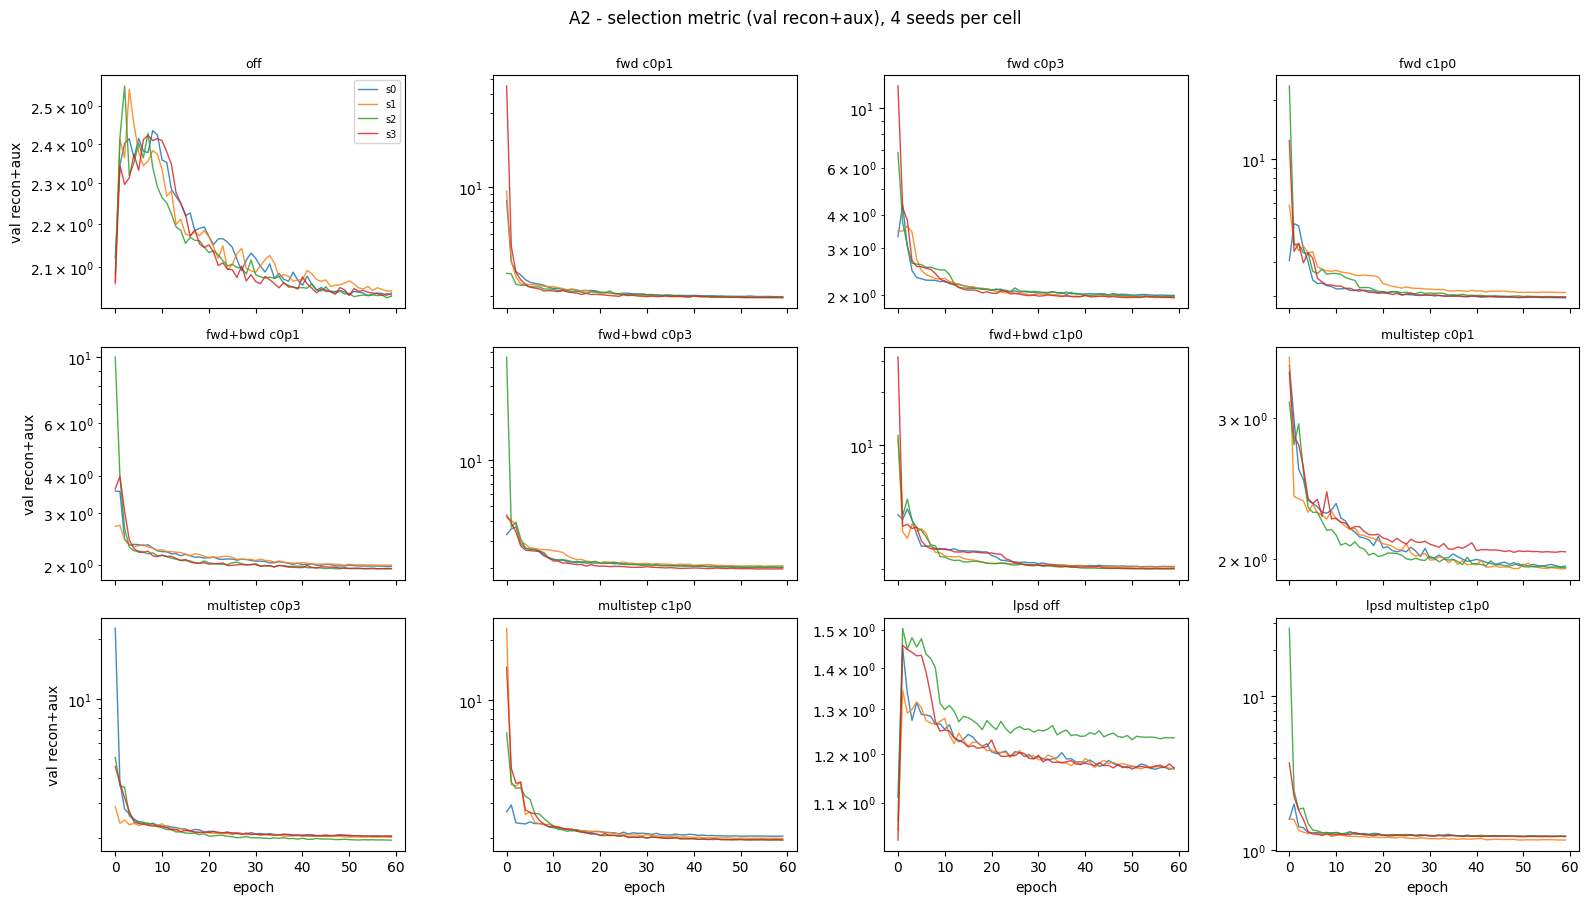

still improving over the last 10 epochs: 44/48 runs (a large fraction means max_epochs=60 truncates training)


In [5]:
# A2 - convergence: the selection metric per cell, and whether it was still improving at the freeze
fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True)
still_improving = []
for ax, cell in zip(axes.ravel(), CELL_NAMES):
    for seed in range(4):
        c = load_curve(cell, seed)
        ax.plot(c["epoch"], c["val/monitor_recon_aux"], lw=1.0, alpha=0.85, label=f"s{seed}")
        tail = c.sort_values("epoch").tail(10)["val/monitor_recon_aux"]
        still_improving.append({"cell": cell_label(cell), "seed": seed,
                                "tail_slope": float(np.polyfit(range(len(tail)), tail, 1)[0])})
    ax.set_title(cell_label(cell), fontsize=9)
    ax.set_yscale("log")
axes[0, 0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("epoch")
for ax in axes[:, 0]:
    ax.set_ylabel("val recon+aux")
fig.suptitle("A2 - selection metric (val recon+aux), 4 seeds per cell", y=1.00)
plt.tight_layout(); fig.savefig(figs_dir / "A2_convergence.png", dpi=120, bbox_inches="tight"); plt.show()

slopes = pd.DataFrame(still_improving)
n_falling = int((slopes["tail_slope"] < 0).sum())
print(f"still improving over the last 10 epochs: {n_falling}/{len(slopes)} runs "
      f"(a large fraction means max_epochs=60 truncates training)")

In [6]:
# A3 - NaN / divergence check across every logged metric
metric_cols = ["train/total", "train/recon", "train/kl_loss", "train/dyn",
               "val/total", "val/recon", "val/monitor_recon_aux", "val/mu_var"]
bad = []
for cell in CELL_NAMES:
    for seed in range(4):
        c = load_curve(cell, seed)
        present = [m for m in metric_cols if m in c.columns]
        n_nan = int(c[present].isna().sum().sum())
        n_inf = int(np.isinf(c[present].to_numpy(dtype=float)).sum())
        if n_nan or n_inf:
            bad.append({"cell": cell_label(cell), "seed": seed, "nan": n_nan, "inf": n_inf})
print(f"runs with NaN/Inf in any logged metric: {len(bad)}   {'PASS' if not bad else 'FAIL'}")
if bad:
    display(pd.DataFrame(bad))

runs with NaN/Inf in any logged metric: 0   PASS


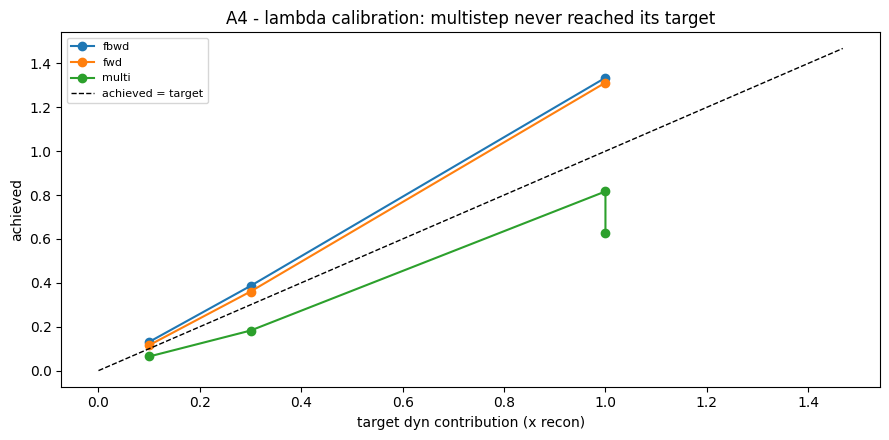

,cell,mode,lambda,target,achieved
3,fwd+bwd c0p1,fbwd,7,0.1,0.1309
4,fwd+bwd c0p3,fbwd,20,0.3,0.3861
5,fwd+bwd c1p0,fbwd,66,1.0,1.3347
0,fwd c0p1,fwd,13,0.1,0.1159
1,fwd c0p3,fwd,40,0.3,0.3605
2,fwd c1p0,fwd,130,1.0,1.3124
8,multistep c0p1,multi,5,0.1,0.0644
9,multistep c0p3,multi,14,0.3,0.1826
6,lpsd multistep c1p0,multi,32,1.0,0.8166
10,multistep c1p0,multi,48,1.0,0.6274


In [7]:
# A4 - did lambda actually buy the dynamics contribution it was calibrated for?
# lambda was set per mode to hit a TARGET contribution {0.1, 0.3, 1.0} x recon. This checks the achieved
# value: contribution = lambda_dyn * dyn / recon, averaged over the post-warmup steady epochs.
LAMBDA = {"exp05_comb_off": 0, "exp05_comb_fwd_c0p1": 13, "exp05_comb_fwd_c0p3": 40,
          "exp05_comb_fwd_c1p0": 130, "exp05_comb_fbwd_c0p1": 7, "exp05_comb_fbwd_c0p3": 20,
          "exp05_comb_fbwd_c1p0": 66, "exp05_comb_multi_c0p1": 5, "exp05_comb_multi_c0p3": 14,
          "exp05_comb_multi_c1p0": 48, "exp05_lpsd_off": 0, "exp05_lpsd_multi_c1p0": 32}
TARGET = {"c0p1": 0.1, "c0p3": 0.3, "c1p0": 1.0}

rows = []
for cell in CELL_NAMES:
    tgt = next((v for k, v in TARGET.items() if cell.endswith(k)), 0.0)
    for seed in range(4):
        c = load_curve(cell, seed).query("epoch >= 15")  # post beta-warmup steady state
        achieved = float((LAMBDA[cell] * c["train/dyn"] / c["train/recon"]).mean())
        rows.append({"cell": cell_label(cell), "mode": cell.split("_")[2] if len(cell.split("_")) > 2 else "off",
                     "lambda": LAMBDA[cell], "target": tgt, "achieved": achieved, "seed": seed})
calib = pd.DataFrame(rows).groupby(["cell", "mode", "lambda", "target"], as_index=False)["achieved"].mean()
calib = calib[calib["lambda"] > 0].sort_values(["mode", "lambda"])

fig, ax = plt.subplots(figsize=(9, 4.5))
for mode, grp in calib.groupby("mode"):
    ax.plot(grp["target"], grp["achieved"], "o-", label=mode)
lim = [0, max(calib["target"].max(), calib["achieved"].max()) * 1.1]
ax.plot(lim, lim, "k--", lw=1, label="achieved = target")
ax.set_xlabel("target dyn contribution (x recon)"); ax.set_ylabel("achieved")
ax.set_title("A4 - lambda calibration: multistep never reached its target")
ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(figs_dir / "A4_lambda_calibration.png", dpi=120, bbox_inches="tight"); plt.show()
display(calib.round(4))

#### Plain-English read of A4

**The training loss has two jobs:** `total = recon + λ · dyn`

- `recon` — rebuild the light-curve window from the latent (the autoencoder's job).
- `dyn` — predict the *next* latent from the current one (the GRU's job — the "learned physics" part
  that exp05 exists to test).

**`lambda` (λ)** is the raw knob we type into the config: how hard to weight `dyn`. On its own it means
nothing — λ=48 is only "big" or "small" relative to how big the `dyn` number happens to be. The three
modes (`fwd`, `fwd+bwd`, `multistep`) each compute `dyn` a different way, so their λ values are **not**
comparable to each other.

**Contribution** is the interpretable version of λ:

> `contribution = λ · dyn / recon` = "the dynamics term is this many times as loud as reconstruction."

`0.1` = dynamics is a 10% side-penalty. `1.0` = dynamics and reconstruction are equal partners.

- **`target`** = the loudness we *asked for*. exp05 sweeps three rungs {0.1, 0.3, 1.0}; λ was back-solved
  from a short pilot measurement so that each mode would land on each rung.
- **`achieved`** = the loudness we *actually got*, recomputed here from the real training logs
  (epochs ≥ 15, i.e. after the β-warmup settles).

**How to read the picture.** x-axis = what we asked for, y-axis = what we got, dashed line = "got exactly
what we asked for". A mode sitting *on* the dashed line is correctly calibrated; *above* means the
dynamics term ran louder than intended, *below* means quieter. `fwd` and `fwd+bwd` sit above the line
(~1.3× too loud — tolerable). **`multistep` (green) sits below the line at every rung.**

**The problem this exposes.** The multistep grid is systematically **mis-dosed**. Its achieved/target
ratio is 0.64 / 0.61 / 0.63 across the three rungs — a *constant* ~0.63× under-scaling, **not** a ceiling
the model runs into (its raw `dyn` moves only 2%, 0.01244 → 0.01269, while λ rises 10× from 5 to 48).
So the cell labelled "multistep at contribution 1.0" really trained at 0.63 — in between the other modes'
0.3 and 1.0 rungs.

That **confounds** the multistep verdict: when multistep scores worse on criterion 1, we cannot separate
"rollout is a weaker training objective" from "rollout was simply given a smaller dose". Fixable on a
rerun by calibrating λ from the steady-state `dyn` instead of a short pilot — or, with the runs we
already have, by comparing cells at matched **achieved** contribution rather than at matched target.

**Known finding, carried openly.** `multistep` never achieved its calibrated dynamics contribution — a
flat ~0.63× of target at every rung, while `fwd` and `fwd+bwd` overshoot by ~1.3×. This matters for
interpretation: the multistep cells are **not** a clean test of "high λ", so their weaker criterion-1
result is partly a calibration failure, not only a modelling one.

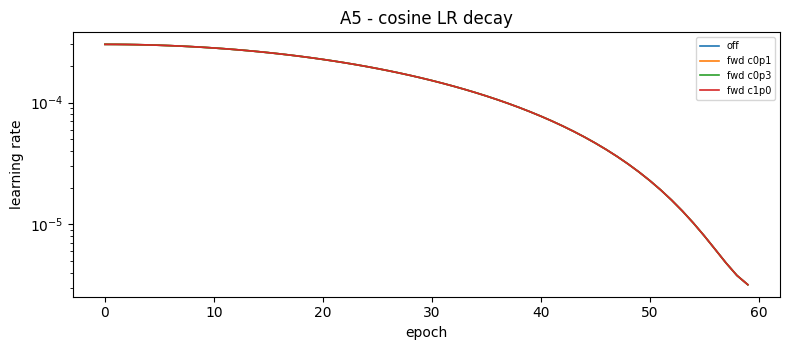

LR 3.00e-04 -> 3.20e-06  (ratio 94x)   PASS cosine ran


In [8]:
# A5 - cosine LR schedule actually ran
fig, ax = plt.subplots(figsize=(8, 3.6))
for cell in CELL_NAMES[:4]:
    c = load_curve(cell, 0)
    ax.plot(c["epoch"], c["lr"], lw=1.2, label=cell_label(cell))
ax.set_xlabel("epoch"); ax.set_ylabel("learning rate"); ax.set_yscale("log")
ax.set_title("A5 - cosine LR decay"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

lr0 = load_curve(CELL_NAMES[0], 0)["lr"]
print(f"LR {lr0.iloc[0]:.2e} -> {lr0.iloc[-1]:.2e}  (ratio {lr0.iloc[0]/lr0.iloc[-1]:.0f}x)   "
      f"{'PASS cosine ran' if lr0.iloc[-1] < lr0.iloc[0] / 10 else 'FAIL schedule flat'}")

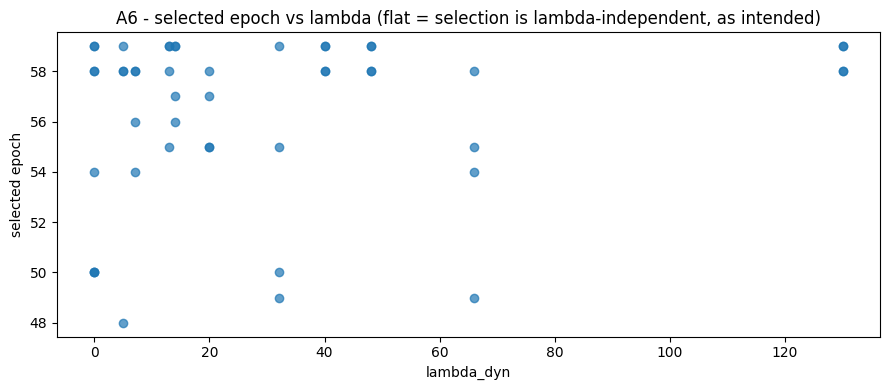

Spearman(lambda, selected_epoch) = +0.155  (p=0.294)
selected epoch: median 58, range 48-59


,min,median,max
cell,,,
fwd c0p1,55,58.5,59
fwd c0p3,58,58.5,59
fwd c1p0,58,58.5,59
fwd+bwd c0p1,54,57.0,58
fwd+bwd c0p3,55,56.0,58
fwd+bwd c1p0,49,54.5,58
lpsd multistep c1p0,49,52.5,59
lpsd off,50,54.0,59
multistep c0p1,48,58.0,59


In [9]:
# A6 - checkpoint selection under the new lambda-independent gate (train.select_include_dyn=false)
# If selection were still lambda-dependent, high-lambda cells would systematically freeze at a different
# epoch than lambda=0 -- the exact pathology the flag was added to remove.
rows = []
for cell in CELL_NAMES:
    for seed in range(4):
        p = root / "experiments" / cell / "models" / f"B_seed{seed}" / f"{CKPT}.pt"
        ck = torch.load(p, map_location="cpu", weights_only=False)
        rows.append({"cell": cell_label(cell), "lam": LAMBDA[cell], "seed": seed,
                     "selected_epoch": int(ck["epoch"])})
sel = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(sel["lam"], sel["selected_epoch"], alpha=0.7)
ax.set_xlabel("lambda_dyn"); ax.set_ylabel("selected epoch")
ax.set_title("A6 - selected epoch vs lambda (flat = selection is lambda-independent, as intended)")
plt.tight_layout(); plt.show()

corr = stats.spearmanr(sel["lam"], sel["selected_epoch"])
print(f"Spearman(lambda, selected_epoch) = {corr.statistic:+.3f}  (p={corr.pvalue:.3f})")
print(f"selected epoch: median {sel['selected_epoch'].median():.0f}, "
      f"range {sel['selected_epoch'].min()}-{sel['selected_epoch'].max()}")
display(sel.groupby("cell")["selected_epoch"].agg(["min", "median", "max"]))

Noted: all experiments reach epoch 59, epoch 59th is not necessarily the best checkpoint (the "best" is based on `total = recon + λ · dyn`)

---
## B. Latent health and the collapse-reversal mechanism

This is exp05's *mechanistic* result. The `comb` recipe (free_bits 0) collapses to ~5 active latent
units at λ=0. Weighting the one-step dynamics term up **recruits dimensions back** — on the 4-seed mean,
17 active at `fwd λ=130`, 25 at `fwd+bwd λ=66`. More live dimensions → more directions a *linear* readout can
combine → the criterion-1 gain. (Total KL barely moves, so this is the same information spread
over more axes, not more information — see the note under B1.) `multistep` does **not** recruit (stays ~5, and its λ never scaled — see A4), and
the `lpsd` recipe (free_bits 0.02) holds all 128 units throughout, so it has no collapse to reverse.

**Read the error bars.** The recruitment is highly **seed-variable**: `fwd+bwd λ66` is 25.5 ± 15.0 units
and `fwd λ130` is 17.3 ± 13.6 across 4 seeds, versus 5.0 ± 0.0 at λ=0. So "high λ sometimes escapes the
collapse" is better supported than "high λ reliably recruits ~25 dimensions" — the direction is solid,
the magnitude is not a stable quantity.

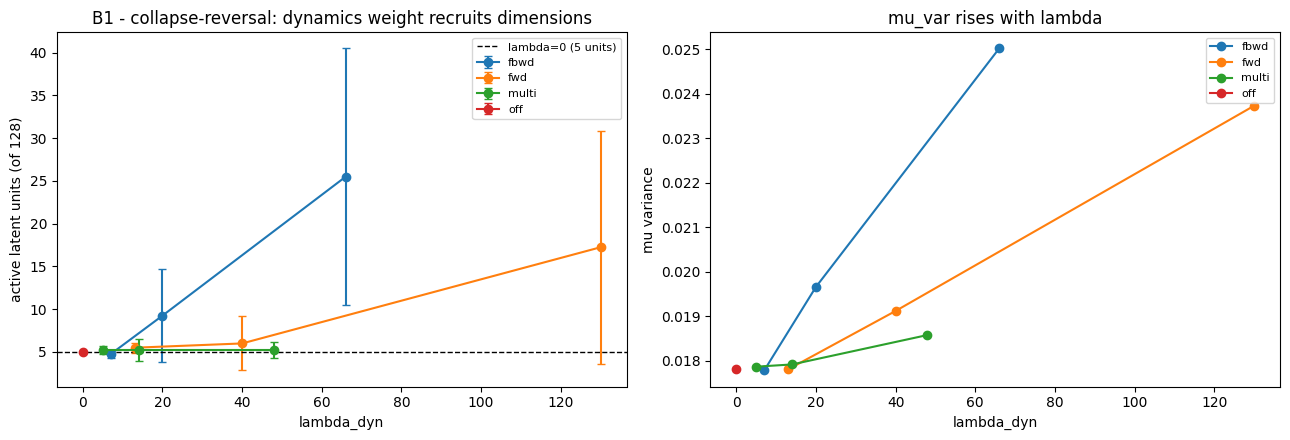

,recipe,mode,lam,n_active,n_active_sd,mu_var
0,comb,fbwd,7,4.75,0.500,0.018
1,comb,fbwd,20,9.25,5.439,0.020
2,comb,fbwd,66,25.50,15.000,0.025
3,comb,fwd,13,5.50,0.577,0.018
4,comb,fwd,40,6.00,3.162,0.019
5,comb,fwd,130,17.25,13.598,0.024
6,comb,multi,5,5.25,0.500,0.018
7,comb,multi,14,5.25,1.258,0.018
8,comb,multi,48,5.25,0.957,0.019
9,comb,off,0,5.00,0.000,0.018



per-seed spread in active units (comb recipe) -- the recruitment is real but highly seed-variable:


,mean,std,min,max
cell,,,,
fwd c0p1,5.50,0.58,5.0,6.0
fwd c0p3,6.00,3.16,3.0,10.0
fwd c1p0,17.25,13.60,6.0,37.0
fwd+bwd c0p1,4.75,0.50,4.0,5.0
fwd+bwd c0p3,9.25,5.44,5.0,17.0
fwd+bwd c1p0,25.50,15.00,9.0,41.0
multistep c0p1,5.25,0.50,5.0,6.0
multistep c0p3,5.25,1.26,4.0,7.0
multistep c1p0,5.25,0.96,4.0,6.0


In [10]:
# B1 - THE mechanism panel: active latent units vs lambda, per mode
rows = []
for cell in CELL_NAMES:
    mode = "off" if cell.endswith("_off") else cell.split("_")[2]
    recipe = "lpsd" if "lpsd" in cell else "comb"
    for seed in range(4):
        c = load_curve(cell, seed)
        last = c.sort_values("epoch").iloc[-1]
        # cell_raw matches the `cell` column of exp05_gap.csv, so E4 can join on (recipe, cell_raw)
        cell_raw = cell.replace("exp05_comb_", "").replace("exp05_lpsd_", "")
        rows.append({"cell": cell_label(cell), "cell_raw": cell_raw, "recipe": recipe, "mode": mode,
                     "lam": LAMBDA[cell], "seed": seed, "n_active": float(last["val/n_active_units"]),
                     "mu_var": float(last["val/mu_var"])})
latent = pd.DataFrame(rows)
agg = latent.groupby(["recipe", "mode", "lam"], as_index=False).agg(
    n_active=("n_active", "mean"), n_active_sd=("n_active", "std"),
    mu_var=("mu_var", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
comb = agg[agg["recipe"] == "comb"]
for mode, grp in comb.groupby("mode"):
    grp = grp.sort_values("lam")
    axes[0].errorbar(grp["lam"], grp["n_active"], yerr=grp["n_active_sd"], marker="o", capsize=3, label=mode)
    axes[1].plot(grp["lam"], grp["mu_var"], "o-", label=mode)
off_n = float(comb[comb["mode"] == "off"]["n_active"].iloc[0])
axes[0].axhline(off_n, color="k", ls="--", lw=1, label=f"lambda=0 ({off_n:.0f} units)")
axes[0].set_xlabel("lambda_dyn"); axes[0].set_ylabel("active latent units (of 128)")
axes[0].set_title("B1 - collapse-reversal: dynamics weight recruits dimensions")
axes[1].set_xlabel("lambda_dyn"); axes[1].set_ylabel("mu variance")
axes[1].set_title("mu_var rises with lambda")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(figs_dir / "B1_collapse_reversal.png", dpi=120, bbox_inches="tight"); plt.show()
display(agg.round(3))

# The mean tells a clean story; the spread does not. Report both.
spread = latent[latent["recipe"] == "comb"].groupby("cell")["n_active"].agg(["mean", "std", "min", "max"])
print("\nper-seed spread in active units (comb recipe) -- the recruitment is real but highly seed-variable:")
display(spread.round(2))

#### Plain-English read of B1

**The three columns.**

- **`lam`** — the same λₑᵧₙ knob from A4 (the raw config weight on the dynamics loss), repeated
  here so each cell can be placed on the x-axis.
- **`n_active`** — how many of the 128 latent dimensions actually *carry information* at the final
  epoch (`val/n_active_units`).
- **`mu_var`** — `val/mu_var`: the variance of the **entire** μ tensor, pooled over all stars × all
  timesteps × all 128 dims into one scalar. A crude "has the latent spread out, or is it still a
  point?" monitor. It is *not* per-dimension, so a rise can come from a few dims getting louder
  rather than from many dims waking up — which is why `n_active` is the panel that matters.

**How `n_active` is computed** (`src/swm/train/losses.py:88-93` → `src/swm/train/loop.py:153`):

```
for each latent dim j in 0..127:
    kl_per_dim[j]  = mean over (batch, timestep) of
                     0.5 * ( mu[j]**2 + exp(logvar[j]) - logvar[j] - 1 )
    kl_dim_mean[j] = average of kl_per_dim[j] over all validation batches

n_active = count of j where kl_dim_mean[j] > 0.01     # train.active_unit_kl_threshold
```

That inner expression is `KL( encoder's Gaussian for dim j || N(0,1) )` in nats — "how far does this
dimension stray from the prior it is regularised toward?"

**Should it be 128?** No. **128 is the *capacity* (`model.z_dim`); `n_active` is how much of that
capacity the model actually chose to use.** A dimension that has given up outputs μ≈0, logvar≈0 for
*every* star, giving KL = 0.5·(0 + 1 − 0 − 1) = **0** — it ignores the input and returns the prior. It
hands the decoder the same number for every star, so it is worthless to a probe too. Below the 0.01-nat
threshold it is counted dead.

**What drives it below 128 — posterior collapse.** The loss contains β·KL, so the optimizer is *paid*
to shrink KL, and the cheapest way is to switch dimensions off entirely. The `comb` recipe sets
`free_bits = 0.0`, i.e. **no floor stopping that**, so it funnels everything into ~5 dims and lets the
other 123 die. Raising λₑᵧₙ makes the GRU's next-step prediction matter enough that a richer latent
trajectory pays for itself, which pushes dimensions back on — exp05's **collapse-reversal**.

**Two caveats this panel does not show on its face:**

**(a) The recruitment is redistribution, not enrichment.** Total KL is nearly flat while `n_active`
grows 5× — the same ~2.4 nats simply get spread over more axes:

| cell | n_active | total KL (nats) | KL per active dim |
|---|---|---|---|
| `off` λ=0 | 5.00 | 2.365 | 0.473 |
| `fwd` λ=130 | 17.25 | 2.487 | 0.144 |
| `fwd+bwd` λ=66 | 25.50 | 2.469 | 0.097 |
| `lpsd off` | 128.00 | 2.927 | 0.023 |

So λ does **not** make the latent carry more information (+4% total KL). It gives a *linear* readout
more usable directions to combine — which is a real benefit, but a weaker claim than "richer latent".

**(b) `lpsd`'s 128/128 is close to an artifact.** `free_bits = 0.02` clamps the per-dim KL *in the
loss*, so once a dim falls below 0.02 nats the KL gradient stops squeezing it and it parks there —
above the 0.01 counting threshold. All 128 therefore count as "active" while each carries ~0.02 nats,
i.e. almost nothing. Do **not** read `lpsd`'s 128 as a richer latent than `fwd+bwd`'s 25.

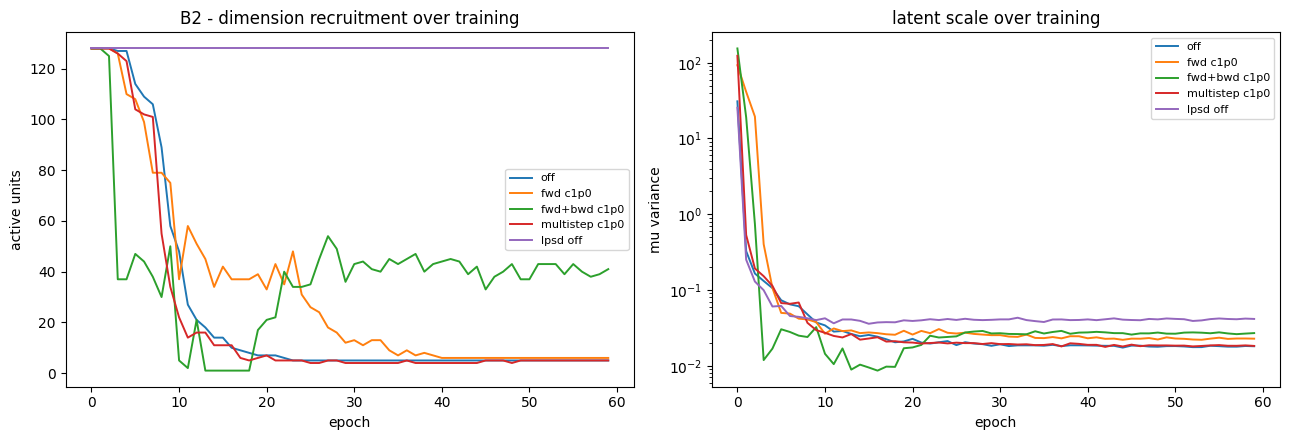

In [11]:
# B2 - per-epoch trajectory: when during training do the dimensions get recruited?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
focus = [OFF_CELL, "exp05_comb_fwd_c1p0", DYN_CELL, "exp05_comb_multi_c1p0", "exp05_lpsd_off"]
for cell in focus:
    if cell not in CELL_NAMES:
        continue
    c = load_curve(cell, PANEL_SEED)
    axes[0].plot(c["epoch"], c["val/n_active_units"], lw=1.4, label=cell_label(cell))
    axes[1].plot(c["epoch"], c["val/mu_var"], lw=1.4, label=cell_label(cell))
axes[0].set_ylabel("active units"); axes[1].set_ylabel("mu variance")
axes[1].set_yscale("log")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(fontsize=8)
axes[0].set_title("B2 - dimension recruitment over training")
axes[1].set_title("latent scale over training")
plt.tight_layout(); fig.savefig(figs_dir / "B2_latent_trajectory.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of B2

Think of the latent as a **128-box form** the encoder fills in to describe each star. The two subplots
watch two different ways that form can fail:

- **left — active units:** how many boxes anyone ever bothers to fill in (same KL counting rule as B1,
  now recomputed every epoch).
- **right — `mu` variance:** how *different* the entries are between stars. One scalar pooled over all
  stars × timesteps × dims.

You need both. A form where 123 boxes always read `0` is useless (collapse); so is a form where every
box reads `0.001` for every star (no scale). Either way you cannot tell two stars apart.

**Left subplot — collapse, watched live.** Every `comb` run *starts* at 128/128, because a randomly
initialised encoder puts something different in every box. Then it **crashes to ~5 within ~20 epochs**.
That crash *is* posterior collapse.

- `off` (blue) and `multistep` (red) fall to ~5 and stay dead.
- `fwd` (orange) climbs back to ~40 around epoch 20 — then **relapses** to ~5 by epoch 40.
- `fwd+bwd` (green) collapses *hardest* (down to ~1–2 near epoch 15), then **climbs back to ~40 and
  holds** for the rest of training. This is the strongest visual evidence for collapse-*reversal*: a
  genuine recovery, not merely a failure to collapse.
- `lpsd` (purple) is pinned at 128 only because `free_bits = 0.02` parks every dim above the 0.01
  counting threshold (see note (b) under B1). It is **not** a healthy-latent trophy.

**Right subplot — don't misread the cliff.** `mu_var` falls ~4 orders of magnitude in the first ~5
epochs. That drop is **expected and healthy**, not the collapse: a random encoder emits huge
unnormalised μ, and the KL term pulls the posterior toward N(0,1) scale. What matters is *where it
flattens* — at ~0.02, i.e. μ has sd ~0.14 against the prior's 1.0, so the latent settles much
"quieter" than its prior. Higher λ lifts that plateau slightly (green/orange above blue/red).

**So is the latent unhealthy?** For the `comb` recipe, **yes — and that is the premise of the
experiment, not a bug in it.** 123 of 128 dimensions are dead by epoch 20 at λ=0. exp05's claim is
never "the latent is healthy"; it is "turning λ up partially rescues it". The green curve is that
evidence. But the rescue is partial (it never returns to 128) and mode-dependent (`fwd` relapses,
`multistep` never recovers at all).

In [12]:
# B3 - per-dimension latent health on the 3 panel arms (ported from model_diagnostics section D)
# Loads the cached first-segment window-mu the scorecard uses, so no encoder pass runs here.
def load_subset_mu(arm):
    """{split: (tics, per-star window-mu blocks)} from the staged v1-subset cache."""
    path = NEWTASK / "subset_mu_cache" / f"{arm}.npz"
    assert path.exists(), f"missing {path} -- run the Phase-2 staging step"
    payload = np.load(path, allow_pickle=False)
    out = {}
    for split in ["train", "test"]:
        flat, counts = payload[f"{split}_mu"], payload[f"{split}_counts"]
        tics = payload[f"{split}_tics"].tolist()
        blocks, start = [], 0
        for n in counts:
            blocks.append(flat[start:start + int(n)]); start += int(n)
        out[split] = (tics, blocks)
    return out


def star_mu_frame(arm):
    """Per-star mean-pooled mu joined to the v1 labels (test split)."""
    mu = load_subset_mu(arm)
    tics, blocks = mu["test"]
    pooled = np.vstack([b.mean(axis=0) for b in blocks])
    df = pd.DataFrame(pooled, columns=MU_COLS)
    df.insert(0, "tic_id", [int(t) for t in tics])
    return df.merge(subset[["tic_id"] + TASKS], on="tic_id")


PANEL_ARMS = {"untrained": "untrained",
              f"off (lam 0)": f"comb_off_s{PANEL_SEED}",
              f"fwd+bwd (lam 66)": f"comb_fbwd_c1p0_s{PANEL_SEED}"}
panel_mu = {label: star_mu_frame(arm) for label, arm in PANEL_ARMS.items()}
print({k: v.shape for k, v in panel_mu.items()})

{'untrained': (2021, 133), 'off (lam 0)': (2021, 133), 'fwd+bwd (lam 66)': (2021, 133)}


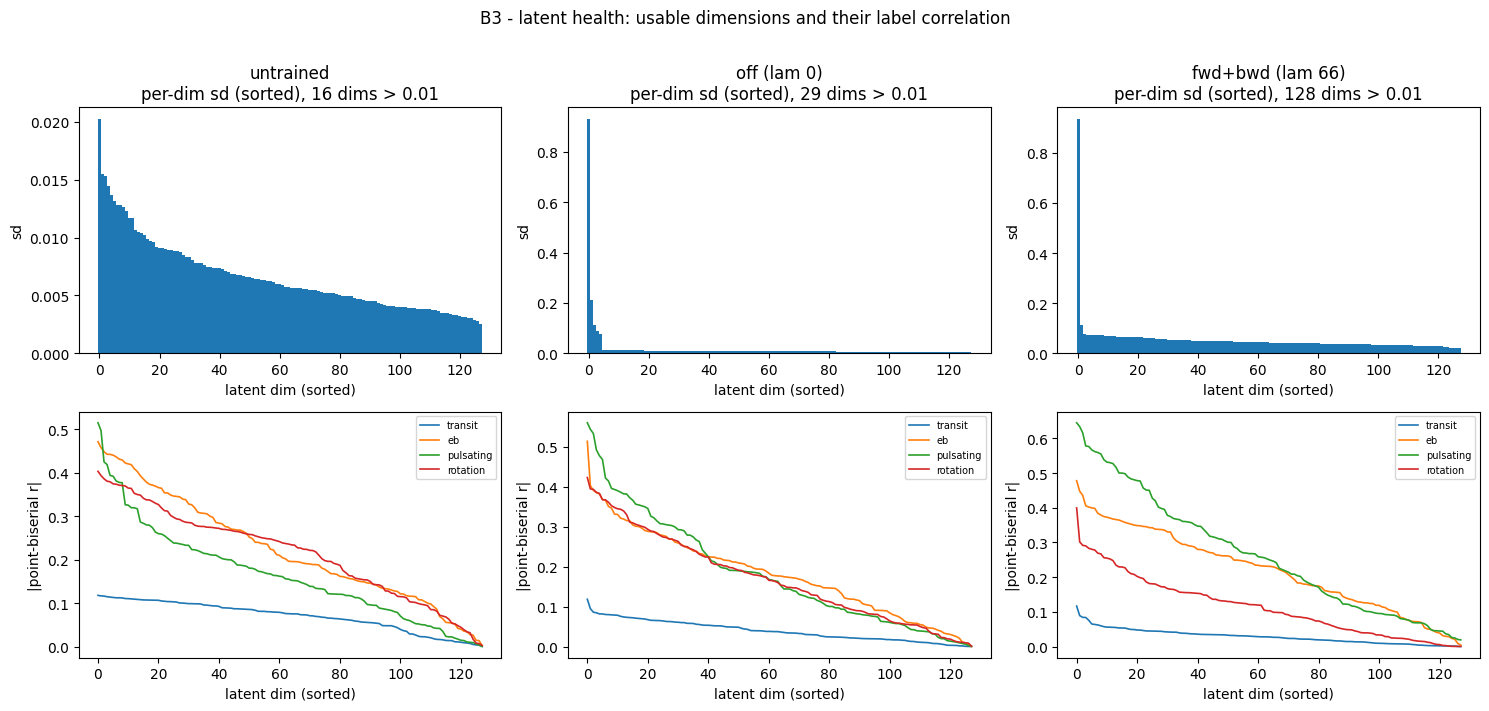

In [13]:
# B3 (plot) - per-dim latent standard deviation + point-biserial correlation with each task label
def pointbiserial_per_dim(mu, label):
    """Point-biserial correlation of each latent dim with a binary label."""
    return np.array([stats.pointbiserialr(label, mu[:, d]).correlation for d in range(mu.shape[1])])


fig, axes = plt.subplots(2, len(panel_mu), figsize=(5 * len(panel_mu), 7))
for j, (label, df) in enumerate(panel_mu.items()):
    mu = df[MU_COLS].to_numpy()
    sd = mu.std(axis=0)
    order = np.argsort(sd)[::-1]
    axes[0, j].bar(range(len(sd)), sd[order], width=1.0)
    axes[0, j].set_title(f"{label}\nper-dim sd (sorted), {(sd > 0.01).sum()} dims > 0.01")
    axes[0, j].set_xlabel("latent dim (sorted)"); axes[0, j].set_ylabel("sd")
    for task in TASKS:
        y = df[task].to_numpy()
        if len(np.unique(y)) < 2:
            continue
        corr = np.abs(pointbiserial_per_dim(mu, y))
        axes[1, j].plot(np.sort(corr)[::-1], lw=1.2, label=task)
    axes[1, j].set_xlabel("latent dim (sorted)"); axes[1, j].set_ylabel("|point-biserial r|")
    axes[1, j].legend(fontsize=7)
fig.suptitle("B3 - latent health: usable dimensions and their label correlation", y=1.01)
plt.tight_layout(); fig.savefig(figs_dir / "B3_latent_health.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of B3

**First, what this panel is computed on — it differs from B1/B2.** B3 uses **star-level pooled μ on the
test split**: 2,021 stars, each collapsed to the mean of its window-μ vectors. B1/B2 measured
*per-window* μ during validation. Same latent, different aggregation — so the counts here are **not**
comparable to B1's active-unit counts, and the `0.01` in the titles is an sd in μ units, *not* B1's
0.01-nat KL threshold. Two different quantities that happen to share a number.

**1. What "per-dim sd" means.** Take one latent dimension, read its value for all 2,021 stars, and take
the standard deviation **across stars**. It asks: *does this dimension change from star to star?*

| | values for 4 stars | sd |
|---|---|---|
| dim A | 0.50, 0.50, 0.50, 0.50 | **0.000** |
| dim B | −1.20, 0.10, 0.90, −0.30 | **0.756** |

sd ≈ 0 means the dim hands back the same number for every star — a constant column, useless to any
probe. The top row sorts all 128 dims by this sd, so each bar chart is a profile of *where the
representation's variety lives*.

**2. What "|point-biserial r|" means.** Point-biserial r is just the ordinary **Pearson correlation**
between a **binary** variable (the 0/1 label, e.g. `eb`) and a **continuous** one (that dim's value).
Identical formula; the name only signals that one side is binary. |r| = 0 → this dim tells you nothing
about whether the star is an EB; |r| = 1 → this dim alone separates EBs perfectly. The bottom row sorts
the 128 |r| values descending, once per task.

**3. Reading the plot — and two traps.**

**Trap A: the top-row titles (16 / 29 / 128 dims > 0.01) are largely a *scale* artifact.** The three
y-axes differ by ~46× and `0.01` is an **absolute** cutoff. Untrained's *largest* sd is 0.0203 — barely
above the cutoff — while both trained arms have a dim at 0.93. Scale-free measures reverse the reading:

| arm | max sd | dims > 1% of max | effective dims |
|---|---|---|---|
| untrained | 0.020 | 128 | **59.3** |
| `off` (λ=0) | 0.931 | 35 | **1.19** |
| `fwd+bwd` (λ=66) | 0.935 | 128 | **1.79** |

*Effective dims* = participation ratio = `(Σ var)² / Σ var²`, which is invariant to rescaling. By that
measure **both trained arms are dominated by a single dimension** — `mu105` for `off`, `mu17` for
`fwd+bwd`, each with sd ~0.93 against a next-largest of 0.21 and 0.11. λ moves effective dims
**1.19 → 1.79**, the direction B1 claims, but at star level the representation is still only *one to two
effective dimensions*. That dominant dim is broad rather than outlier-driven (sd/IQR ≈ 0.6) and
correlates moderately with everything (rotation 0.40, eb 0.35, pulsating 0.28) — it behaves like a
generic "how variable is this star" axis.

**Trap B: the bottom row is a *marginal* view, not a probe forecast.** Measured peak |r| / #dims with
|r| > 0.2 / Σr²:

| task | untrained | `off` (λ=0) | `fwd+bwd` (λ=66) |
|---|---|---|---|
| transit | 0.118 / 0 / 0.77 | 0.119 / 0 / 0.28 | 0.117 / 0 / 0.17 |
| eb | 0.472 / 63 / 8.30 | 0.514 / 55 / 5.60 | 0.478 / 72 / 7.87 |
| pulsating | 0.515 / 45 / 5.00 | 0.561 / 44 / 6.65 | **0.645 / 75 / 12.46** |
| rotation | 0.404 / 75 / 7.26 | 0.423 / 47 / 5.20 | 0.400 / 21 / 2.60 |

- **The untrained encoder already peaks at |r| ≈ 0.47–0.52.** A strong single-dim correlation is *not*
  evidence of learning — a random projection of an informative signal correlates too. Only the
  *comparison across the three panels* carries information.
- **`pulsating` is the clear win**: higher peak *and* a fatter tail (75 dims above 0.2 vs 44/45).
- **`transit` is flat at ~0.118 in all three** and its total signal *falls* — consistent with the known
  result that transit is not recoverable from star-pooled μ.
- **`rotation` moves the *wrong* way here** (breadth 75 → 47 → 21) even though rotation is exp05's
  **largest** criterion-1 gain. There is no contradiction: B3 is **marginal** (one dim at a time) while
  the probe is **multivariate** (all 128 dims combined). Two dims can each be individually useless and
  jointly perfect — e.g. `x₁` = noise and `x₂` = the same noise + a small label offset give |r| = 0.01
  and 0.16 alone, but |r| = 1.00 for `x₂ − x₁`. A linear probe finds that difference; these per-dim
  curves never can.

**So is the latent unhealthy?** At star level, **yes in a specific way**: variance is concentrated in
one to two effective dimensions, and single-dim label correlations are barely better than a random
encoder's for three of the four tasks. λ clearly improves `pulsating`, mildly improves effective
dimensionality, and does not help `rotation` *on this view*. That is compatible with exp05's actual
headline — a real but modest criterion-1 gain — and it rules out any stronger reading.

---
## C. Reconstruction and lightcurve inspection

Ported from `model_diagnostics.ipynb` (§B) and `ablation_diagnostics.ipynb` (Leg 1), with the old A/B/C
variant axis replaced by the three arms that make exp05's mechanism visible:
**untrained** (random encoder) → **off** (λ=0, ~5 active dims) → **fwd+bwd** (λ=66, ~25 active dims).

The question these panels answer: *what did the recruited dimensions buy?* If dimension recruitment is
real and useful, the λ=66 reconstruction should track structure that the λ=0 reconstruction smooths away.

**Random-sample cells draw a fresh star on every re-run** (repo convention); the seeded line is present
but commented out so replication is opt-in.

In [14]:
# C0 - models + packed memmaps for the three panel arms
model_off, ck_off = load_model(OFF_CELL, PANEL_SEED)
model_dyn, ck_dyn = load_model(DYN_CELL, PANEL_SEED)
model_unt = make_untrained(ck_off["cfg"], window=int(ck_off["cfg"]["data"]["window"]))
PANEL_MODELS = {"untrained": model_unt, "off (lam 0)": model_off, "fwd+bwd (lam 66)": model_dyn}

test_idx, test_mm, test_first = load_packed("test")
test_lab = subset[subset["split"] == "test"]
print("test stars packed:", len(test_first), "| window", int(ck_off["cfg"]["data"]["window"]))


def first_seg_input_recon(model, tic):
    """(input_lc, recon_lc) for a star's first test segment, decoded by one model."""
    r = test_first.loc[tic]
    blk = np.array(test_mm[int(r["row_start"]):int(r["row_start"]) + int(r["n_win"])], dtype=np.float32)
    x = torch.from_numpy(blk).unsqueeze(-1).to(device)
    with torch.no_grad():
        mu, _ = model.encoder(x)
        rec = model.decoder(mu)
    return blk.reshape(-1), rec[:, :, 0].cpu().numpy().reshape(-1)


def psd(x):
    return np.abs(np.fft.rfft(x - x.mean())) ** 2

test stars packed: 2021 | window 256


example stars: [(424388628, 'transit'), (22937402, 'eb'), (374413070, 'pulsating'), (229751802, 'rotation'), (353893010, 'quiet')]


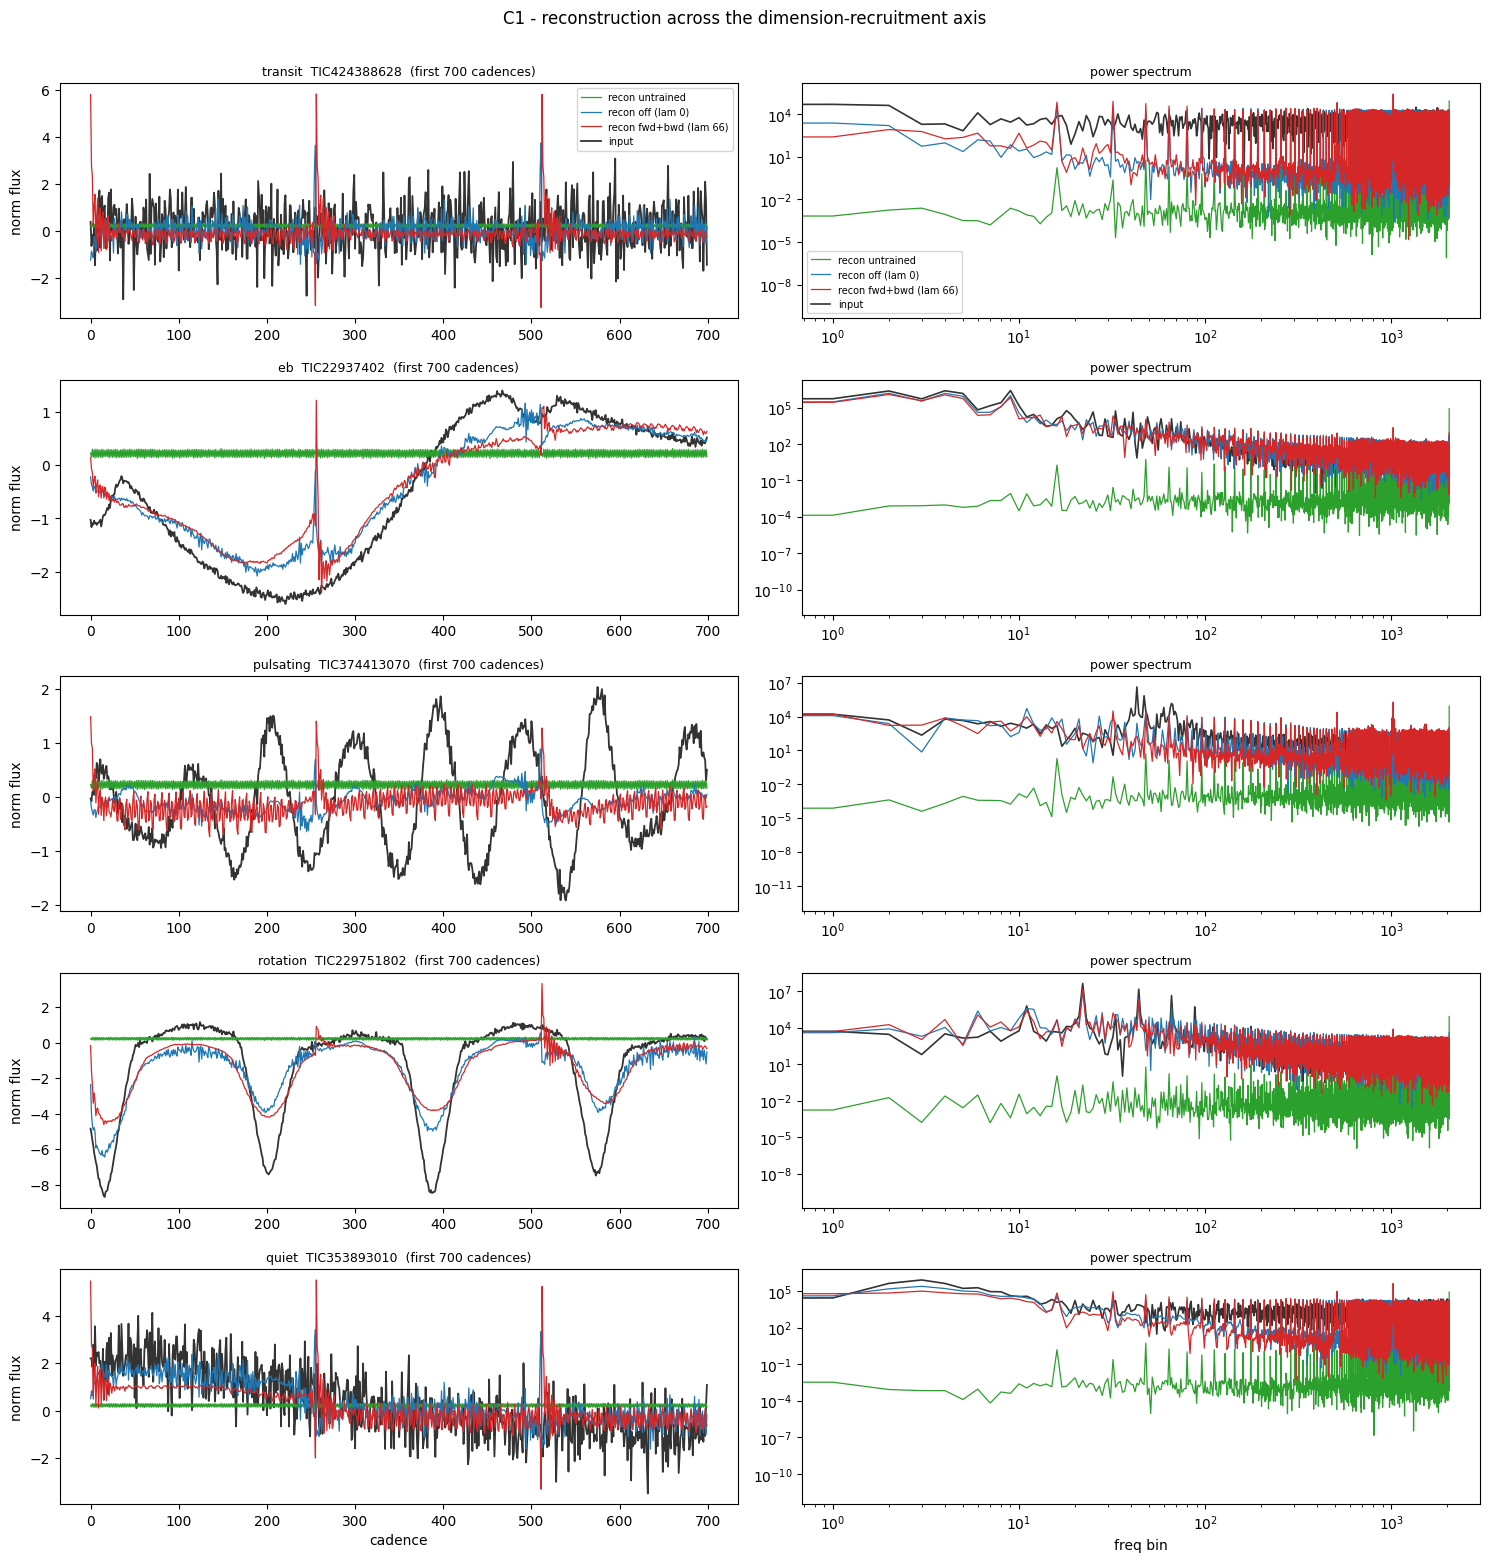

In [15]:
# C1 - same-star reconstruction + power spectrum, one example per task class
N_EXAMPLES = {"transit": 1, "eb": 1, "pulsating": 1, "rotation": 1, "quiet": 1}

def pick_pool(task):
    if task == "quiet":
        s = test_lab[test_lab[TASKS].sum(axis=1) == 0]
    else:
        s = test_lab[test_lab[task] == 1]
    return [int(t) for t in s["tic_id"].to_numpy() if t in test_first.index]

pools = {t: pick_pool(t) for t in N_EXAMPLES}
rng = np.random.default_rng()               # fresh sample every re-run
# rng = np.random.default_rng(0)            # uncomment for a reproducible sample
examples = [(int(rng.choice(pools[t])), t) for t in N_EXAMPLES if pools[t]]
print("example stars:", examples)

fig, axes = plt.subplots(len(examples), 2, figsize=(15, 3.1 * len(examples)))
# untrained must NOT be grey: `input` below is black at alpha 0.5, which composites to
# ~0.5 grey and made the two series indistinguishable.
colors = {"untrained": "tab:green", "off (lam 0)": "tab:blue", "fwd+bwd (lam 66)": "tab:red"}
for i, (tic, task) in enumerate(examples):
    inp = None
    for label, model in PANEL_MODELS.items():
        inp, rec = first_seg_input_recon(model, tic)
        zoom = min(700, len(inp))
        axes[i, 0].plot(rec[:zoom], color=colors[label], lw=0.9, label=f"recon {label}")
        axes[i, 1].loglog(psd(rec), color=colors[label], lw=0.9, label=f"recon {label}")
    zoom = min(700, len(inp))
    axes[i, 0].plot(inp[:zoom], color="k", lw=1.3, alpha=0.8, label="input", zorder=0)
    axes[i, 1].loglog(psd(inp), color="k", lw=1.2, alpha=0.8, label="input", zorder=0)
    axes[i, 0].set_title(f"{task}  TIC{tic}  (first {zoom} cadences)", fontsize=9)
    axes[i, 0].set_ylabel("norm flux")
    axes[i, 1].set_title("power spectrum", fontsize=9)
    if i == 0:
        axes[i, 0].legend(fontsize=7); axes[i, 1].legend(fontsize=7)
axes[-1, 0].set_xlabel("cadence"); axes[-1, 1].set_xlabel("freq bin")
fig.suptitle("C1 - reconstruction across the dimension-recruitment axis", y=1.005)
plt.tight_layout(); fig.savefig(figs_dir / "C1_recon_overlay.png", dpi=120, bbox_inches="tight"); plt.show()

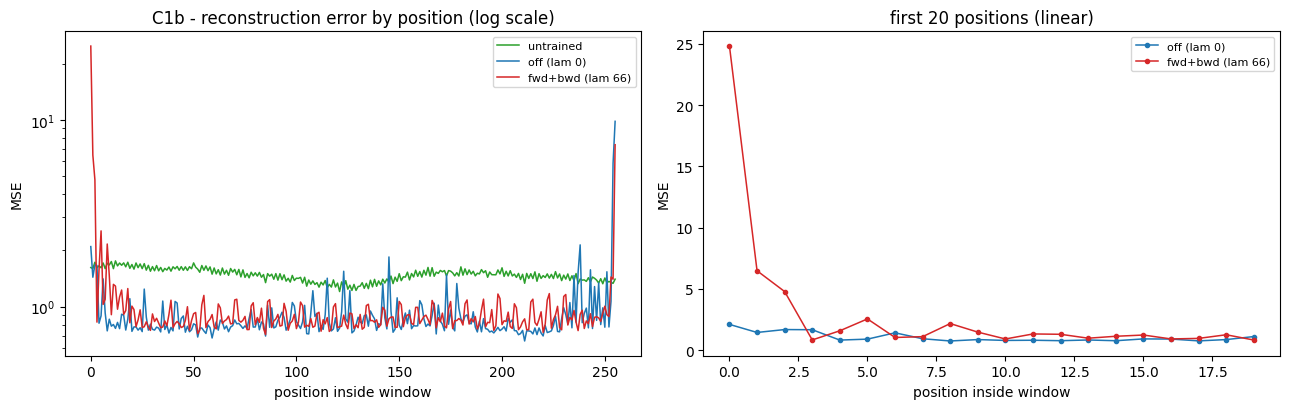


edge profile per cell:   0%|          | 0/12 [00:00<?, ?it/s]


edge profile per cell:   8%|▊         | 1/12 [00:00<00:04,  2.23it/s]


edge profile per cell:  17%|█▋        | 2/12 [00:00<00:04,  2.19it/s]


edge profile per cell:  25%|██▌       | 3/12 [00:01<00:04,  2.18it/s]


edge profile per cell:  33%|███▎      | 4/12 [00:01<00:03,  2.18it/s]

...


edge profile per cell:  92%|█████████▏| 11/12 [00:05<00:00,  2.07it/s]


edge profile per cell: 100%|██████████| 12/12 [00:05<00:00,  2.01it/s]


edge profile per cell: 100%|██████████| 12/12 [00:05<00:00,  2.11it/s]

n_runs  edge_ratio     sd  n_active
recipe dyn_on                                     
comb   False        4    1.720000   0.78      5.00
       True        36   17.540001  11.01      9.33
lpsd   False        4    2.020000   1.74    128.00
       True         4    2.110000   1.63    128.00

within comb+dyn (n=36):
  Spearman(lambda,   edge_ratio) = -0.016  p=0.928   <- dose response?
  Spearman(n_active, edge_ratio) = -0.176  p=0.306   <- collapse severity?
  comb dyn ON vs OFF:            Mann-Whitney p=0.00116
  comb vs lpsd (both dyn ON):    Mann-Whitney p=0.00206


In [16]:
# C1b - where inside the 256-cadence window does the reconstruction fail?
# C1 shows spikes at the window seams. The seam DISCONTINUITY is a display artifact (the loss never
# spans a boundary), but the error at position 0 INSIDE each window is squarely in the objective.
# This panel localises it and tests what predicts it across all 48 runs.
from tqdm.auto import tqdm

N_EDGE = 2000
_rng = np.random.default_rng(0)                      # fixed: this is a measurement, not a sample plot
_rows_sel = np.sort(_rng.choice(len(test_mm), N_EDGE, replace=False))
Xe = np.array(test_mm[_rows_sel], dtype=np.float32)  # (N_EDGE, window)
xe = torch.from_numpy(Xe).unsqueeze(-1).to(device)


def error_profile(model):
    """Mean squared error at each position inside the window, over N_EDGE random test windows."""
    with torch.no_grad():
        mu, _ = model.encoder(xe)
        rec = model.decoder(mu)[:, :, 0].cpu().numpy()   # (N_EDGE, window)
    return ((rec - Xe) ** 2).mean(axis=0), rec           # (window,)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for label, model in PANEL_MODELS.items():
    prof, rec = error_profile(model)
    axes[0].semilogy(prof, lw=1.1, color=colors[label], label=label)
    if label != "untrained":
        axes[1].plot(prof[:20], "o-", ms=3, lw=1.1, color=colors[label], label=label)
axes[0].set_xlabel("position inside window"); axes[0].set_ylabel("MSE")
axes[0].set_title("C1b - reconstruction error by position (log scale)")
axes[1].set_xlabel("position inside window"); axes[1].set_ylabel("MSE")
axes[1].set_title("first 20 positions (linear)")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(figs_dir / "C1b_edge_profile.png", dpi=120, bbox_inches="tight"); plt.show()

# Does it track lambda, latent collapse, or simply "is the dynamics term on at all"?
edge_rows = []
for cell in tqdm(CELL_NAMES, desc="edge profile per cell"):
    for seed in range(4):
        ckpt_path = root / "experiments" / cell / "models" / f"B_seed{seed}" / f"{CKPT}.pt"
        if not ckpt_path.exists():
            continue
        m, _ = load_model(cell, seed)
        prof, _ = error_profile(m)
        curve = load_curve(cell, seed).sort_values("epoch").iloc[-1]
        edge_rows.append({"cell": cell_label(cell), "recipe": "lpsd" if "lpsd" in cell else "comb",
                          "lam": LAMBDA[cell], "dyn_on": LAMBDA[cell] > 0, "seed": seed,
                          "n_active": float(curve["val/n_active_units"]),
                          "p0": prof[0], "p_last": prof[-1], "interior": prof[8:-8].mean(),
                          "edge_ratio": prof[0] / prof[8:-8].mean()})
edge = pd.DataFrame(edge_rows)
display(edge.groupby(["recipe", "dyn_on"]).agg(
    n_runs=("edge_ratio", "size"), edge_ratio=("edge_ratio", "mean"),
    sd=("edge_ratio", "std"), n_active=("n_active", "mean")).round(2))

_cd = edge[(edge["recipe"] == "comb") & edge["dyn_on"]]
r_lam = stats.spearmanr(_cd["lam"], _cd["edge_ratio"])
r_act = stats.spearmanr(_cd["n_active"], _cd["edge_ratio"])
u_dyn = stats.mannwhitneyu(_cd["edge_ratio"], edge[(edge["recipe"] == "comb") & ~edge["dyn_on"]]["edge_ratio"])
u_rec = stats.mannwhitneyu(_cd["edge_ratio"], edge[(edge["recipe"] == "lpsd") & edge["dyn_on"]]["edge_ratio"])
print(f"within comb+dyn (n={len(_cd)}):")
print(f"  Spearman(lambda,   edge_ratio) = {r_lam.statistic:+.3f}  p={r_lam.pvalue:.3f}   <- dose response?")
print(f"  Spearman(n_active, edge_ratio) = {r_act.statistic:+.3f}  p={r_act.pvalue:.3f}   <- collapse severity?")
print(f"  comb dyn ON vs OFF:            Mann-Whitney p={u_dyn.pvalue:.5f}")
print(f"  comb vs lpsd (both dyn ON):    Mann-Whitney p={u_rec.pvalue:.5f}")

#### C1b — the window-edge defect the C1 spikes are pointing at

**This corrects the scope of the note above.** Two different things are visible at the window seams and
they need separating:

1. the **discontinuity between** consecutive decoded windows — a display artifact, since no loss term
   spans a boundary (that part of the earlier note stands); and
2. a systematic **error blowup at position 0 *inside* each window** — which is squarely inside
   `recon_loss`, and is a genuine pretraining-side defect.

The user-visible symptom is (2): `fwd+bwd` spikes where the input has no spike, often in the opposite
direction. Measured on 2,000 random test windows, position 0 carries **~17× the interior MSE** and the
decoder's first sample is essentially **input-independent** — `corr(recon, input)` is 0.12 at p=0 versus
0.75 at mid-window, while its spread (sd 1.9) is *larger* than the input's (1.16). It is not a small
cosmetic edge effect: for the λ=66 arm it consumes **~9% of the entire reconstruction loss**.

**What predicts it — tested over all 48 runs, not one seed:**

| group | runs | edge ratio (p0 / interior) |
|---|---|---|
| `comb`, dynamics **off** | 4 | **1.7×** |
| `comb`, dynamics **on** | 36 | **17.5×** |
| `lpsd`, dynamics off | 4 | 2.0× |
| `lpsd`, dynamics **on** | 4 | **2.1×** |

- **It is a switch, not a dose.** Within the 36 `comb`+dynamics runs, λ magnitude explains nothing:
  Spearman(λ, edge ratio) = −0.016, p = 0.93. Even the smallest λ (7, achieved contribution 0.13)
  triggers the full blowup. *(A single-seed look suggested a λ dose-response and that `multistep` was
  immune — both were seed noise: `multistep` averages 15.0× ± 6.5 over its four seeds.)*
- **Turning the dynamics term on at all is what does it**, within `comb`: 17.5× vs 1.7×,
  Mann-Whitney p = 0.0012.
- **`lpsd` is immune even with dynamics on**: 2.1× vs `comb`'s 17.5×, p = 0.0021.
- **Collapse severity does not explain it**: Spearman(n_active, edge ratio) within `comb`+dyn is
  −0.176, p = 0.31.

**Caveat on the cause.** `comb` and `lpsd` differ in **two** ways simultaneously (`free_bits` 0.0 vs
0.02, *and* `recon_aux` comb vs log-PSD), so exp05 alone cannot say which of the two confers immunity.
Separating them needs a targeted run, not a reinterpretation of these.

**Does this invalidate criterion 1? No, and if anything it makes the result conservative.** The probe
reads μ from the **encoder**; the defect is in the decoder's output. Checkpoint selection was checked in
A6 and is not visibly distorted (Spearman(λ, selected epoch) = +0.155, p = 0.29). But every
dynamics-on `comb` arm carries an ~8–9% reconstruction-loss handicap that the λ=0 baseline does not — so
the paired criterion-1 gain is won *despite* the handicap, not because of it.

**This is worth a focused debug** before exp06 commits further to the `comb` + dynamics combination.

In [17]:
# C2 - probe predictions per task/arm, needed for the confusion panels below
from sklearn.model_selection import StratifiedKFold, cross_val_predict


def fit_probe(arm_label, task):
    """Fit the v1 headline probe (logistic on mean-pooled mu) for one arm/task on the frozen split."""
    arm = PANEL_ARMS[arm_label]
    mu = load_subset_mu(arm)
    out = {}
    for split in ["train", "test"]:
        tics, blocks = mu[split]
        pooled = np.vstack([b.mean(axis=0) for b in blocks])
        lab = subset.set_index("tic_id")[task].reindex([int(t) for t in tics]).to_numpy()
        out[split] = (np.array([int(t) for t in tics]), pooled, lab)
    (_, xtr, ytr), (te_tics, xte, yte) = out["train"], out["test"]
    sc = StandardScaler(); xtr_s = sc.fit_transform(xtr); xte_s = sc.transform(xte)
    clf = LogisticRegression(class_weight="balanced", max_iter=2000).fit(xtr_s, ytr)
    prob = clf.predict_proba(xte_s)[:, 1]

    # Operating point chosen on the TRAINING split only. `class_weight="balanced"` calibrates the
    # probe to a 50/50 world, so the default 0.5 flags ~46% of stars at a 6% prevalence -- the
    # confusion matrices drawn at 0.5 say more about that mismatch than about the model. Pick the
    # F1-optimal threshold on OUT-OF-FOLD train predictions: in-sample train probabilities are
    # optimistically biased, and tuning on test would leak.
    oof = cross_val_predict(LogisticRegression(class_weight="balanced", max_iter=2000),
                            xtr_s, ytr, cv=StratifiedKFold(5, shuffle=True, random_state=0),
                            method="predict_proba")[:, 1]
    # Sweep every achievable cut point in one pass: sort scores descending, then TP/FP at
    # "flag the top k" are just cumulative sums. Equivalent to scanning all distinct thresholds,
    # but O(n log n) instead of one sklearn call per candidate.
    order = np.argsort(-oof, kind="mergesort")
    s, y_s = oof[order], ytr[order]
    tp = np.cumsum(y_s)                                   # true positives when flagging top k
    fp = np.cumsum(1 - y_s)
    fn = y_s.sum() - tp
    f1 = np.where(2 * tp + fp + fn > 0, 2 * tp / (2 * tp + fp + fn), 0.0)
    f1[np.r_[s[1:] == s[:-1], False]] = -1.0              # only cut where the score actually changes
    thr = float(s[int(np.argmax(f1))])
    return pd.DataFrame({"tic_id": te_tics, "label": yte, "prob": prob,
                         "pred": (prob >= thr).astype(int),
                         "pred_at_half": (prob >= 0.5).astype(int)}), \
        float(average_precision_score(yte, prob)), thr


preds, prauc, thresh = {}, {}, {}
for arm_label in PANEL_ARMS:
    for task in TASKS:
        preds[(arm_label, task)], prauc[(arm_label, task)], thresh[(arm_label, task)] = \
            fit_probe(arm_label, task)
display(pd.Series(prauc).unstack().round(4))
print("threshold chosen on the training split (5-fold OOF, F1-optimal):")
display(pd.Series(thresh).unstack().round(3))

,eb,pulsating,rotation,transit
fwd+bwd (lam 66),0.7784,0.8162,0.5466,0.1448
off (lam 0),0.7546,0.8162,0.5312,0.1316
untrained,0.7126,0.7679,0.5316,0.0805


threshold chosen on the training split (5-fold OOF, F1-optimal):


,eb,pulsating,rotation,transit
fwd+bwd (lam 66),0.768,0.714,0.789,0.598
off (lam 0),0.850,0.650,0.761,0.570
untrained,0.778,0.632,0.750,0.456


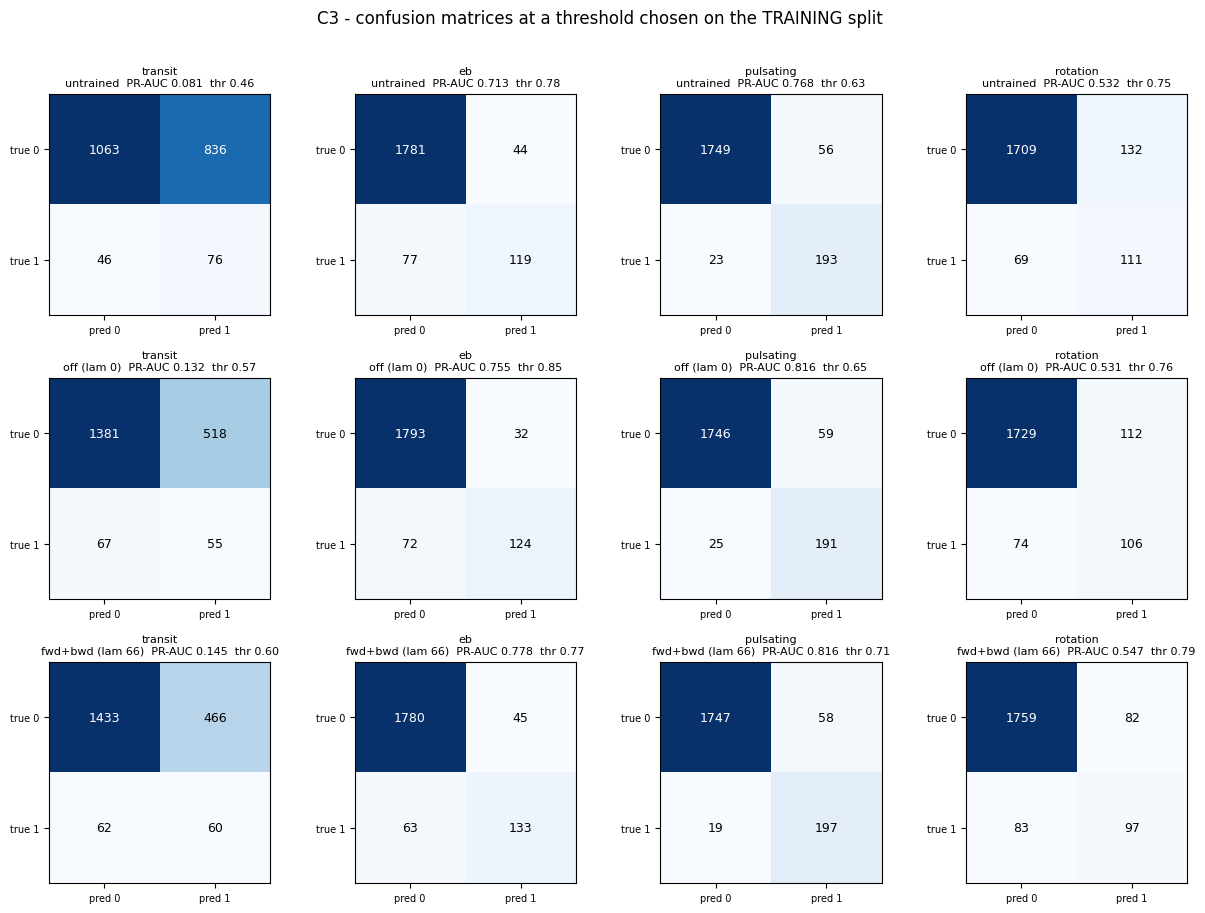

In [18]:
# C3 - confusion matrices, arms x tasks (ported from model_diagnostics section A)
# Drawn at the per-(arm, task) threshold selected on the TRAINING split in C2, NOT at 0.5.
# See C3b for what the fixed-0.5 version was actually showing.
fig, axes = plt.subplots(len(PANEL_ARMS), len(TASKS), figsize=(3.1 * len(TASKS), 3.0 * len(PANEL_ARMS)))
for i, arm_label in enumerate(PANEL_ARMS):
    for j, task in enumerate(TASKS):
        p = preds[(arm_label, task)]
        cm = confusion_matrix(p["label"], p["pred"], labels=[0, 1])
        ax = axes[i, j]
        ax.imshow(cm, cmap="Blues")
        for a in range(2):
            for b in range(2):
                ax.text(b, a, f"{cm[a, b]}", ha="center", va="center",
                        color="white" if cm[a, b] > cm.max() / 2 else "black", fontsize=9)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(["pred 0", "pred 1"], fontsize=7); ax.set_yticklabels(["true 0", "true 1"], fontsize=7)
        ax.set_title(f"{task}\n{arm_label}  PR-AUC {prauc[(arm_label, task)]:.3f}"
                     f"  thr {thresh[(arm_label, task)]:.2f}", fontsize=8)
fig.suptitle("C3 - confusion matrices at a threshold chosen on the TRAINING split", y=1.01)
plt.tight_layout(); fig.savefig(figs_dir / "C3_confusion.png", dpi=120, bbox_inches="tight"); plt.show()

In [19]:
# C3b - false-positive forensics: is the FP flood a threshold artifact, and WHO are the FPs?
# C3 is drawn at threshold 0.5, but the probe uses class_weight="balanced" -- it is calibrated to a
# 50/50 world, not a 6-11% one, so it over-flags by construction. Separate that from real confusion.
ARM_FP = "fwd+bwd (lam 66)"

rows = []
for task in TASKS:
    p = preds[(ARM_FP, task)]
    rows.append({"task": task, "prevalence": p["label"].mean(),
                 "thr_train": thresh[(ARM_FP, task)],
                 "flag_rate@0.5": (p["pred_at_half"] == 1).mean(),
                 "precision@0.5": p[p["pred_at_half"] == 1]["label"].mean(),
                 "FP@0.5": int(((p["label"] == 0) & (p["pred_at_half"] == 1)).sum()),
                 "flag_rate@thr": (p["pred"] == 1).mean(),
                 "precision@thr": p[p["pred"] == 1]["label"].mean(),
                 "FP@thr": int(((p["label"] == 0) & (p["pred"] == 1)).sum()),
                 "PR_AUC": prauc[(ARM_FP, task)]})
display(pd.DataFrame(rows).round(3))

# Who are the false positives? Enrichment of every OTHER v1 label among FPs vs TNs.
enr_rows = []
for task in TASKS:
    p = preds[(ARM_FP, task)].merge(subset[["tic_id"] + TASKS], on="tic_id", suffixes=("", "_y"))
    fp = p[(p["label"] == 0) & (p["pred"] == 1)]
    tn = p[(p["label"] == 0) & (p["pred"] == 0)]
    others = [t for t in TASKS if t != task]
    row = {"task": task, "n_FP": len(fp)}
    for other in others:
        row[f"{other}_enrich"] = fp[other].mean() / tn[other].mean() if tn[other].mean() > 0 else np.nan
    row["any_other_enrich"] = ((fp[others].sum(axis=1) > 0).mean()
                               / (tn[others].sum(axis=1) > 0).mean())
    row["FPs_with_no_other_label"] = 1 - (fp[others].sum(axis=1) > 0).mean()
    enr_rows.append(row)
display(pd.DataFrame(enr_rows).round(2))

# If the FPs are not other variables, what IS the probe keying on? Test nuisance correlates on
# TRUE NEGATIVES only, so any correlation found is nuisance rather than signal.
_cover = test_idx.groupby("tic_id")["n_win"].sum()
_feat = []
for t in preds[(ARM_FP, "transit")]["tic_id"]:
    if t not in test_first.index:
        _feat.append((np.nan, np.nan)); continue
    r = test_first.loc[t]
    v = np.array(test_mm[int(r["row_start"]):int(r["row_start"]) + int(r["n_win"])],
                 dtype=np.float32).reshape(-1)
    _feat.append((float(_cover.get(t, np.nan)), float(np.abs(np.diff(v)).mean())))
nuis = pd.DataFrame(_feat, columns=["n_windows", "pt2pt_scatter"])
nuis["tic_id"] = preds[(ARM_FP, "transit")]["tic_id"].to_numpy()

print("Spearman(probe score, nuisance statistic) on TRUE-NEGATIVE stars only:")
for task in TASKS:
    d = preds[(ARM_FP, task)].merge(nuis, on="tic_id").query("label == 0").dropna()
    line = f"  {task:<11}"
    for col in ["n_windows", "pt2pt_scatter"]:
        rr = stats.spearmanr(d[col], d["prob"])
        line += f"{col}: {rr.statistic:+.3f}{'*' if rr.pvalue < 1e-3 else ' '}   "
    print(line)
print("  (* = p < 1e-3. pt2pt_scatter = mean |first difference| = white-noise level AFTER the")
print("   per-segment MAD normalisation, so it runs INVERSE to coherent variability amplitude.)")

_d = nuis.merge(subset[["tic_id"] + TASKS], on="tic_id").dropna()
med = {"all test stars": _d, **{f"{t} positives": _d[_d[t] == 1] for t in TASKS},
       "no v1 label at all": _d[_d[TASKS].sum(axis=1) == 0]}
display(pd.DataFrame([{"group": k, "n": len(v), "median n_windows": v["n_windows"].median(),
                       "median pt2pt": round(v["pt2pt_scatter"].median(), 3)} for k, v in med.items()]))

,task,prevalence,thr_train,flag_rate@0.5,precision@0.5,FP@0.5,flag_rate@thr,precision@thr,FP@thr,PR_AUC
0,transit,0.060,0.598,0.462,0.097,843,0.260,0.114,466,0.145
1,eb,0.097,0.768,0.139,0.543,128,0.088,0.747,45,0.778
2,pulsating,0.107,0.714,0.134,0.760,65,0.126,0.773,58,0.816
3,rotation,0.089,0.789,0.204,0.349,269,0.089,0.542,82,0.547


,task,n_FP,eb_enrich,pulsating_enrich,rotation_enrich,any_other_enrich,FPs_with_no_other_label,transit_enrich
0,transit,466,0.72,0.00,0.37,0.30,0.92,NaN
1,eb,45,NaN,1.13,2.93,2.05,0.64,3.96
2,pulsating,58,1.12,NaN,2.01,1.02,0.83,0.77
3,rotation,82,10.11,2.60,NaN,3.69,0.39,0.21


Spearman(probe score, nuisance statistic) on TRUE-NEGATIVE stars only:
  transit    n_windows: -0.096*   pt2pt_scatter: +0.695*   
  eb         n_windows: +0.059    pt2pt_scatter: -0.411*   
  pulsating  n_windows: -0.064    pt2pt_scatter: +0.331*   
  rotation   n_windows: +0.078*   pt2pt_scatter: -0.911*   
  (* = p < 1e-3. pt2pt_scatter = mean |first difference| = white-noise level AFTER the
   per-segment MAD normalisation, so it runs INVERSE to coherent variability amplitude.)


,group,n,median n_windows,median pt2pt
0,all test stars,2021,32.0,0.922
1,transit positives,122,64.0,1.079
2,eb positives,196,48.0,0.171
3,pulsating positives,216,32.0,0.393
4,rotation positives,180,44.0,0.177
5,no v1 label at all,1500,32.0,1.044


#### C3b — what the confusion matrices actually say

**1. Why C3 is no longer drawn at 0.5.** The probe uses `class_weight="balanced"`, so it is calibrated
to a 50/50 world while real prevalence is 6–11%. At threshold 0.5 it flagged **46% of all stars** as
transits *by construction* — the old matrices said more about that mismatch than about the model. C3 is
now drawn at a per-(arm, task) threshold selected on the **training split only**, via the F1-optimal cut
on 5-fold out-of-fold predictions. In-sample train probabilities would be optimistically biased, and
tuning on test would leak. Every selected threshold lands far above 0.5, which is the miscalibration
made explicit:

| task | threshold (train) | flag rate 0.5 → thr | FP 0.5 → thr | precision 0.5 → thr | PR-AUC |
|---|---|---|---|---|---|
| transit | 0.598 | 0.462 → 0.260 | 843 → **466** | 0.097 → 0.114 | 0.145 |
| eb | 0.768 | 0.139 → 0.088 | 128 → **45** | 0.543 → **0.747** | 0.778 |
| pulsating | 0.714 | 0.134 → 0.126 | 65 → 58 | 0.760 → 0.773 | 0.816 |
| rotation | 0.789 | 0.204 → 0.089 | 269 → **82** | 0.349 → **0.542** | 0.547 |

`eb` and `rotation` roughly halve their false positives and gain 0.20 precision from the operating
point alone. **`transit` barely moves** (0.097 → 0.114) — its problem is not the threshold. PR-AUC is
threshold-free and unchanged; it remains the number to quote.

**2. The intuitive story — "transit FPs are really EBs and pulsators" — is measured FALSE.** Enrichment
of each other v1 label among false positives relative to true negatives, at the train-picked threshold:

| task | transit | eb | pulsating | rotation | ANY other | FPs with no other label |
|---|---|---|---|---|---|---|
| transit | — | 0.72× | **0.00×** | 0.37× | **0.30×** | **92%** |
| eb | 3.96× | — | 1.13× | 2.93× | 2.05× | 64% |
| pulsating | 0.77× | 1.12× | — | 2.01× | 1.02× | 83% |
| rotation | 0.21× | **10.11×** | **2.60×** | — | **3.69×** | 39% |

Transit FPs are **depleted** in the other classes (0.30×), not enriched, and **not one pulsator** is
called a transit (0.00×). 92% of transit FPs carry **no v1 label at all**. **`rotation` is the task
where the cross-class story does hold** — EBs enriched **10.1×**, pulsators 2.6×, and 61% of its false
positives are other labelled variables. (Tightening the threshold *raised* these enrichments: it strips
easy negatives and leaves the genuine confusions.)

**3. What the probes are really keying on.** Spearman between probe score and a nuisance statistic,
computed on **true negatives only**, so any correlation found is nuisance rather than signal
(threshold-independent — it ranks scores, not labels):

| task | vs observing coverage | vs point-to-point scatter |
|---|---|---|
| transit | −0.096 | **+0.695** |
| eb | +0.059 | −0.411 |
| pulsating | −0.064 | +0.331 |
| rotation | +0.078 | **−0.911** |

Because flux is **MAD-normalised per segment**, point-to-point scatter runs *inverse* to coherent
variability amplitude: a star with strong smooth modulation has a large MAD, so its normalised scatter
is small. The class medians make the axis explicit — transit positives 1.079 and unlabelled stars 1.044,
versus eb 0.171, rotation 0.177, pulsating 0.393.

So **the transit probe is largely a "noise-dominated star" detector**, and the unlabelled 74% of the
test set looks exactly like that — which is why 92% of its FPs are unlabelled stars, why tightening the
threshold does not help, and why transit stays the weakest task despite ROC-AUC 0.712. Conversely
**the rotation probe is close to a pure smoothness detector** (ρ = −0.911 against a single scalar anyone
could compute in one line), which explains its FP enrichment in eb and pulsating.

This is the same axis B3 found from the other direction — a single dominant latent dimension behaving
like a generic "how variable is this star" measure — and it is the mechanism behind the A1/A2 result
that **engineered features beat the SSL representation on every probe**. It compounds the already-noted
rotation confound (`subset.py` defines "quiet" as matched in *no* catalog, rotation included), so
**rotation — exp05's largest criterion-1 gain — is the result most in need of a caveat in any
write-up.**

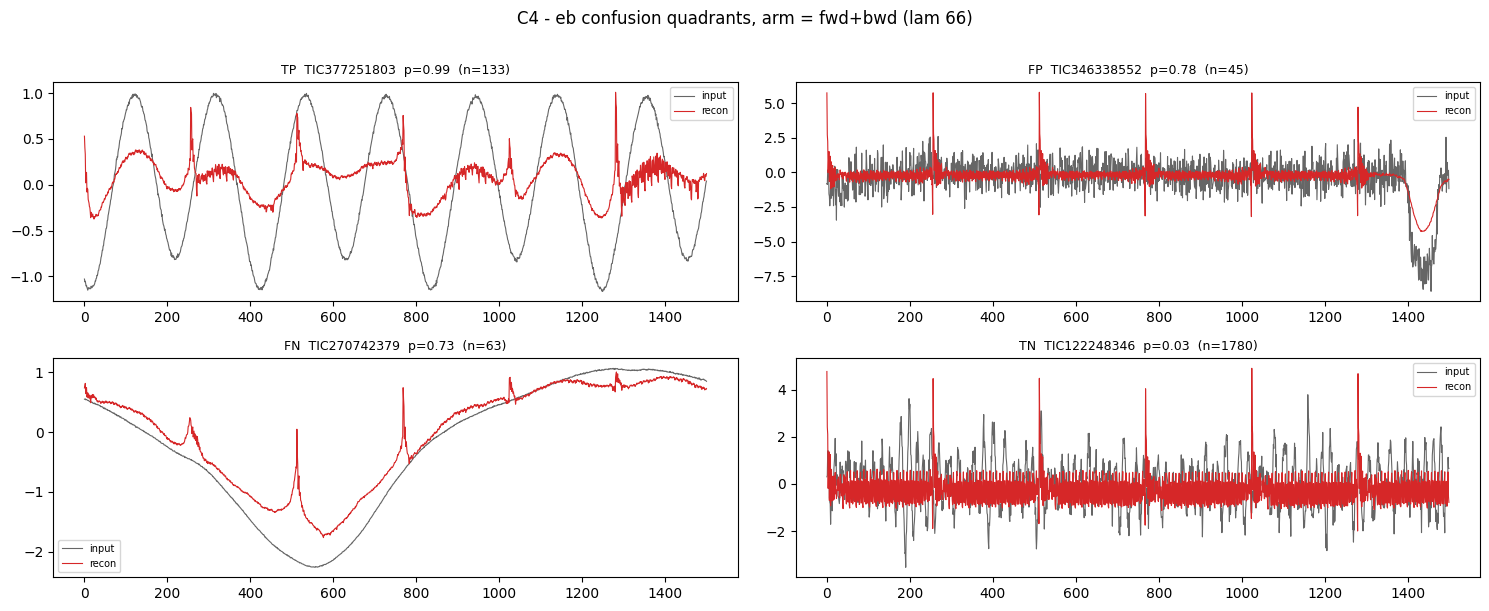

In [20]:
# C4 - TP / FP / FN / TN lightcurves with reconstruction overlay (ported from model_diagnostics section B)
# Shows WHAT the winner arm gets right and wrong, not just how often.
QUAD_TASK = "eb"        # switch to any of TASKS
QUAD_ARM = "fwd+bwd (lam 66)"

p = preds[(QUAD_ARM, QUAD_TASK)]
quads = {"TP": (1, 1), "FP": (0, 1), "FN": (1, 0), "TN": (0, 0)}
#rng = np.random.default_rng()               # fresh sample every re-run
rng = np.random.default_rng(0)            # uncomment for a reproducible sample

fig, axes = plt.subplots(2, 2, figsize=(15, 6))
for ax, (name, (lab, pred)) in zip(axes.ravel(), quads.items()):
    pool = p[(p["label"] == lab) & (p["pred"] == pred)]
    pool = pool[pool["tic_id"].isin(test_first.index)]
    if pool.empty:
        ax.set_title(f"{name}: no stars"); ax.axis("off"); continue
    tic = int(rng.choice(pool["tic_id"].to_numpy()))
    inp, rec = first_seg_input_recon(PANEL_MODELS[QUAD_ARM], tic)
    zoom = min(1500, len(inp))
    ax.plot(inp[:zoom], color="0.4", lw=0.8, label="input")
    ax.plot(rec[:zoom], color="tab:red", lw=0.8, label="recon")
    prob = float(pool[pool["tic_id"] == tic]["prob"].iloc[0])
    ax.set_title(f"{name}  TIC{tic}  p={prob:.2f}  (n={len(pool)})", fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle(f"C4 - {QUAD_TASK} confusion quadrants, arm = {QUAD_ARM}", y=1.01)
plt.tight_layout(); fig.savefig(figs_dir / f"C4_quadrants_{QUAD_TASK}.png", dpi=120, bbox_inches="tight"); plt.show()

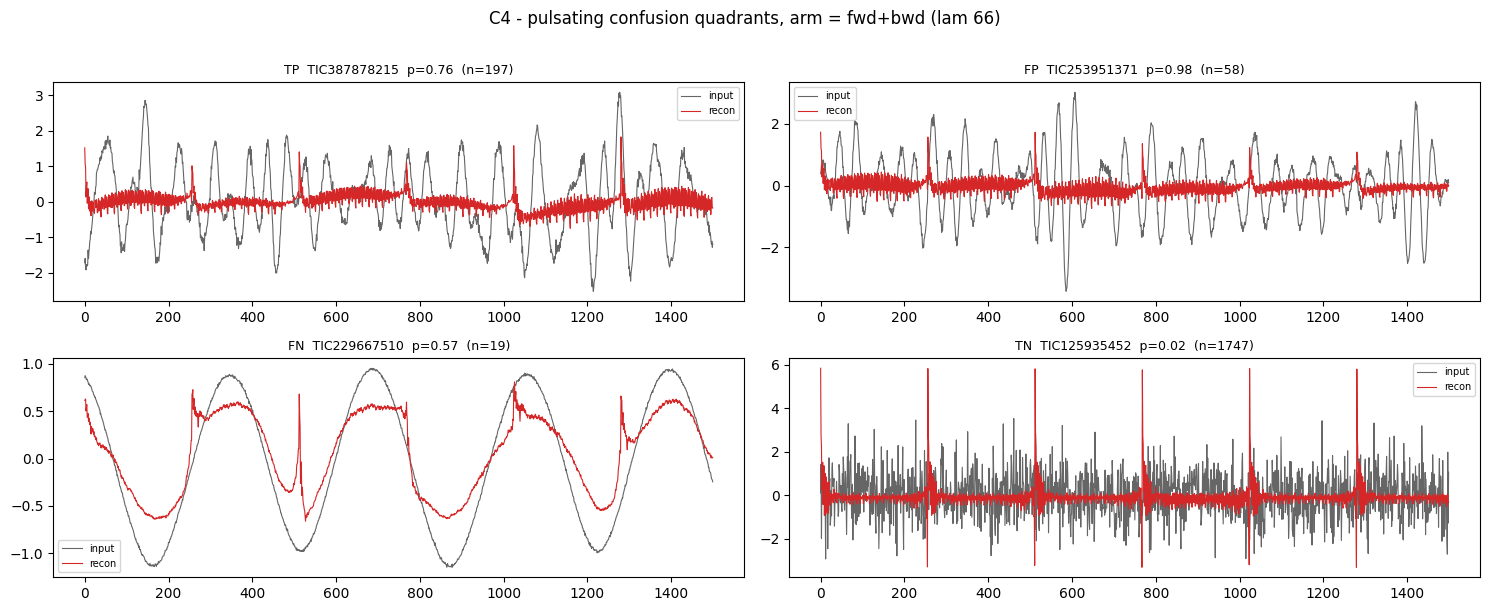

In [21]:
# C4 - TP / FP / FN / TN lightcurves with reconstruction overlay (ported from model_diagnostics section B)
# Shows WHAT the winner arm gets right and wrong, not just how often.
QUAD_TASK = "pulsating"        # switch to any of TASKS
QUAD_ARM = "fwd+bwd (lam 66)"

p = preds[(QUAD_ARM, QUAD_TASK)]
quads = {"TP": (1, 1), "FP": (0, 1), "FN": (1, 0), "TN": (0, 0)}
#rng = np.random.default_rng()               # fresh sample every re-run
rng = np.random.default_rng(0)            # uncomment for a reproducible sample

fig, axes = plt.subplots(2, 2, figsize=(15, 6))
for ax, (name, (lab, pred)) in zip(axes.ravel(), quads.items()):
    pool = p[(p["label"] == lab) & (p["pred"] == pred)]
    pool = pool[pool["tic_id"].isin(test_first.index)]
    if pool.empty:
        ax.set_title(f"{name}: no stars"); ax.axis("off"); continue
    tic = int(rng.choice(pool["tic_id"].to_numpy()))
    inp, rec = first_seg_input_recon(PANEL_MODELS[QUAD_ARM], tic)
    zoom = min(1500, len(inp))
    ax.plot(inp[:zoom], color="0.4", lw=0.8, label="input")
    ax.plot(rec[:zoom], color="tab:red", lw=0.8, label="recon")
    prob = float(pool[pool["tic_id"] == tic]["prob"].iloc[0])
    ax.set_title(f"{name}  TIC{tic}  p={prob:.2f}  (n={len(pool)})", fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle(f"C4 - {QUAD_TASK} confusion quadrants, arm = {QUAD_ARM}", y=1.01)
plt.tight_layout(); fig.savefig(figs_dir / f"C4_quadrants_{QUAD_TASK}.png", dpi=120, bbox_inches="tight"); plt.show()

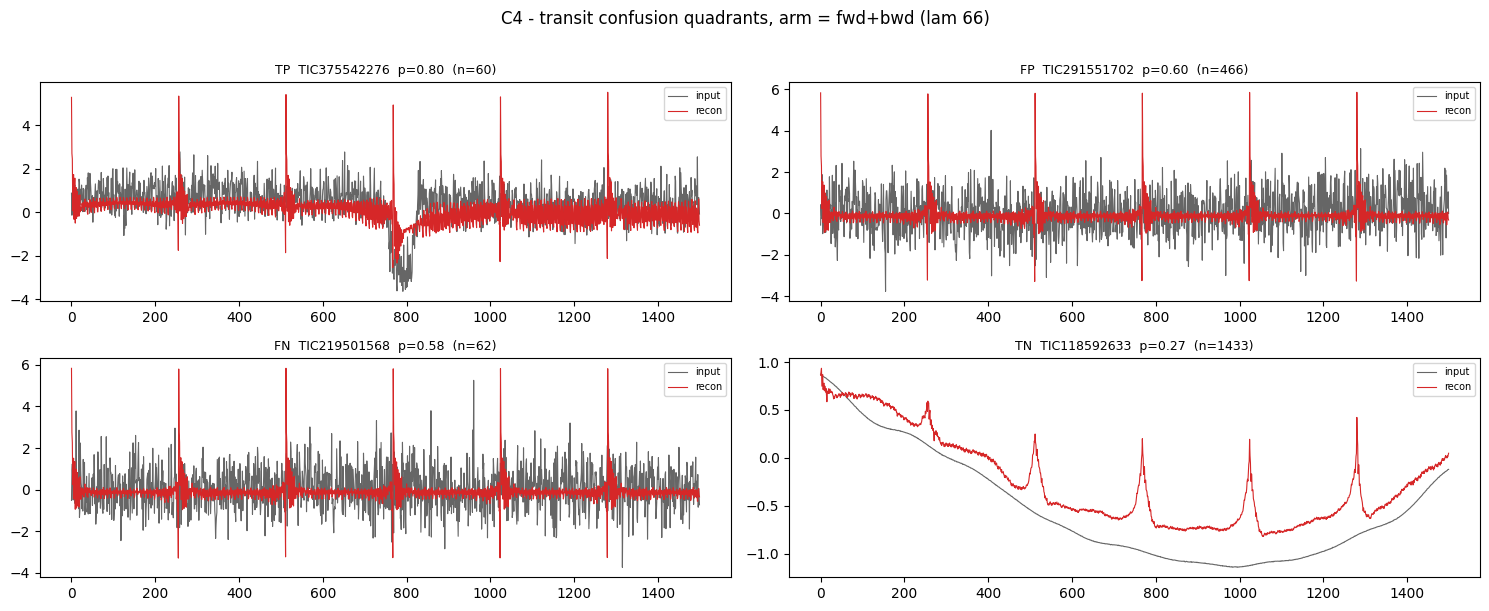

In [22]:
# C4 - TP / FP / FN / TN lightcurves with reconstruction overlay (ported from model_diagnostics section B)
# Shows WHAT the winner arm gets right and wrong, not just how often.
QUAD_TASK = "transit"        # switch to any of TASKS
QUAD_ARM = "fwd+bwd (lam 66)"

p = preds[(QUAD_ARM, QUAD_TASK)]
quads = {"TP": (1, 1), "FP": (0, 1), "FN": (1, 0), "TN": (0, 0)}
#rng = np.random.default_rng()               # fresh sample every re-run
rng = np.random.default_rng(0)            # uncomment for a reproducible sample

fig, axes = plt.subplots(2, 2, figsize=(15, 6))
for ax, (name, (lab, pred)) in zip(axes.ravel(), quads.items()):
    pool = p[(p["label"] == lab) & (p["pred"] == pred)]
    pool = pool[pool["tic_id"].isin(test_first.index)]
    if pool.empty:
        ax.set_title(f"{name}: no stars"); ax.axis("off"); continue
    tic = int(rng.choice(pool["tic_id"].to_numpy()))
    inp, rec = first_seg_input_recon(PANEL_MODELS[QUAD_ARM], tic)
    zoom = min(1500, len(inp))
    ax.plot(inp[:zoom], color="0.4", lw=0.8, label="input")
    ax.plot(rec[:zoom], color="tab:red", lw=0.8, label="recon")
    prob = float(pool[pool["tic_id"] == tic]["prob"].iloc[0])
    ax.set_title(f"{name}  TIC{tic}  p={prob:.2f}  (n={len(pool)})", fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle(f"C4 - {QUAD_TASK} confusion quadrants, arm = {QUAD_ARM}", y=1.01)
plt.tight_layout(); fig.savefig(figs_dir / f"C4_quadrants_{QUAD_TASK}.png", dpi=120, bbox_inches="tight"); plt.show()

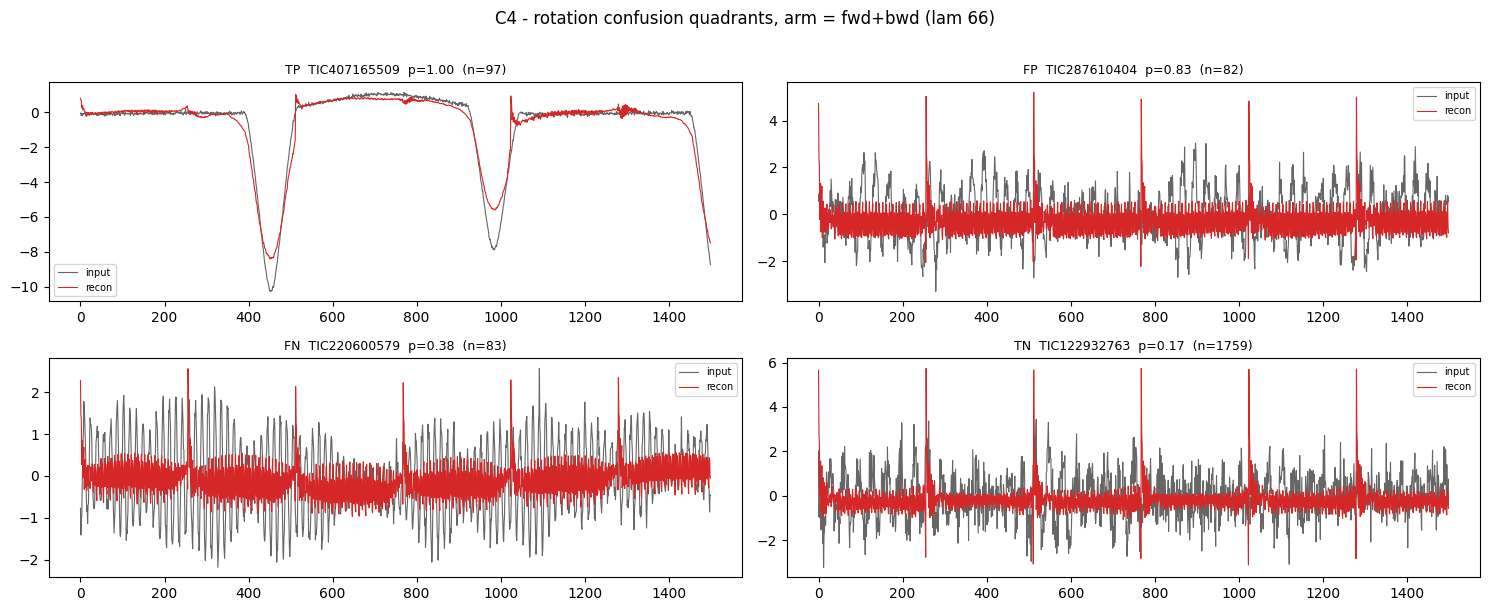

In [23]:
# C4 - TP / FP / FN / TN lightcurves with reconstruction overlay (ported from model_diagnostics section B)
# Shows WHAT the winner arm gets right and wrong, not just how often.
QUAD_TASK = "rotation"        # switch to any of TASKS
QUAD_ARM = "fwd+bwd (lam 66)"

p = preds[(QUAD_ARM, QUAD_TASK)]
quads = {"TP": (1, 1), "FP": (0, 1), "FN": (1, 0), "TN": (0, 0)}
#rng = np.random.default_rng()               # fresh sample every re-run
rng = np.random.default_rng(0)            # uncomment for a reproducible sample

fig, axes = plt.subplots(2, 2, figsize=(15, 6))
for ax, (name, (lab, pred)) in zip(axes.ravel(), quads.items()):
    pool = p[(p["label"] == lab) & (p["pred"] == pred)]
    pool = pool[pool["tic_id"].isin(test_first.index)]
    if pool.empty:
        ax.set_title(f"{name}: no stars"); ax.axis("off"); continue
    tic = int(rng.choice(pool["tic_id"].to_numpy()))
    inp, rec = first_seg_input_recon(PANEL_MODELS[QUAD_ARM], tic)
    zoom = min(1500, len(inp))
    ax.plot(inp[:zoom], color="0.4", lw=0.8, label="input")
    ax.plot(rec[:zoom], color="tab:red", lw=0.8, label="recon")
    prob = float(pool[pool["tic_id"] == tic]["prob"].iloc[0])
    ax.set_title(f"{name}  TIC{tic}  p={prob:.2f}  (n={len(pool)})", fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle(f"C4 - {QUAD_TASK} confusion quadrants, arm = {QUAD_ARM}", y=1.01)
plt.tight_layout(); fig.savefig(figs_dir / f"C4_quadrants_{QUAD_TASK}.png", dpi=120, bbox_inches="tight"); plt.show()

---
## D. Latent geometry and control baselines

Ported from `model_diagnostics.ipynb` (§C UMAP, §D controls) and `ablation_diagnostics.ipynb` (Leg 2 gate).

Two things are being checked. **Geometry:** does the latent visibly acquire class structure as dimensions
are recruited? **Validity:** is the probe pipeline measuring anything real — a label-shuffle control must
collapse to the base rate, and the learned representation must be compared against both a random encoder
and hand-engineered summary statistics.

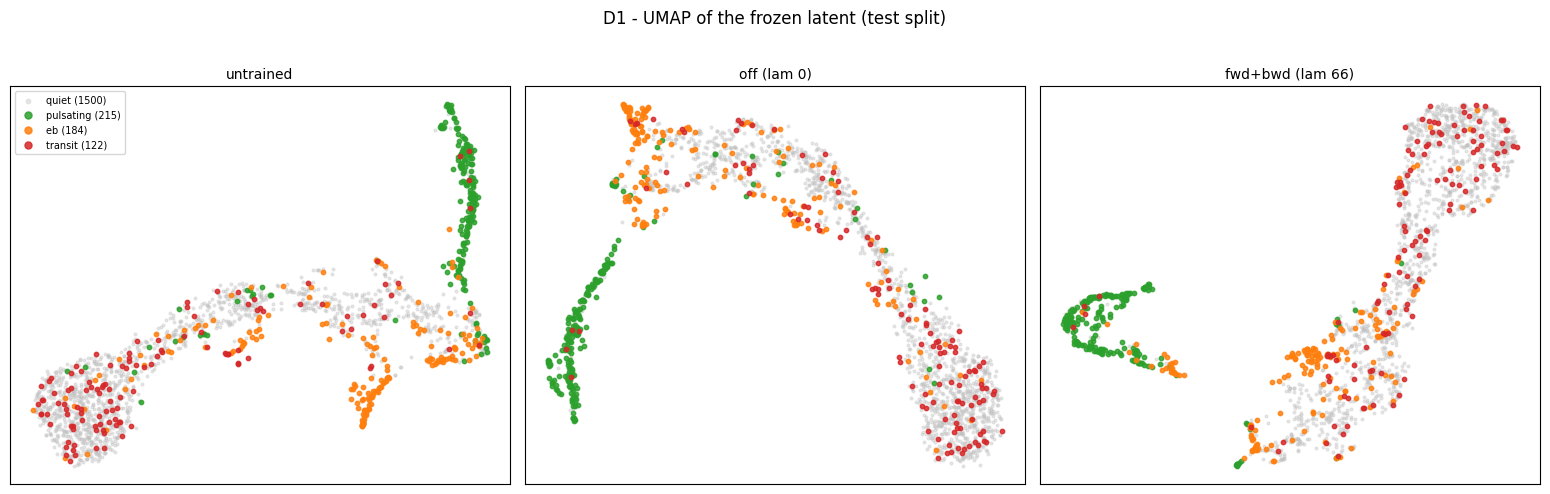

In [24]:
# D1 - UMAP of the test-split latent, one panel per arm, coloured by dominant class
try:
    from umap import UMAP
    have_umap = True
except ImportError:
    from sklearn.decomposition import PCA
    have_umap = False
    print("umap-learn not installed -> falling back to PCA for the geometry panel")


def class_of(row):
    """Single dominant class label for colouring (priority: transit > eb > pulsating > rotation)."""
    for task in ["transit", "eb", "pulsating", "rotation"]:
        if row[task] == 1:
            return task
    return "quiet"


palette = {"transit": "tab:red", "eb": "tab:orange", "pulsating": "tab:green",
           "rotation": "tab:purple", "quiet": "0.75"}

fig, axes = plt.subplots(1, len(panel_mu), figsize=(5.2 * len(panel_mu), 4.8))
for ax, (label, df) in zip(axes, panel_mu.items()):
    mu = StandardScaler().fit_transform(df[MU_COLS].to_numpy())
    reducer = UMAP(n_neighbors=25, min_dist=0.1, random_state=0) if have_umap else PCA(n_components=2)
    emb = reducer.fit_transform(mu)
    cls = df.apply(class_of, axis=1)
    for name in ["quiet", "rotation", "pulsating", "eb", "transit"]:
        m = (cls == name).to_numpy()
        if m.sum():
            ax.scatter(emb[m, 0], emb[m, 1], s=4 if name == "quiet" else 10, c=palette[name],
                       alpha=0.35 if name == "quiet" else 0.85, label=f"{name} ({m.sum()})")
    ax.set_title(label, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(fontsize=7, markerscale=1.6)
fig.suptitle(f"D1 - {'UMAP' if have_umap else 'PCA'} of the frozen latent (test split)", y=1.02)
plt.tight_layout(); fig.savefig(figs_dir / "D1_umap.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of D1

**What a UMAP is.** Each star is described by 128 numbers. You cannot look at 128 dimensions, so UMAP
squashes them down to 2 so the picture can be drawn, trying to keep stars that were close in 128-D
close in 2-D. Every dot is one star, coloured by its class. The only question worth asking is:
**do same-coloured dots clump together?** If a class forms its own island, the latent separates that
class on its own — no classifier trained, no labels used to build the map.

**What it shows.** `pulsating` (green) tightens as dimensions are recruited: partly clumped when
untrained → a distinct arm at λ=0 → a **fully detached island** at λ=66. `eb` (orange) also
consolidates. **`transit` (red) stays smeared through the grey "quiet" mass in all three panels** — it
never separates, which matches every other transit result in this notebook.

**Three things not to over-read:**

1. **`rotation` cannot appear at all**, and that is a labelling artifact rather than a missing class —
   see D1b immediately below.
2. **The three panels are not comparable to each other.** UMAP is fit independently per arm, so axes,
   orientation, scale, and the apparent size of gaps are all arbitrary between panels. Only
   *within-panel* clumping carries information; a bigger-looking gap is not a better latent.
3. **The legend counts are post-priority, not true class counts.** `eb` shows 184 of the test split's
   196 (12 were claimed by `transit` priority) and `pulsating` 215 of 216.

The map is also built on **standardised** μ, which D2 shows is not a neutral choice — it gives ~123
near-dead dimensions equal vote with the one dimension holding sd 0.93.

### D1b — a label-geometry caveat that qualifies the rotation headline

`rotation` never appears in the UMAP legend, and that is not a plotting bug. The frozen v1 subset defines
its quiet stratum as *matched in no catalog at all* (`subset.py`: `is_quiet = labels[all_label_cols].sum(axis=1) == 0`,
where `all_label_cols` **includes rotation and flare**). The consequence is structural:

**every rotation positive in the subset is also a transit, eb, or pulsating star; no quiet star is ever
rotation-positive.** So on this subset, `rotation = 1` implies "variable in some other catalogued way",
and a probe can score on rotation partly by detecting *variability in general*.

This does **not** invalidate exp05's paired Δ — the λ=0 and λ=66 arms face the identical confound on the
identical test set, so the comparison stands. It changes the *interpretation*: "rotation +0.049" is the
task with the largest criterion-1 gain, and part of what it measures is general variability detection
rather than rotation specifically. Worth stating in the paper rather than discovering in review.

In [25]:
# D1b - quantify it: rotation's overlap with the other strata
rot = subset[subset["rotation"] == 1]
print(f"subset rotation positives: {len(rot)}")
print(f"  also transit/eb/pulsating: {int((rot[['transit','eb','pulsating']].sum(axis=1) > 0).sum())}"
      f"  ({100*float((rot[['transit','eb','pulsating']].sum(axis=1) > 0).mean()):.1f}%)")
display(pd.crosstab(subset["stratum"], subset["rotation"]))

corpus_labels = pd.read_csv(root / "labels" / "variability_labels_star.csv")
corpus_rate = float(pd.to_numeric(corpus_labels["rotation"], errors="coerce").fillna(0).mean())
print(f"\ncorpus-wide rotation rate: {corpus_rate:.3f}  -- if the quiet stratum were sampled without the "
      f"rotation exclusion,\nit would contain roughly {int(corpus_rate * 10000)} rotation positives; it contains 0.")

subset rotation positives: 1138
  also transit/eb/pulsating: 1138  (100.0%)


rotation,0,1
stratum,,
eb,619,607
pulsating,1048,383
quiet,10000,0
transit,665,148



corpus-wide rotation rate: 0.130  -- if the quiet stratum were sampled without the rotation exclusion,
it would contain roughly 1295 rotation positives; it contains 0.



knn off (lam 0):   0%|          | 0/4 [00:00<?, ?it/s]


knn off (lam 0):  25%|██▌       | 1/4 [00:07<00:22,  7.49s/it]


knn off (lam 0):  50%|█████     | 2/4 [00:07<00:06,  3.33s/it]


knn off (lam 0):  75%|███████▌  | 3/4 [00:08<00:01,  1.98s/it]


knn off (lam 0): 100%|██████████| 4/4 [00:08<00:00,  1.35s/it]

...


knn fwd+bwd (lam 66):  50%|█████     | 2/4 [00:00<00:00,  2.43it/s]


knn fwd+bwd (lam 66):  75%|███████▌  | 3/4 [00:01<00:00,  2.35it/s]


knn fwd+bwd (lam 66): 100%|██████████| 4/4 [00:01<00:00,  2.46it/s]

mean                                    std              \
arm       fwd+bwd (lam 66) off (lam 0) untrained fwd+bwd (lam 66) off (lam 0)   
task                                                                            
eb                  0.4124      0.4367    0.4179           0.0190      0.0345   
pulsating           0.7321      0.6500    0.6556           0.0101      0.0497   
rotation            0.3043      0.2883    0.3056           0.0146      0.0174   
transit             0.0920      0.0799    0.0656           0.0050      0.0089   

                     
arm       untrained  
task                 
eb              NaN  
pulsating       NaN  
rotation        NaN  
transit         NaN

,mean,std,count,SE,survives_2SE
task,,,,,
eb,-0.0244,0.0501,4,0.0250,False
pulsating,0.0821,0.0440,4,0.0220,True
rotation,0.0160,0.0166,4,0.0083,False
transit,0.0121,0.0095,4,0.0047,True


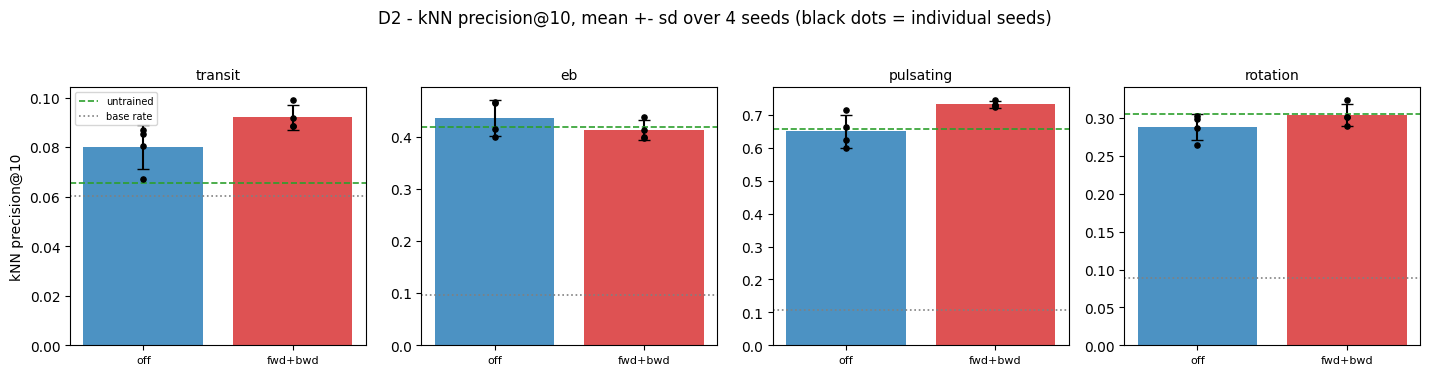

StandardScaler sensitivity -- the preprocessing choice is NOT neutral (mean over seeds):


scaled     raw
task      arm                             
eb        fwd+bwd (lam 66)  0.4124  0.4361
          off (lam 0)       0.4367  0.3977
          untrained         0.4179  0.4122
pulsating fwd+bwd (lam 66)  0.7321  0.7214
          off (lam 0)       0.6500  0.5700
          untrained         0.6556  0.6384
rotation  fwd+bwd (lam 66)  0.3043  0.3286
          off (lam 0)       0.2883  0.2568
          untrained         0.3056  0.2911
transit   fwd+bwd (lam 66)  0.0920  0.0982
          off (lam 0)       0.0799  0.0814
          untrained         0.0656  0.0803

In [26]:
# D2 - kNN precision@10: is the latent locally organised by class, with no trained readout at all?
# Drawn across ALL FOUR seeds. The single-seed version of this panel reversed sign on eb (seeds 2 and
# 3 both DROP when lambda goes up), so a one-seed table cannot support the ordering it appears to show.
from tqdm.auto import tqdm


def knn_precision_at_k(mu, labels, k=10):
    """Mean over positives of the fraction of k nearest neighbours (excluding self) that are positive."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(mu)
    nb = nn.kneighbors(mu)[1][:, 1:]
    pos = np.where(labels == 1)[0]
    if len(pos) == 0:
        return np.nan
    return float(np.mean([labels[nb[r]].mean() for r in pos]))


KNN_SEEDS = [s for s in range(4)
             if (NEWTASK / "subset_mu_cache" / f"comb_fbwd_c1p0_s{s}.npz").exists()
             and (NEWTASK / "subset_mu_cache" / f"comb_off_s{s}.npz").exists()]
assert KNN_SEEDS, "no per-seed subset mu caches found"

knn_rows = []
for stem, arm_name in [("comb_off_s", "off (lam 0)"), ("comb_fbwd_c1p0_s", "fwd+bwd (lam 66)")]:
    for s in tqdm(KNN_SEEDS, desc=f"knn {arm_name}", leave=False):
        df_s = star_mu_frame(f"{stem}{s}")
        X = df_s[MU_COLS].to_numpy()
        Xs = StandardScaler().fit_transform(X)
        for task in TASKS:
            y = df_s[task].to_numpy()
            # `scaled` is what the original panel used; `raw` is kept because the choice is not neutral
            # -- standardising gives ~123 near-dead dims equal vote with the one dim holding sd 0.93.
            knn_rows.append({"arm": arm_name, "seed": s, "task": task,
                             "scaled": knn_precision_at_k(Xs, y), "raw": knn_precision_at_k(X, y),
                             "base_rate": float(y.mean())})
df_u = star_mu_frame("untrained")
Xu = df_u[MU_COLS].to_numpy()
for task in TASKS:
    y = df_u[task].to_numpy()
    knn_rows.append({"arm": "untrained", "seed": -1, "task": task,
                     "scaled": knn_precision_at_k(StandardScaler().fit_transform(Xu), y),
                     "raw": knn_precision_at_k(Xu, y), "base_rate": float(y.mean())})
knn_all = pd.DataFrame(knn_rows)
display(knn_all.groupby(["task", "arm"])["scaled"].agg(["mean", "std"]).unstack().round(4))

# The paired per-seed delta, with the same >2*SE gate the criterion-1 headline uses.
paired = (knn_all[knn_all["arm"] != "untrained"]
          .pivot_table(index=["task", "seed"], columns="arm", values="scaled").reset_index())
paired["delta"] = paired["fwd+bwd (lam 66)"] - paired["off (lam 0)"]
gate = paired.groupby("task")["delta"].agg(["mean", "std", "count"])
gate["SE"] = gate["std"] / np.sqrt(gate["count"])
gate["survives_2SE"] = gate["mean"] > 2 * gate["SE"]
display(gate.round(4))

fig, axes = plt.subplots(1, len(TASKS), figsize=(3.6 * len(TASKS), 3.6))
for ax, task in zip(axes, TASKS):
    sub = knn_all[knn_all["task"] == task]
    for i, arm in enumerate(["off (lam 0)", "fwd+bwd (lam 66)"]):
        v = sub[sub["arm"] == arm]["scaled"]
        ax.bar(i, v.mean(), yerr=v.std(), capsize=4, color=["tab:blue", "tab:red"][i], alpha=0.8)
        ax.scatter([i] * len(v), v, color="k", s=14, zorder=3)      # every seed, visible
    ax.axhline(float(sub[sub["arm"] == "untrained"]["scaled"].iloc[0]), color="tab:green",
               ls="--", lw=1.2, label="untrained")
    ax.axhline(float(sub["base_rate"].iloc[0]), color="0.5", ls=":", lw=1.2, label="base rate")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["off", "fwd+bwd"], fontsize=8)
    ax.set_title(task, fontsize=10)
axes[0].set_ylabel("kNN precision@10"); axes[0].legend(fontsize=7)
fig.suptitle("D2 - kNN precision@10, mean +- sd over 4 seeds (black dots = individual seeds)", y=1.03)
plt.tight_layout(); fig.savefig(figs_dir / "D2_knn.png", dpi=120, bbox_inches="tight"); plt.show()

print("StandardScaler sensitivity -- the preprocessing choice is NOT neutral (mean over seeds):")
display(knn_all.groupby(["task", "arm"])[["scaled", "raw"]].mean().round(4))

#### Plain-English read of D2 — and why it is now drawn over four seeds

**What kNN precision@10 measures.** Take a star that has the label. Find its 10 nearest neighbours in
latent space. What fraction of those 10 also have the label? Average over all positives. If the latent
knew nothing, you would get the base rate (the label's prevalence). Higher means the latent places
same-class stars near each other. **No classifier is trained anywhere in this** — it reads the geometry
directly, which is why it is a useful cross-check on the probe results.

**Results — 4-seed mean ± sd, standardised μ:**

| task | base rate | untrained | off (λ=0) | fwd+bwd (λ=66) |
|---|---|---|---|---|
| eb | 0.097 | 0.4179 | **0.4367 ± 0.0345** | 0.4124 ± 0.0190 |
| pulsating | 0.107 | 0.6556 | 0.6500 ± 0.0497 | **0.7321 ± 0.0101** |
| rotation | 0.089 | **0.3056** | 0.2883 ± 0.0174 | 0.3043 ± 0.0146 |
| transit | 0.060 | 0.0656 | 0.0799 ± 0.0089 | **0.0920 ± 0.0050** |

**Paired per-seed Δ (λ=66 − λ=0), against the same >2·SE gate the criterion-1 headline uses:**

| task | mean Δ | SE | survives |
|---|---|---|---|
| pulsating | +0.0821 | 0.0220 | **yes** |
| transit | +0.0121 | 0.0047 | **yes** |
| rotation | +0.0160 | 0.0083 | no |
| eb | **−0.0244** | 0.0250 | **no — and negative** |

**Three problems this exposes:**

1. **The single-seed version of this panel was misleading.** Drawn on seed 0 alone, eb read
   0.4153 → 0.4388 — an improvement. Averaged over four seeds the Δ is **negative**, because seeds 2
   and 3 drop sharply (0.467→0.399 and 0.465→0.398). Only `pulsating` and `transit` survive the gate.
2. **On `eb` and `rotation` the trained latent is no better than a random encoder.** eb scores 0.4124
   at λ=66 against **0.4179 untrained**; rotation 0.3043 against **0.3056 untrained**. Whatever local
   class structure exists for those two, an untrained convolutional projection already has it. Note
   this is a *different* question from the probe results in section E — a linear probe can exploit
   directions that nearest-neighbour distance cannot — but it does bound how much of the gain is
   geometric.
3. **The standardisation step is not neutral, and on `eb` it reverses the ordering:**

| task | arm | standardised | raw μ |
|---|---|---|---|
| eb | off (λ=0) | **0.4367** | 0.3977 |
| eb | fwd+bwd (λ=66) | 0.4124 | **0.4361** |
| pulsating | off (λ=0) | 0.6500 | 0.5700 |

Standardised, λ=0 wins on eb. Raw, λ=66 wins. Both columns are printed so the choice is visible
rather than buried — with one dimension at sd 0.93 and the rest near-dead (see B3), whether you
rescale decides whether the kNN distance is effectively 1-D or 128-D.

In [27]:
# D3 - control baselines: engineered summary stats, and the label-shuffle leak check
def summary_stat_features(lc):
    """Hand-crafted summary features of one lightcurve (non-deep probe baseline)."""
    std = float(np.std(lc))
    skew = float(stats.skew(lc)) if std > 0 else 0.0
    kurt = float(stats.kurtosis(lc)) if std > 0 else 0.0
    return [std, float(np.median(np.abs(lc - np.median(lc)))), skew, kurt,
            float(np.ptp(lc)), float(len(find_peaks(lc)[0]))]


from swm.eval.features import extract_features, FEATURE_NAMES


def stat_features_for(split):
    """TWO engineered baselines over a split's first segments.

    `naive6` is the six moments above. It carries NO periodicity information at all -- no periodogram,
    no PSD bands, no spectral entropy -- which for tasks DEFINED by periodicity (eb, pulsating,
    rotation) is the one thing a baseline must have. It is retained only as a contrast, never as the
    ceiling: scored alone it understates the engineered baseline badly (pulsating 0.459 vs 0.789).

    `feats25` is swm.eval.features.FEATURE_NAMES -- the same 25-feature set section G uses as the A1
    ceiling (Lomb-Scargle peaks, 8 log-spaced PSD bands, spectral entropy/centroid, moments, MAD/IQR).
    This is the honest comparison, and it keeps section D consistent with section G.
    """
    _, mm, first = load_packed(split)
    tics, naive, feats = [], [], []
    for tic in tqdm(first.index, desc=f"features[{split}]", total=len(first), leave=False):
        r = first.loc[tic]
        lc = np.array(mm[int(r["row_start"]):int(r["row_start"]) + int(r["n_win"])],
                      dtype=np.float32).reshape(-1)
        tics.append(int(tic)); naive.append(summary_stat_features(lc)); feats.append(extract_features(lc))
    return np.array(tics), np.array(naive), np.array(feats)


stat_tics_tr, stat_x_tr, feat_x_tr = stat_features_for("train")
stat_tics_te, stat_x_te, feat_x_te = stat_features_for("test")
print(f"naive stats: {stat_x_tr.shape[1]} features | A1 engineered set: {feat_x_tr.shape[1]} features")


features[train]:   0%|          | 0/9428 [00:00<?, ?it/s]


features[train]:   0%|          | 24/9428 [00:00<00:40, 230.57it/s]


features[train]:   1%|          | 48/9428 [00:00<00:41, 228.33it/s]


features[train]:   1%|          | 71/9428 [00:00<00:42, 221.48it/s]


features[train]:   1%|          | 94/9428 [00:00<00:42, 219.69it/s]

...


features[test]:  96%|█████████▌| 1932/2021 [00:08<00:00, 214.72it/s]


features[test]:  97%|█████████▋| 1956/2021 [00:08<00:00, 219.45it/s]


features[test]:  98%|█████████▊| 1979/2021 [00:08<00:00, 220.54it/s]


features[test]:  99%|█████████▉| 2004/2021 [00:08<00:00, 228.78it/s]

naive stats: 6 features | A1 engineered set: 25 features


In [28]:
# D3 (score) - the gap table: trained vs untrained vs engineered stats vs shuffled labels
lab_by_tic = subset.set_index("tic_id")

def score_matrix(xtr, ytr, xte, yte):
    sc = StandardScaler(); a = sc.fit_transform(xtr); b = sc.transform(xte)
    clf = LogisticRegression(class_weight="balanced", max_iter=2000).fit(a, ytr)
    return float(average_precision_score(yte, clf.predict_proba(b)[:, 1]))


def permuted_labels(task):
    """Break the star<->label association GLOBALLY, then read train/test labels back off the permutation.

    Permuting only the TRAIN labels is not a null here: with 6 highly informative features, a fit on
    scrambled labels is still a random linear projection of informative directions, and a random
    direction in 6-D keeps substantial alignment with the useful one (|cos| ~ 1/sqrt(6)). That control
    reads ~2-3x the base rate even when nothing is wrong. Permuting the association once, for both
    splits, is the real test: the pipeline must then land at the base rate.
    """
    rng = np.random.default_rng(0)   # fixed: a control statistic, not a display sample
    lookup = lab_by_tic[task].copy()
    lookup[:] = rng.permutation(lookup.to_numpy())
    return lookup.reindex(stat_tics_tr).to_numpy(), lookup.reindex(stat_tics_te).to_numpy()


rows = []
for task in TASKS:
    ytr_stat = lab_by_tic[task].reindex(stat_tics_tr).to_numpy()
    yte_stat = lab_by_tic[task].reindex(stat_tics_te).to_numpy()
    row = {"task": task, "base_rate": float(yte_stat.mean())}
    row["naive_stats6"] = score_matrix(stat_x_tr, ytr_stat, stat_x_te, yte_stat)
    row["A1_feats25"] = score_matrix(feat_x_tr, ytr_stat, feat_x_te, yte_stat)
    ytr_perm, yte_perm = permuted_labels(task)
    row["shuffled_labels"] = score_matrix(stat_x_tr, ytr_perm, stat_x_te, yte_perm)
    for arm_label in PANEL_ARMS:
        row[arm_label] = prauc[(arm_label, task)]
    rows.append(row)
controls = pd.DataFrame(rows).set_index("task")
display(controls.round(4))

leak = (controls["shuffled_labels"] - controls["base_rate"]).abs().max()
print(f"\nmax |shuffled - base_rate| = {leak:.4f}   "
      f"{'PASS (no leakage)' if leak < 0.05 else 'FAIL - investigate the split'}")

,base_rate,naive_stats6,A1_feats25,shuffled_labels,untrained,off (lam 0),fwd+bwd (lam 66)
task,,,,,,,
transit,0.0604,0.1295,0.1901,0.0654,0.0805,0.1316,0.1448
eb,0.0970,0.6776,0.7416,0.1031,0.7126,0.7546,0.7784
pulsating,0.1069,0.4590,0.7885,0.1063,0.7679,0.8162,0.8162
rotation,0.0891,0.4763,0.5399,0.1010,0.5316,0.5312,0.5466



max |shuffled - base_rate| = 0.0119   PASS (no leakage)


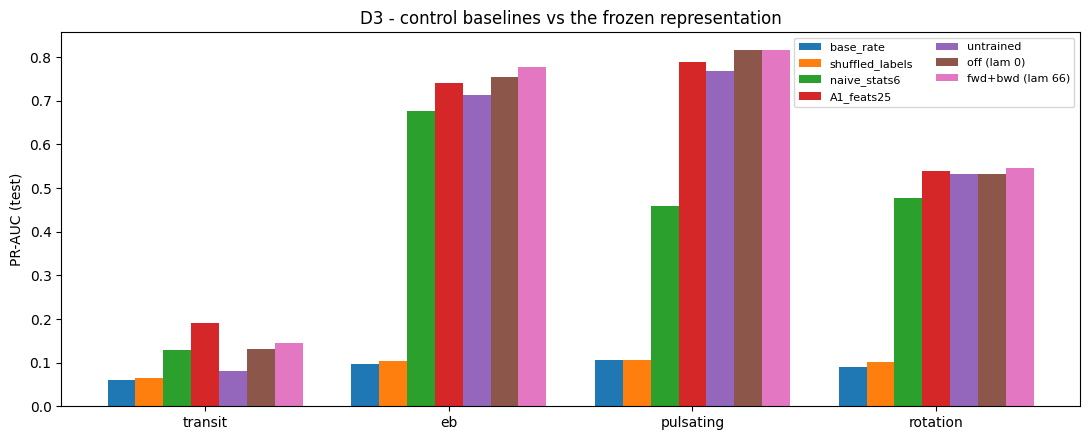

,naive6_gap,A1_gap,overstatement,SSL_beats_A1
task,,,,
transit,0.0153,-0.0452,-0.3393,False
eb,0.1008,0.0368,2.7385,True
pulsating,0.3572,0.0277,12.8985,True
rotation,0.0704,0.0068,10.4184,True


naive6_gap is what the old D3 bar chart implied; A1_gap is the honest margin.


In [29]:
# D3 (plot) - the same table as a grouped bar, which is how the gap actually reads
methods = ["base_rate", "shuffled_labels", "naive_stats6", "A1_feats25"] + list(PANEL_ARMS)
x = np.arange(len(TASKS)); w = 0.8 / len(methods)
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, m in enumerate(methods):
    ax.bar(x + i * w, controls.loc[TASKS, m], width=w, label=m)
ax.set_xticks(x + w * (len(methods) - 1) / 2); ax.set_xticklabels(TASKS)
ax.set_ylabel("PR-AUC (test)"); ax.set_title("D3 - control baselines vs the frozen representation")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); fig.savefig(figs_dir / "D3_controls.png", dpi=120, bbox_inches="tight"); plt.show()

# The comparison that actually matters: SSL against the HONEST feature baseline, not the naive one.
verdict = pd.DataFrame({
    "naive6_gap": controls["fwd+bwd (lam 66)"] - controls["naive_stats6"],
    "A1_gap": controls["fwd+bwd (lam 66)"] - controls["A1_feats25"],
})
verdict["overstatement"] = (verdict["naive6_gap"] / verdict["A1_gap"]).replace([np.inf, -np.inf], np.nan)
verdict["SSL_beats_A1"] = verdict["A1_gap"] > 0
display(verdict.round(4))
print("naive6_gap is what the old D3 bar chart implied; A1_gap is the honest margin.")

#### Plain-English read of D3 — control baselines

**What each bar is.** Every bar is PR-AUC on the same test split, so they are directly comparable:

- **`base_rate`** — what you score by guessing; the floor.
- **`shuffled_labels`** — the leak check. Star↔label association is broken *globally*, so a correct
  pipeline must fall to the base rate. If it does not, something is leaking.
- **`naive_stats6`** — six hand-computed numbers (std, MAD, skew, kurtosis, peak-to-peak, n_peaks).
- **`A1_feats25`** — the honest engineered baseline: the same 25-feature set (`swm.eval.features`)
  section G uses as the A1 ceiling — Lomb-Scargle peaks, 8 log-spaced PSD bands, spectral
  entropy/centroid, moments, MAD/IQR.
- **untrained / off / fwd+bwd** — the frozen latent arms.

**The leak check passes**: max |shuffled − base_rate| = **0.0119**. Worth keeping in mind how it is
built — permuting only the *train* labels is **not** a null here, because a fit on scrambled labels is
still a random linear projection of informative features and reads 2–3× the base rate even when
nothing is wrong. The association is permuted once, globally, for both splits.

**Why a second feature baseline was added.** `naive_stats6` carries **no periodicity information at
all** — no periodogram, no PSD bands, no spectral entropy. For three tasks *defined by* periodicity
that is the one thing a baseline must have, so scoring against it flatters the latent badly. (Its
`n_peaks` term uses `find_peaks` with no prominence threshold on noisy MAD-normalised flux, so it
mostly counts noise crossings — in practice another amplitude statistic.) The measured cost of that
straw man:

| task | naive6 gap | **A1 gap (honest)** | overstatement | SSL beats A1? |
|---|---|---|---|---|
| transit | +0.0153 | **−0.0452** | sign flip | **no** |
| eb | +0.1008 | +0.0368 | 2.7× | yes |
| pulsating | +0.3572 | **+0.0277** | **12.9×** | yes |
| rotation | +0.0704 | **+0.0068** | **10.4×** | yes |

So the original bar chart overstated the SSL advantage by ~13× on `pulsating` and ~10× on `rotation`,
and **flipped the sign on `transit`** — where 25 classic features (0.1901) comfortably beat the frozen
latent (0.1448).

**This mattered for internal consistency.** Section G reports that engineered features beat the SSL
representation on all 11 downstream probes. The old D3, using only the six naive moments, implied the
opposite on the v1 tasks. With the honest baseline the two sections agree in character: on these four
v1 tasks SSL still edges A1 on three, but by margins (+0.007 to +0.037) small enough that they would
need the 4-seed paired treatment to claim at all — and it loses `transit` outright.

Note also that the three μ columns here are **single-seed** (`PANEL_SEED`), unlike the engineered
baselines which are deterministic. The 4-seed paired verdict lives in section E; read D3 as
illustrative of the *ordering*, not as the headline gain.

---
## E. Criterion 1 — does weighting the dynamics improve the frozen representation? **MET**

The statistic is a **paired** Δ: `pr_auc(λ>0 cell) − pr_auc(the λ=0 `off` cell of the same recipe)`,
computed per seed and averaged over 4 seeds, confirmed when `mean > 2·SE` with `SE = SD/sqrt(4)`.
Pairing against `off` rather than against the untrained encoder is what makes this a test of the
*dynamics weight* specifically, rather than a restatement of "SSL beats random".

Numbers are loaded from `experiments/exp05_gap.csv` (written by `analyze_exp05_gap.py`) — never retyped.

In [30]:
gap = pd.read_csv(root / "experiments" / "exp05_gap.csv")
gap["mode"] = gap["cell"].str.extract(r"^(fwd|fbwd|multi)")[0].fillna("off")
gap["label"] = gap["recipe"] + " " + gap["cell"]
print(f"{len(gap)} cell x task rows | recipes {sorted(gap.recipe.unique())} | "
      f"confirmed {int(gap.confirm.sum())}/{len(gap)}")
gap.head()

40 cell x task rows | recipes ['comb', 'lpsd'] | confirmed 18/40


,recipe,cell,task,n_seeds,delta_vs_off_mean,delta_sd,delta_2se,confirm,cell_prauc_mean,off_prauc_mean,gap_vs_untrained_mean,mode,label
0,comb,fbwd_c0p1,pulsating,4,0.004366,0.026688,0.026688,False,0.792353,0.787987,0.024869,fbwd,comb fbwd_c0p1
1,comb,fbwd_c0p1,eb,4,0.018219,0.011312,0.011312,True,0.762413,0.744194,0.049826,fbwd,comb fbwd_c0p1
2,comb,fbwd_c0p1,rotation,4,0.047294,0.017320,0.017320,True,0.562760,0.515466,0.031025,fbwd,comb fbwd_c0p1
3,comb,fbwd_c0p1,transit,4,0.008934,0.026039,0.026039,False,0.129466,0.120532,0.048889,fbwd,comb fbwd_c0p1
4,comb,fbwd_c0p3,pulsating,4,0.010238,0.028052,0.028052,False,0.798225,0.787987,0.030742,fbwd,comb fbwd_c0p3


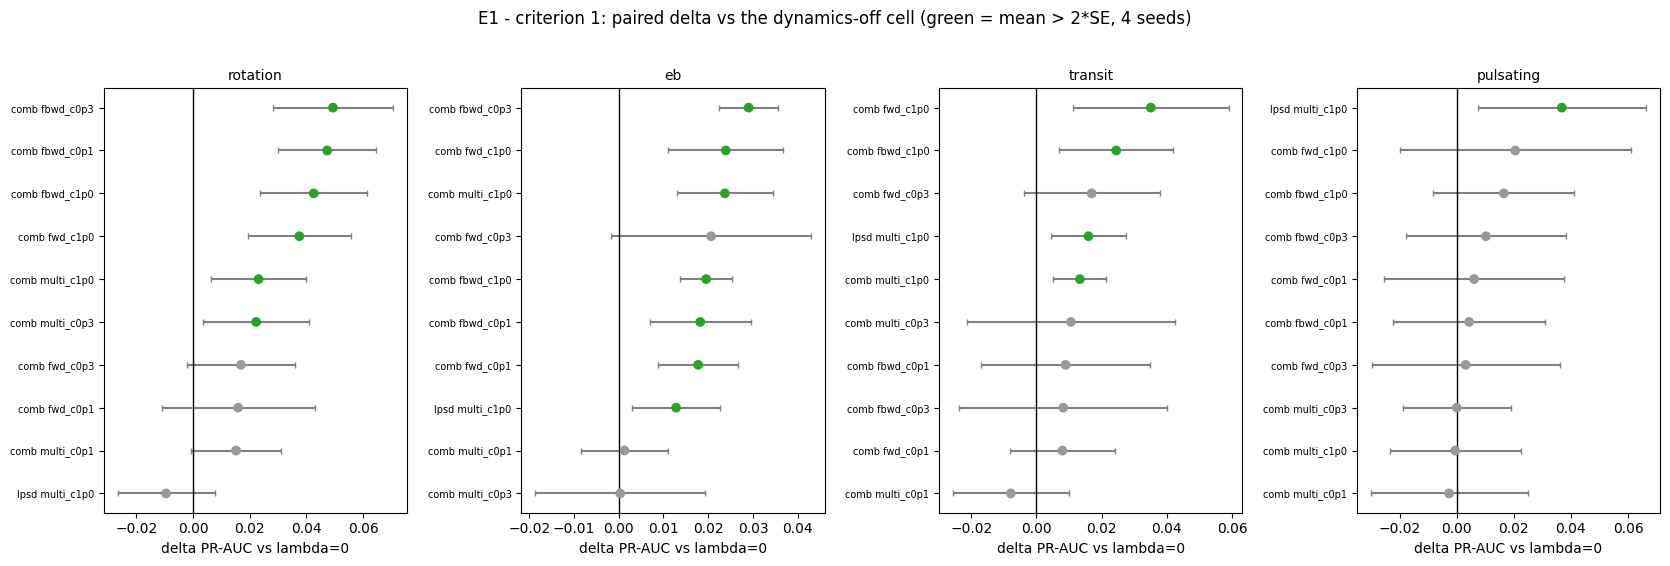

In [31]:
# E1 - forest plot: paired delta vs the lambda=0 cell, with the 2*SE bar, per task
tasks_order = ["rotation", "eb", "transit", "pulsating"]
fig, axes = plt.subplots(1, len(tasks_order), figsize=(4.2 * len(tasks_order), 5.5), sharex=False)
for ax, task in zip(axes, tasks_order):
    sub = gap[gap["task"] == task].sort_values("delta_vs_off_mean")
    y = np.arange(len(sub))
    colors = ["tab:green" if c else "0.6" for c in sub["confirm"]]
    ax.errorbar(sub["delta_vs_off_mean"], y, xerr=sub["delta_2se"], fmt="o",
                ecolor="0.5", capsize=2, ls="none", mfc="none", mec="none")
    ax.scatter(sub["delta_vs_off_mean"], y, c=colors, zorder=3)
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(sub["label"], fontsize=7)
    ax.set_title(f"{task}", fontsize=10); ax.set_xlabel("delta PR-AUC vs lambda=0")
fig.suptitle("E1 - criterion 1: paired delta vs the dynamics-off cell (green = mean > 2*SE, 4 seeds)", y=1.02)
plt.tight_layout(); fig.savefig(figs_dir / "E1_criterion1_forest.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of E1

**What the plot is.** One row per *training cell* (a recipe + dynamics mode + λ), one column per task.
The dot is the **paired Δ**: for each seed, `PR-AUC(this cell) − PR-AUC(the λ=0 "off" cell of the same
recipe)`, averaged over the 4 seeds. Pairing by seed matters — seed-to-seed noise is large, and
subtracting the same seed's own baseline cancels most of it. Right of the vertical line = the dynamics
weight helped. **Green = "confirmed"**, meaning the mean cleared the `> 2·SE` gate.

**Reading the error bar.** With 4 seeds, `2·SE = 2·sd/√4 = sd`, so the bar drawn is exactly ±1 sd of
the four per-seed deltas — and "confirmed" is precisely "the bar does not touch zero". Convenient, but
see the next point.

**Problem 1 — the gate is weaker than it looks.** `mean > 2·SE` with n=4 is `t > 2` on **3 degrees of
freedom**, which is a one-sided **p ≈ 0.070**, not 0.05. (A genuine one-sided p=0.05 would need
t ≥ 2.35.) And it is applied **40 times**, once per cell × task, with no multiplicity correction — under
a pure null you would expect **≈ 2.8 cells to "confirm" by chance**. 18 confirmed is far above that, so
the *aggregate* result is safe; the individual marginal cells are not. The five thinnest confirms:

| cell | task | Δ | t |
|---|---|---|---|
| comb multi_c0p3 | rotation | +0.022 | 2.39 |
| lpsd multi_c1p0 | pulsating | +0.037 | 2.50 |
| lpsd multi_c1p0 | eb | +0.013 | 2.60 |
| comb multi_c1p0 | rotation | +0.023 | 2.77 |
| lpsd multi_c1p0 | transit | +0.016 | 2.78 |

Three of those five are the **single `lpsd` cell** — which is also the one that carries the pulsating
headline.

**Problem 2 — the two recipes are not two sweeps.** `comb` contributes **9 cells** (3 modes × 3 rungs);
`lpsd` contributes **1**. So every lpsd claim rests on one cell × 4 seeds with no λ ladder behind it,
and cannot be checked for dose-response the way the comb cells can. It is a hedge, and the pulsating
result should be labelled as one.

**Problem 3 — a latent labelling bug.** `analyze_exp05_gap.py` sets `confirm = abs(mean) > 2·SE`, so a
strongly *negative* Δ would also be coloured green and listed under "confirmed". No row is affected
here (all 18 confirms happen to be positive), but the label is wrong as written.

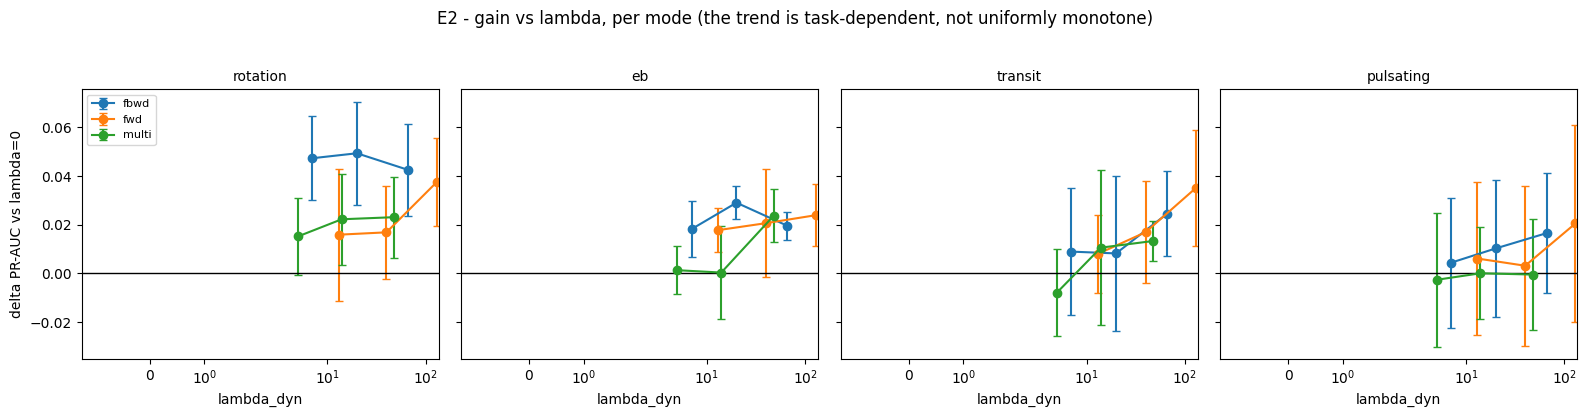

rotation    fwd+bwd  Spearman(lambda, delta) = -0.50   deltas [0.047, 0.049, 0.043]
eb          fwd+bwd  Spearman(lambda, delta) = +0.50   deltas [0.018, 0.029, 0.02]
transit     fwd+bwd  Spearman(lambda, delta) = +0.50   deltas [0.009, 0.008, 0.024]
pulsating   fwd+bwd  Spearman(lambda, delta) = +1.00   deltas [0.004, 0.01, 0.017]


In [32]:
# E2 - does the gain grow with lambda? one line per mode, per task (comb recipe only)
LAM_OF_CELL = {"fwd_c0p1": 13, "fwd_c0p3": 40, "fwd_c1p0": 130,
               "fbwd_c0p1": 7, "fbwd_c0p3": 20, "fbwd_c1p0": 66,
               "multi_c0p1": 5, "multi_c0p3": 14, "multi_c1p0": 48}
comb_gap = gap[(gap["recipe"] == "comb") & gap["cell"].isin(LAM_OF_CELL)].copy()
comb_gap["lam"] = comb_gap["cell"].map(LAM_OF_CELL)

fig, axes = plt.subplots(1, len(tasks_order), figsize=(4.0 * len(tasks_order), 4.0), sharey=True)
for ax, task in zip(axes, tasks_order):
    sub = comb_gap[comb_gap["task"] == task]
    for mode, grp in sub.groupby("mode"):
        grp = grp.sort_values("lam")
        ax.errorbar(grp["lam"], grp["delta_vs_off_mean"], yerr=grp["delta_2se"],
                    marker="o", capsize=3, label=mode)
    ax.axhline(0, color="k", lw=1)
    ax.set_xscale("symlog"); ax.set_title(task, fontsize=10); ax.set_xlabel("lambda_dyn")
axes[0].set_ylabel("delta PR-AUC vs lambda=0"); axes[0].legend(fontsize=8)
fig.suptitle("E2 - gain vs lambda, per mode (the trend is task-dependent, not uniformly monotone)", y=1.03)
plt.tight_layout(); fig.savefig(figs_dir / "E2_lambda_trend.png", dpi=120, bbox_inches="tight"); plt.show()

# Is "higher lambda -> bigger gain" actually true per task? Report it rather than assert it.
for task in tasks_order:
    sub = comb_gap[(comb_gap["task"] == task) & (comb_gap["mode"] == "fbwd")].sort_values("lam")
    if len(sub) > 2:
        r = stats.spearmanr(sub["lam"], sub["delta_vs_off_mean"])
        print(f"{task:11s} fwd+bwd  Spearman(lambda, delta) = {r.statistic:+.2f}   "
              f"deltas {[round(v, 3) for v in sub['delta_vs_off_mean']]}")

#### Plain-English read of E2 — and why the x-axis is the wrong one

**What it asks.** Turn the dynamics weight up: does the gain grow? One line per mode, x = λ on a log
scale, y = the same paired Δ as E1.

**Problem 1 — raw λ is not comparable across modes, by construction.** λ was **back-solved per mode**
so that all three modes hit the *same* target dynamics contribution rung {0.1, 0.3, 1.0}:

| rung | fwd+bwd | fwd | multistep |
|---|---|---|---|
| 0.1 | λ=7 | λ=13 | λ=5 |
| 0.3 | λ=20 | λ=40 | λ=14 |
| 1.0 | **λ=66** | **λ=130** | λ=48 |

`fwd@130` and `fwd+bwd@66` are the **same dose**, but the plot draws them a factor of 2 apart. The `fwd`
line therefore appears to extend further right and keep climbing, which is an artifact of the axis. On
top of that, A4 showed **multistep never reached its target** (achieved 0.63 at the rung it was
calibrated to 1.0), so its points are plotted at a nominal dose it did not receive. **E2b re-draws all
of it against the achieved contribution.**

**Problem 2 — the printed Spearman cannot say anything.** It is computed **per mode, over 3 points**.
With n=3 the only attainable |ρ| values are 0.5 and 1.0, and the smallest attainable two-sided p is
**0.333** — no dose-response claim in this panel can ever reach significance, including the `ρ = +1.00`
printed for pulsating. Pooling the three modes (n=9, in E2b) gives a test that can actually reject:
**transit ρ = +0.85, p = 0.004** on the achieved axis, eb ρ = +0.68, p = 0.042.

**Problem 3 — the `lpsd` cell is filtered out.** The panel is `comb`-only, so the one cell where
`pulsating` confirms is absent from the very panel where pulsating looks flat and null.

**Problem 4 — cosmetic but misleading.** The symlog axis reserves the left ~40% of every panel for
λ ∈ [0, 5] where no point exists, compressing the region that actually has data.

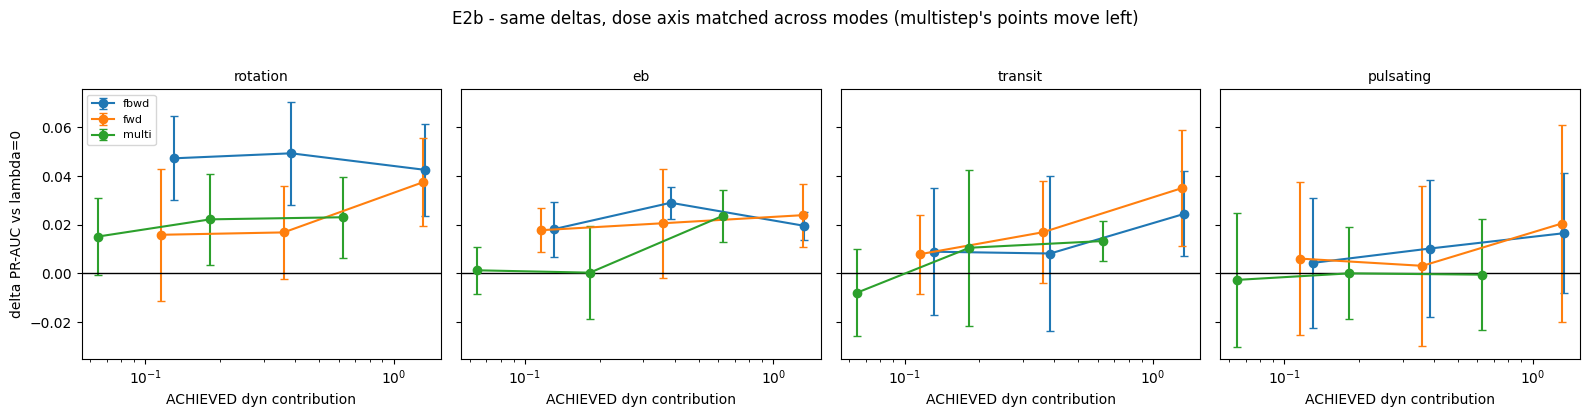

Spearman(dose, delta) pooled over all 3 modes, comb recipe (n=9 per task):
  task            vs raw lambda    vs target rung     vs ACHIEVED
  rotation      +0.367 (p=0.332)   +0.369 (p=0.329)   +0.583 (p=0.099)
  eb            +0.667 (p=0.050)   +0.580 (p=0.102)   +0.683 (p=0.042)
  transit       +0.900 (p=0.001)   +0.843 (p=0.004)   +0.850 (p=0.004)
  pulsating     +0.567 (p=0.112)   +0.369 (p=0.329)   +0.583 (p=0.099)

Paired mode contrast at matched target rung (n=4 seeds, same |mean| > 2*SE gate):
  rung c0p1
    rotation      fbwd-fwd   +0.0314 +-0.0229 PASS   fbwd-multi +0.0321 +-0.0123 PASS
    eb            fbwd-fwd   +0.0005 +-0.0110   .    fbwd-multi +0.0169 +-0.0110 PASS
    transit       fbwd-fwd   +0.0010 +-0.0290   .    fbwd-multi +0.0168 +-0.0111 PASS
    pulsating     fbwd-fwd   -0.0017 +-0.0118   .    fbwd-multi +0.0070 +-0.0179   . 
  rung c0p3
    rotation      fbwd-fwd   +0.0325 +-0.0206 PASS   fbwd-multi +0.0271 +-0.0141 PASS
    eb            fbwd-fwd   +0.0084 +

In [33]:
# E2b - the dose question on an axis that is comparable ACROSS modes, plus the mode contrast.
# E2's x-axis is raw lambda, but lambda was BACK-SOLVED per mode to hit a common target contribution
# rung {0.1, 0.3, 1.0}: fwd@130 and fwd+bwd@66 are the SAME dose, drawn a factor 2 apart. Here x is
# the ACHIEVED contribution measured in A4, which additionally folds in multistep's calibration miss.

# Per-seed probe scores, reproducing analyze_exp05_gap.py's filters exactly. Needed because the
# aggregated csv keeps only the mean and sd -- the mode contrast below has to be paired by seed.
_raw = pd.concat([pd.read_csv(p) for p in root.glob("experiments/exp05_*/results/readout_sweep.csv")],
                 ignore_index=True)
_raw = _raw[(_raw.pooling == "mean") & (_raw.readout == "logistic") & (_raw.ckpt == CKPT)]
_raw = _raw[_raw.get("labels_version", "v1").fillna("v1") == "v1"]
if "run_id" in _raw.columns:
    _raw = _raw.sort_values("run_id")
per_seed = _raw.drop_duplicates(subset=["exp_name", "seed", "task"], keep="last").copy()
per_seed["recipe"] = np.where(per_seed.exp_name.str.contains("lpsd"), "lpsd", "comb")
per_seed["cell"] = per_seed.exp_name.str.replace(r"exp05_(comb|lpsd)_", "", regex=True)


def paired_delta(recipe, cell, task):
    """Per-seed pr_auc(cell) - pr_auc(the lambda=0 cell of the same recipe), aligned on seed."""
    s = per_seed[(per_seed.recipe == recipe) & (per_seed.task == task)]
    m = s[s.cell == cell][["seed", "pr_auc"]].merge(
        s[s.cell == "off"][["seed", "pr_auc"]], on="seed", suffixes=("_c", "_o"))
    return (m["pr_auc_c"] - m["pr_auc_o"]).to_numpy()


# Guard: this reconstruction must reproduce exp05_gap.csv exactly, or the two would drift apart silently.
_err = max(abs(paired_delta(r.recipe, r.cell, r.task).mean() - r.delta_vs_off_mean)
           for r in gap.itertuples())
assert _err < 1e-9, f"per-seed reconstruction disagrees with exp05_gap.csv by {_err:.2e}"

# Achieved dynamics contribution per cell, same definition as A4 (post beta-warmup steady state).
ach_rows = []
for cell, lam in LAMBDA.items():
    if lam == 0:
        continue
    vals = []
    for seed in range(4):
        c = load_curve(cell, seed).query("epoch >= 15")
        vals.append(float((lam * c["train/dyn"] / c["train/recon"]).mean()))
    ach_rows.append({"recipe": "lpsd" if "lpsd" in cell else "comb",
                     "cell": cell.split("_", 2)[2], "lam": lam,
                     "target": TARGET[cell.rsplit("_", 1)[1]], "achieved": float(np.mean(vals))})
ach = pd.DataFrame(ach_rows)
dose = gap.merge(ach, on=["recipe", "cell"], how="inner")

fig, axes = plt.subplots(1, len(tasks_order), figsize=(4.0 * len(tasks_order), 4.0), sharey=True)
for ax, task in zip(axes, tasks_order):
    sub = dose[(dose["task"] == task) & (dose["recipe"] == "comb")]
    for mode, grp in sub.groupby("mode"):
        grp = grp.sort_values("achieved")
        ax.errorbar(grp["achieved"], grp["delta_vs_off_mean"], yerr=grp["delta_2se"],
                    marker="o", capsize=3, label=mode)
    ax.axhline(0, color="k", lw=1)
    ax.set_xscale("log"); ax.set_title(task, fontsize=10)
    ax.set_xlabel("ACHIEVED dyn contribution")
axes[0].set_ylabel("delta PR-AUC vs lambda=0"); axes[0].legend(fontsize=8)
fig.suptitle("E2b - same deltas, dose axis matched across modes (multistep's points move left)", y=1.03)
plt.tight_layout(); fig.savefig(figs_dir / "E2b_dose_matched.png", dpi=120, bbox_inches="tight"); plt.show()

# Pooling the 3 modes gives n=9 per task -- E2's per-mode Spearman has n=3, where the smallest
# attainable two-sided p is 0.333, so it can never reject anything.
print("Spearman(dose, delta) pooled over all 3 modes, comb recipe (n=9 per task):")
print(f"  {'task':11s}{'vs raw lambda':>18}{'vs target rung':>18}{'vs ACHIEVED':>16}")
for task in tasks_order:
    g = dose[(dose["task"] == task) & (dose["recipe"] == "comb")]
    cells = []
    for col in ["lam", "target", "achieved"]:
        r = stats.spearmanr(g[col], g["delta_vs_off_mean"])
        cells.append(f"{r.statistic:+.3f} (p={r.pvalue:.3f})")
    print(f"  {task:11s}{cells[0]:>19}{cells[1]:>19}{cells[2]:>19}")

# The mode ranking, contrasted at MATCHED dose and paired by seed -- the comparison E2's x-axis hides.
print("\nPaired mode contrast at matched target rung (n=4 seeds, same |mean| > 2*SE gate):")
for rung in ["c0p1", "c0p3", "c1p0"]:
    print(f"  rung {rung}")
    for task in tasks_order:
        out = ""
        for other in ["fwd", "multi"]:
            d = (per_seed[(per_seed.cell == f"fbwd_{rung}") & (per_seed.task == task)
                          & (per_seed.recipe == "comb")].sort_values("seed")["pr_auc"].to_numpy()
                 - per_seed[(per_seed.cell == f"{other}_{rung}") & (per_seed.task == task)
                            & (per_seed.recipe == "comb")].sort_values("seed")["pr_auc"].to_numpy())
            se2 = 2 * d.std(ddof=1) / np.sqrt(len(d))
            out += f"   fbwd-{other:<5} {d.mean():+.4f} +-{se2:.4f} {'PASS' if abs(d.mean()) > se2 else '  . '}"
        print(f"    {task:11s}{out}")

#### E2b — what changes when the dose axis is fixed

**1. There *is* a dose-response; E2 just could not detect it.** Pooling the three modes gives n=9 per
task instead of 3:

| task | vs raw λ | vs target rung | vs **achieved** contribution |
|---|---|---|---|
| transit | +0.900 (p=0.001) | +0.843 (p=0.004) | **+0.850 (p=0.004)** |
| eb | +0.667 (p=0.050) | +0.580 (p=0.102) | **+0.683 (p=0.042)** |
| rotation | +0.367 (p=0.332) | +0.369 (p=0.329) | +0.583 (p=0.099) |
| pulsating | +0.567 (p=0.112) | +0.369 (p=0.329) | +0.583 (p=0.099) |

So "more dynamics weight → bigger gain" is supported for **transit and eb**, and is only suggestive for
rotation and pulsating. Note this inverts the emphasis of the existing verdict text, which credited the
monotone trend to *transit and pulsating*.

**2. "fwd+bwd is the strongest mode" does not survive dose matching.** Paired per-seed contrasts at the
same rung, with the same gate:

| rung | task | fbwd − fwd | passes gate? |
|---|---|---|---|
| 0.1 | rotation | **+0.0314** | yes |
| 0.3 | rotation | **+0.0325** | yes |
| 1.0 | rotation | +0.0051 | no |
| 1.0 | transit | **−0.0106** | yes — **fwd is better** |
| all | eb, pulsating | −0.004 … +0.008 | no |

fwd+bwd is measurably ahead of plain fwd **only on `rotation`, and only at the two lower rungs** — and
`rotation` is the task §D1b flags as label-confounded. At the top rung plain `fwd` is significantly
better on `transit`, and it has the numerically largest Δ on eb, transit *and* pulsating. The defensible
mode ranking is **fwd+bwd ≈ fwd > multistep**, not "fwd+bwd is strongest".

**3. Part of multistep's deficit is dose, not objective.** At the c1p0 rung multistep achieved **0.63**
against fwd+bwd's 1.33 — half the dose. On the matched axis its points slide left, and for `eb` and
`transit` they land close to where the fwd+bwd curve is at that dose. For `rotation` and `pulsating` it
still underperforms at matched dose. So the honest split is: **multistep is genuinely worse on rotation
and pulsating; on eb and transit its deficit is largely the calibration miss.** Disentangling them
needs a multistep cell re-tuned to actually reach contribution 1.0 — the same 2×2 the window-edge issue
asks for.

In [34]:
# E3 - which cells confirmed, and the winner table
confirmed = gap[gap["confirm"]].sort_values("delta_vs_off_mean", ascending=False)
print(f"confirmed cells (mean > 2*SE): {len(confirmed)} of {len(gap)}\n")
# display() on a .to_string() result renders the string's repr, not a table.
display(confirmed[["recipe", "cell", "task", "delta_vs_off_mean", "delta_2se",
                   "cell_prauc_mean", "off_prauc_mean", "gap_vs_untrained_mean"]].round(4)
        .reset_index(drop=True))

pivot = gap.pivot_table(index=["recipe", "cell"], columns="task",
                        values="delta_vs_off_mean").reindex(columns=tasks_order)
mark = gap.pivot_table(index=["recipe", "cell"], columns="task",
                       values="confirm").reindex(columns=tasks_order)
styled = pivot.round(3).astype(str) + np.where(mark.fillna(False), " *", "")
print("\ndelta vs lambda=0  (* = confirmed at > 2*SE)")
display(styled)

confirmed cells (mean > 2*SE): 18 of 40



,recipe,cell,task,delta_vs_off_mean,delta_2se,cell_prauc_mean,off_prauc_mean,gap_vs_untrained_mean
0,comb,fbwd_c0p3,rotation,0.0493,0.0212,0.5648,0.5155,0.0331
1,comb,fbwd_c0p1,rotation,0.0473,0.0173,0.5628,0.5155,0.0310
2,comb,fbwd_c1p0,rotation,0.0426,0.0190,0.5580,0.5155,0.0263
3,comb,fwd_c1p0,rotation,0.0375,0.0182,0.5529,0.5155,0.0212
4,lpsd,multi_c1p0,pulsating,0.0368,0.0295,0.7941,0.7573,0.0266
5,comb,fwd_c1p0,transit,0.0351,0.0238,0.1556,0.1205,0.0750
6,comb,fbwd_c0p3,eb,0.0290,0.0067,0.7732,0.7442,0.0606
7,comb,fbwd_c1p0,transit,0.0245,0.0175,0.1450,0.1205,0.0644
8,comb,fwd_c1p0,eb,0.0239,0.0129,0.7681,0.7442,0.0555
9,comb,multi_c1p0,eb,0.0237,0.0107,0.7679,0.7442,0.0553



delta vs lambda=0  (* = confirmed at > 2*SE)


task              rotation       eb  transit pulsating
recipe cell                                           
comb   fbwd_c0p1   0.047 *  0.018 *    0.009     0.004
       fbwd_c0p3   0.049 *  0.029 *    0.008      0.01
       fbwd_c1p0   0.043 *   0.02 *  0.024 *     0.017
       fwd_c0p1      0.016  0.018 *    0.008     0.006
       fwd_c0p3      0.017    0.021    0.017     0.003
       fwd_c1p0    0.037 *  0.024 *  0.035 *     0.021
       multi_c0p1    0.015    0.001   -0.008    -0.003
       multi_c0p3  0.022 *      0.0    0.011       0.0
       multi_c1p0  0.023 *  0.024 *  0.013 *      -0.0
lpsd   multi_c1p0    -0.01  0.013 *  0.016 *   0.037 *

#### Plain-English read of E3 — and the baseline the table does not test

**What the two tables are.** The first lists the 18 cell × task combinations that cleared the gate,
sorted by Δ. The second is the same numbers as a grid, `*` marking confirmation — it is the compact
form worth quoting.

**How to read it.** Rotation confirms in 6 of 10 cells, eb in 7, transit in 4, pulsating in 1 (the lpsd
hedge). The pattern is consistent, not scattered — that consistency, rather than any single cell, is
what makes criterion 1 credible.

**Problem 1 — "beats λ=0" is not "beats doing nothing".** The table's last column,
`gap_vs_untrained_mean`, compares the *absolute* level to a random-init encoder, and it tells a
different story. The λ=0 baseline itself sits **below** the untrained encoder on rotation:

| task | λ=0 (`off`) | untrained | off − untrained |
|---|---|---|---|
| transit | 0.1205 | 0.0806 | +0.0400 |
| eb | 0.7442 | 0.7126 | +0.0316 |
| pulsating | 0.7880 | 0.7675 | +0.0205 |
| **rotation** | **0.5155** | **0.5317** | **−0.0163** |

On rotation the dynamics-off training *lost* 0.016 relative to a random encoder, so the first 0.016 of
every rotation gain is recovering a deficit that training itself created, not producing new signal.
Four confirmed cells end up barely clearing untrained at all:

| cell | task | Δ vs λ=0 | gap vs untrained |
|---|---|---|---|
| comb multi_c0p3 | rotation | +0.0222 | **+0.0060** |
| comb multi_c1p0 | rotation | +0.0231 | **+0.0068** |
| comb fwd_c1p0 | rotation | +0.0375 | +0.0212 |
| lpsd multi_c1p0 | pulsating | +0.0368 | +0.0266 |

**Problem 2 — the untrained column is never gated.** `exp05_gap.csv` carries no seed sd for
`gap_vs_untrained_mean`, so the >2·SE test is applied *only* to the Δ-vs-off column. The number readers
will care about most — "is this better than a random encoder?" — is reported without any uncertainty at
all.

**Problem 3 — display, not statistics (fixed).** The confirmed table was passed through `.to_string()`
and then `display()`, so the section's primary result rendered as a quoted string with a literal
newline escape instead of as a table — the least readable output in the notebook. It now displays
the DataFrame directly.

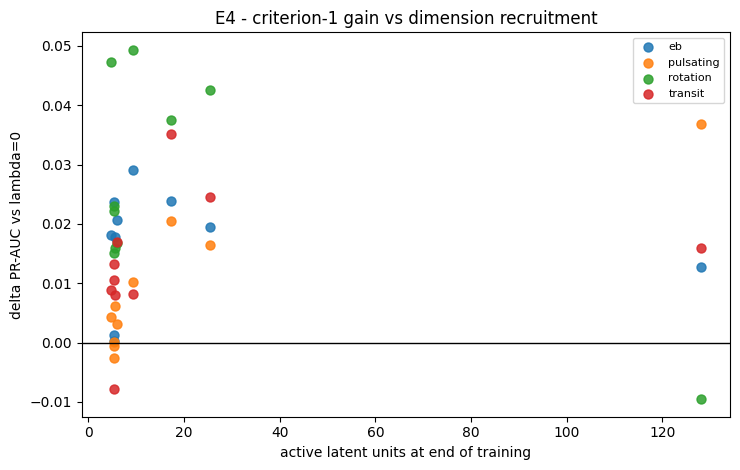

eb          Spearman(n_active, delta) = +0.288  (p=0.419, n=10)
pulsating   Spearman(n_active, delta) = +0.828  (p=0.003, n=10)
rotation    Spearman(n_active, delta) = -0.092  (p=0.800, n=10)
transit     Spearman(n_active, delta) = +0.583  (p=0.077, n=10)


In [35]:
# E4 - the mechanism link: does dimension recruitment predict the criterion-1 gain?
# Joins B1's active-unit count to E1's delta -- if collapse-reversal is the mechanism, these correlate.
act = latent.groupby(["recipe", "cell_raw"], as_index=False)["n_active"].mean()
merged = gap.merge(act, left_on=["recipe", "cell"], right_on=["recipe", "cell_raw"], how="inner")
assert len(merged) == len(gap), f"join dropped rows: {len(merged)} vs {len(gap)}"

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for task, grp in merged.groupby("task"):
    ax.scatter(grp["n_active"], grp["delta_vs_off_mean"], label=task, s=42, alpha=0.85)
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("active latent units at end of training"); ax.set_ylabel("delta PR-AUC vs lambda=0")
ax.set_title("E4 - criterion-1 gain vs dimension recruitment")
ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(figs_dir / "E4_gain_vs_active.png", dpi=120, bbox_inches="tight"); plt.show()

for task, grp in merged.groupby("task"):
    if len(grp) > 3:
        r = stats.spearmanr(grp["n_active"], grp["delta_vs_off_mean"])
        print(f"{task:11s} Spearman(n_active, delta) = {r.statistic:+.3f}  (p={r.pvalue:.3f}, n={len(grp)})")

#### Plain-English read of E4

**What it asks.** B1 found that turning the dynamics weight up recruits latent dimensions (5 → 25
active units). E4 asks whether that recruitment is *why* the probe improves: it plots each cell's mean
active-unit count against that cell's mean Δ, and correlates them.

**What it appears to show.** pulsating ρ = +0.83 (p = 0.003), transit +0.58, eb +0.29, rotation −0.09.
Read naively: recruitment predicts the gain, at least for pulsating.

**Problem 1 — the x-axis mixes two incompatible measurement regimes.** The lone point at x = 128 is the
`lpsd` cell, and B1 established that its 128/128 is close to an **artifact**: `lpsd` uses
`free_bits = 0.02`, which is above the 0.01 activity threshold, so *every* dimension is floored into the
"active" count by construction. All nine `comb` cells live in 4.75–25.5. Plotting them on one axis puts
a construction artifact at ~5× the leverage of any real point. *(Checked: dropping it weakens pulsating
to ρ = +0.76, p = 0.017 — so this particular correlation does not depend on it, but the axis is still
not one quantity.)*

**Problem 2 — this is not an independent test of the mechanism.** Active units are largely *determined*
by (mode, λ): between-cell differences account for ~43% of the variance, and the ordering across cells
is essentially B1's dose curve. So the scatter cannot separate "recruitment causes the gain" from
"λ causes both" — it is close to E2's dose plot with a relabelled x-axis. **E4b runs the test that can
separate them.**

**Problem 3 — four correlations, no multiplicity correction.** With 4 tasks tested, a Bonferroni
threshold would be p < 0.0125. `pulsating` clears it at ρ = +0.83 (p = 0.003) using all 10 points, but
**not** at p = 0.017 once the lpsd artifact point is removed. Nothing else is close.

var(n_active) total 79.7 | mean within-cell 45.3 -> (mode, lambda) explains 43% of it
so E4's x-axis is largely the E2 dose axis wearing a different label.



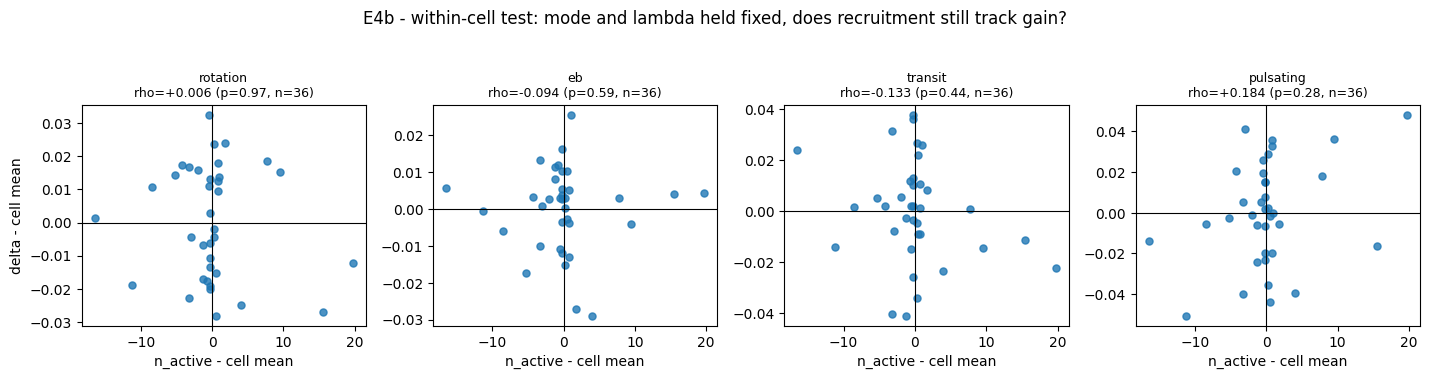

task         cell-mean rho (E4)   within-cell rho       p    n
rotation                  0.254             0.006   0.973   36
eb                        0.542            -0.094   0.587   36
transit                   0.542            -0.133   0.440   36
pulsating                 0.763             0.184   0.284   36

spread available to the within-cell test (comb, per cell):


,mean,std,min,max
cell_raw,,,,
fbwd_c0p1,4.75,0.50,4.0,5.0
fbwd_c0p3,9.25,5.44,5.0,17.0
fbwd_c1p0,25.50,15.00,9.0,41.0
fwd_c0p1,5.50,0.58,5.0,6.0
fwd_c0p3,6.00,3.16,3.0,10.0
fwd_c1p0,17.25,13.60,6.0,37.0
multi_c0p1,5.25,0.50,5.0,6.0
multi_c0p3,5.25,1.26,4.0,7.0
multi_c1p0,5.25,0.96,4.0,6.0


In [36]:
# E4b - is dimension recruitment the MECHANISM, or is E4 the E2 dose axis re-plotted?
# B1 showed n_active is largely set by (mode, lambda). A scatter over CELL MEANS therefore cannot
# separate "recruitment causes the gain" from "lambda causes both". The separating test uses the
# within-cell seed spread B1 flagged as large: holding the cell fixed, does the seed that recruited
# more dimensions get the bigger delta?
lat_seed = latent[latent["recipe"] == "comb"]
_v_tot = lat_seed["n_active"].var(ddof=1)
_v_in = lat_seed.groupby("cell_raw")["n_active"].var(ddof=1).mean()
print(f"var(n_active) total {_v_tot:.1f} | mean within-cell {_v_in:.1f} -> "
      f"(mode, lambda) explains {100 * (1 - _v_in / _v_tot):.0f}% of it")
print("so E4's x-axis is largely the E2 dose axis wearing a different label.\n")

ps = []
for r in gap[gap["recipe"] == "comb"].itertuples():
    d = paired_delta("comb", r.cell, r.task)
    for seed, val in enumerate(d):
        ps.append({"cell_raw": r.cell, "task": r.task, "seed": seed, "delta": val})
ps = pd.DataFrame(ps).merge(lat_seed[["cell_raw", "seed", "n_active"]], on=["cell_raw", "seed"])
# Demean within cell: each point becomes "this seed vs its own cell's average", so mode and lambda
# are held fixed by construction and only the seed-to-seed recruitment lottery is left.
ps["n_dm"] = ps["n_active"] - ps.groupby(["cell_raw", "task"])["n_active"].transform("mean")
ps["d_dm"] = ps["delta"] - ps.groupby(["cell_raw", "task"])["delta"].transform("mean")

fig, axes = plt.subplots(1, len(tasks_order), figsize=(3.6 * len(tasks_order), 3.6), sharex=True)
for ax, task in zip(axes, tasks_order):
    g = ps[ps["task"] == task]
    ax.scatter(g["n_dm"], g["d_dm"], s=26, alpha=0.8)
    ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
    r = stats.spearmanr(g["n_dm"], g["d_dm"])
    ax.set_title(f"{task}\nrho={r.statistic:+.3f} (p={r.pvalue:.2f}, n={len(g)})", fontsize=9)
    ax.set_xlabel("n_active - cell mean")
axes[0].set_ylabel("delta - cell mean")
fig.suptitle("E4b - within-cell test: mode and lambda held fixed, does recruitment still track gain?", y=1.04)
plt.tight_layout(); fig.savefig(figs_dir / "E4b_within_cell.png", dpi=120, bbox_inches="tight"); plt.show()

print(f"{'task':11s}{'cell-mean rho (E4)':>20}{'within-cell rho':>18}{'p':>8}{'n':>5}")
for task in tasks_order:
    g = ps[ps["task"] == task]
    cm = g.groupby("cell_raw")[["n_active", "delta"]].mean()
    print(f"{task:11s}{stats.spearmanr(cm.n_active, cm.delta).statistic:>20.3f}"
          f"{stats.spearmanr(g.n_dm, g.d_dm).statistic:>18.3f}"
          f"{stats.spearmanr(g.n_dm, g.d_dm).pvalue:>8.3f}{len(g):>5}")
print("\nspread available to the within-cell test (comb, per cell):")
display(lat_seed.groupby("cell_raw")["n_active"].agg(["mean", "std", "min", "max"]).round(2))

#### E4b — the mechanism claim does not survive the within-cell test

**The idea.** If recruiting dimensions is the causal channel, it should work *within* a cell too, not
only across the dose ladder. B1 showed the seed-to-seed spread in active units is enormous — at
`fbwd_c1p0` the four seeds recruited **9, 17, 35 and 41** units (sd = 15) — which is real variation
to test on. So: subtract each cell's own mean from both quantities and ask whether the seeds that
happened to recruit more also gained more. Mode and λ are then held fixed by construction.

| task | cell-mean ρ (what E4 plots) | **within-cell ρ** | p | n |
|---|---|---|---|---|
| rotation | +0.254 | **+0.006** | 0.97 | 36 |
| eb | +0.542 | **−0.094** | 0.59 | 36 |
| transit | +0.542 | **−0.133** | 0.44 | 36 |
| pulsating | +0.763 | **+0.184** | 0.28 | 36 |

**Every correlation collapses to nothing.** A seed that recruited 41 dimensions did not out-score its
sibling that recruited 9. There is also no seed-level alignment: seed 1 has the highest mean recruitment
(12.4 units) but seed 2 — the *lowest* at 6.8 — posts the biggest transit and eb gains.

**What this does and does not license.**

- It does **not** refute collapse-reversal. Recruitment and gain still co-move along the λ axis, and
  with 36 points against per-seed Δ noise of ~0.02–0.03 this test can only rule out a *large* within-cell
  effect.
- It **does** mean E4 provides no evidence for the causal direction. "λ up → more active dims" (B1) and
  "λ up → better probe" (E1/E2b) are both solid; "more active dims → better probe" is the link that is
  asserted and not demonstrated.
- Practically: **active-unit count is a marker of the treatment, not a knob to optimise.** Selecting
  checkpoints or cells by n_active would not be expected to buy probe quality. Any write-up should say
  "dimension recruitment accompanies the gain" rather than "is the mechanism behind it" until a
  manipulation that moves recruitment *without* moving λ is run.

**Verdict — criterion 1 MET.** Weighting the dynamics term up beats the λ=0 cell on
rotation +0.043…+0.049, eb +0.029, transit +0.035 (`fwd@130`) — all > 2·SE over 4 seeds, 18 of 40
cell × task combinations confirmed against ≈2.8 expected by chance.

**Caveat on the largest gain.** `rotation` is the biggest winner here, but see **§D1b**: in the frozen v1
subset every rotation positive is also a transit/eb/pulsating star and no quiet star is rotation-positive,
so the rotation probe is partly a general-variability detector. The paired Δ is still valid (both arms
share the confound), but the interpretation of *what improved* should be stated carefully. **§E3** adds a
second caveat on the same task: the λ=0 baseline sits 0.016 *below* the untrained encoder on rotation, so
part of the gain is recovering a deficit training itself created.

**Corrections to the earlier summary phrasing** (all three measured in §E2b/§E4b, not asserted):

1. **"Higher λ → bigger gain" is task-dependent.** On the dose axis matched across modes it is real for
   **transit** (ρ=+0.85, p=0.004) and **eb** (ρ=+0.68, p=0.042), and only suggestive for rotation and
   pulsating (both p≈0.10). Per-mode the ladders are non-monotone: rotation plateaus (+0.047 → +0.049 →
   +0.043) and eb peaks at the middle rung.
2. **"`fwd+bwd` is the strongest mode" does not survive dose matching.** λ was back-solved per mode, so
   raw λ is not comparable; at matched rungs fwd+bwd beats plain `fwd` only on **rotation** (and only at
   the two lower rungs), while `fwd` is significantly better on **transit** at the top rung. The
   defensible ranking is **fwd+bwd ≈ fwd > multistep**.
3. **Dimension recruitment accompanies the gain rather than explaining it.** Across cells the two
   correlate, but within a cell — where seeds recruit anywhere from 9 to 41 units at fixed λ — the
   correlation vanishes (|ρ| ≤ 0.18, all p > 0.28).

`pulsating` stays null under the `comb` recipe, exactly as in exp04, but the `lpsd` hedge cell
(`multistep@32`) confirms +0.037. That cell is a **single** cell × 4 seeds with no λ ladder behind it and
three of the five thinnest confirms in the whole section, so it should be reported as a hedge, not as a
second sweep. Even so, this is the project's first result where a *training-objective* change moves the
frozen representation, rather than SSL merely matching an untrained encoder.

---
## F. Criterion 2 — did the rollout learn physics? **PARTIAL**

Pre-registration: a free-running 15-step latent rollout should beat a copy-last **persistence** baseline,
and should beat it **more on periodic stars than on quiet ones** — because periodic stars are where real
dynamics exist to be learned, whereas a quiet star is trivially predicted by "nothing changes".

What happened, split into its two halves:

1. **Rollout beats persistence on every class** — gain ratio > 1 everywhere, up to 2.7×. The dynamics
   carry genuine predictive signal.
2. **The ordering did not appear** — the gain is slightly *larger* on quiet stars than periodic ones, and
   decoded periodic rollouts relax toward flat.

So the rollout learned **"smooth is predictable"**, which is necessary but not sufficient for "learned
periodic physics". Neither a win nor a null: an explicit improvement target for exp06.

**Judge this on the `multistep` cells only.** The `fwd` and `fwd_bwd` cells trained teacher-forced
one-step, so evaluating them under a free-running rollout is off-distribution and their numbers are not
a fair test of the hypothesis.

In [37]:
roll = pd.read_csv(root / "experiments" / "exp05_rollout_summary.csv")
roll["in_distribution"] = roll["mode"] == "multistep"     # only these trained under a free-running rollout
roll = roll.sort_values(["in_distribution", "lambda_dyn"], ascending=[False, True]).reset_index(drop=True)
display(roll[["cell", "mode", "lambda_dyn", "periodic_ratio", "quiet_ratio",
              "periodic_minus_quiet_ratio", "in_distribution"]].round(3))

# The summary csv keeps only per-cell means, and section F was the one place in this notebook that
# never showed seed spread -- which is how four diverged runs stayed invisible. Load the per-seed rows.
roll_seed = pd.concat([pd.read_csv(p) for p in
                       root.glob("experiments/exp05_*/results/rollout_vs_persistence.csv")],
                      ignore_index=True).drop_duplicates(subset=["exp", "seed", "class"], keep="last")
roll_seed["cell"] = roll_seed["exp"].str.replace("exp05_", "", regex=False)

lost = roll_seed[roll_seed["gain_ratio"] < 1.0]
print(f"cell x seed x class rows where the rollout LOSES to persistence: {len(lost)} of {len(roll_seed)}")
display(lost[["cell", "seed", "class", "rollout_mse", "persistence_mse", "gain_ratio",
              "beats_persistence_frac"]].round(4).reset_index(drop=True))

,cell,mode,lambda_dyn,periodic_ratio,quiet_ratio,periodic_minus_quiet_ratio,in_distribution
0,comb_multi_c0p1,multistep,5,2.145,2.655,-0.510,True
1,comb_multi_c0p3,multistep,14,2.152,2.696,-0.544,True
2,lpsd_multi_c1p0,multistep,32,2.191,2.695,-0.504,True
3,comb_multi_c1p0,multistep,48,2.173,2.707,-0.533,True
4,comb_off,fwd,0,1.395,1.307,0.088,False
5,lpsd_off,fwd,0,1.323,1.553,-0.230,False
6,comb_fbwd_c0p1,fwd_bwd,7,2.028,2.513,-0.485,False
7,comb_fwd_c0p1,fwd,13,1.345,1.566,-0.220,False
8,comb_fbwd_c0p3,fwd_bwd,20,1.874,2.326,-0.452,False
9,comb_fwd_c0p3,fwd,40,1.261,1.597,-0.337,False


cell x seed x class rows where the rollout LOSES to persistence: 14 of 144


,cell,seed,class,rollout_mse,persistence_mse,gain_ratio,beats_persistence_frac
0,comb_fbwd_c1p0,1,periodic,2.1327,0.0892,0.0418,0.0000
1,comb_fbwd_c1p0,1,quiet,1.9768,0.0325,0.0165,0.0000
2,comb_fbwd_c1p0,1,other,1.8118,0.0183,0.0101,0.0000
3,comb_fwd_c0p1,1,periodic,0.1142,0.0462,0.4048,0.0650
4,comb_fwd_c0p1,1,quiet,0.0450,0.0188,0.4171,0.1280
5,comb_fwd_c0p1,1,other,0.0345,0.0129,0.3748,0.0444
6,comb_fwd_c0p1,3,periodic,0.0489,0.0465,0.9507,0.3318
7,comb_fwd_c0p1,3,quiet,0.0187,0.0182,0.9701,0.3880
8,comb_fwd_c0p3,1,periodic,0.7197,0.0523,0.0727,0.0000
9,comb_fwd_c0p3,1,quiet,0.4540,0.0203,0.0446,0.0007


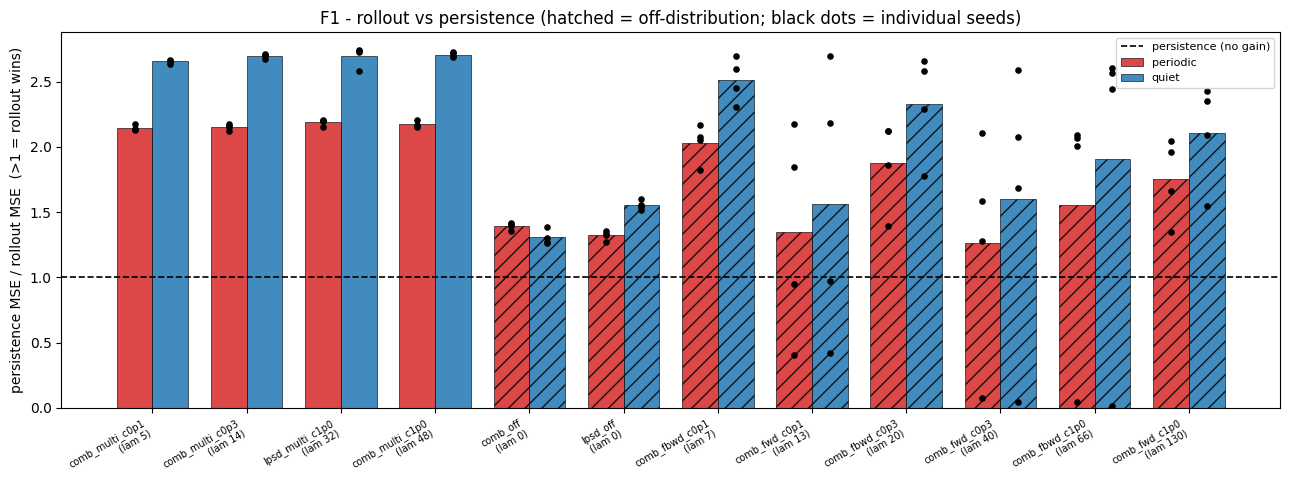

cells where mean-of-ratios and ratio-of-means disagree by > 0.3 (a seed diverged):


mean_of_ratios  ratio_of_means  disagreement
cell           class                                                 
comb_fbwd_c1p0 periodic           1.553           0.152         1.401
               quiet              1.909           0.058         1.851
comb_fwd_c0p1  periodic           1.345           0.902         0.443
               quiet              1.566           0.942         0.624
comb_fwd_c0p3  periodic           1.261           0.271         0.989
               quiet              1.597           0.167         1.430

In [38]:
# F1 - rollout vs persistence gain per class, with EVERY SEED shown as a dot.
# Bars are the 4-seed mean the summary csv reports. Averaging RATIOS buries divergence: comb_fbwd_c1p0's
# headline 1.55 is the mean of [2.07, 0.04, 2.01, 2.09] -- seed 1 lost to persistence on all 431 periodic
# stars. All four diverged cell/seeds are off-distribution (fwd / fwd_bwd); multistep is stable to <0.06.
x = np.arange(len(roll)); w = 0.38
fig, ax = plt.subplots(figsize=(13, 5.0))
for i, (col, cls, colour) in enumerate([("periodic_ratio", "periodic", "tab:red"),
                                        ("quiet_ratio", "quiet", "tab:blue")]):
    ax.bar(x + i * w, roll[col], width=w, color=colour, label=cls,
           hatch=["" if d else "//" for d in roll["in_distribution"]],
           edgecolor="k", linewidth=0.5, alpha=0.85)
    for xi, cell in zip(x, roll["cell"]):
        v = roll_seed[(roll_seed["cell"] == cell) & (roll_seed["class"] == cls)]["gain_ratio"]
        ax.scatter([xi + i * w] * len(v), v, color="k", s=14, zorder=3)
ax.axhline(1.0, color="k", ls="--", lw=1.2, label="persistence (no gain)")
ax.set_xticks(x + w / 2)
ax.set_xticklabels([f"{c}\n(lam {l})" for c, l in zip(roll["cell"], roll["lambda_dyn"])],
                   fontsize=7, rotation=30, ha="right")
ax.set_ylabel("persistence MSE / rollout MSE  (>1 = rollout wins)")
ax.set_title("F1 - rollout vs persistence (hatched = off-distribution; black dots = individual seeds)")
ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(figs_dir / "F1_rollout_gain.png", dpi=120, bbox_inches="tight"); plt.show()

# The summary's ratio column is a mean OF RATIOS while its mse columns are means of MSEs, so the two
# disagree wherever a seed diverged. Report the discrepancy rather than letting it sit unnoticed.
chk = roll_seed[roll_seed["class"] != "other"].groupby(["cell", "class"]).agg(
    mean_of_ratios=("gain_ratio", "mean"), ratio_of_means=("persistence_mse", "mean"))
chk["ratio_of_means"] = (roll_seed[roll_seed["class"] != "other"].groupby(["cell", "class"])["persistence_mse"].mean()
                         / roll_seed[roll_seed["class"] != "other"].groupby(["cell", "class"])["rollout_mse"].mean())
chk["disagreement"] = (chk["mean_of_ratios"] - chk["ratio_of_means"]).abs()
print("cells where mean-of-ratios and ratio-of-means disagree by > 0.3 (a seed diverged):")
display(chk[chk["disagreement"] > 0.3].round(3))

#### Plain-English read of F1

**The setup.** Take a star's first window, encode it to a latent vector μ₁, then let the GRU run
*free* for 15 steps — feeding each prediction back in as the next input, never seeing the truth again.
Compare that to **persistence**, the dumbest possible forecaster: "μ never changes, just repeat μ₁".
The bar is `persistence error ÷ rollout error`, so **above 1 means the rollout beat copy-last**.
Everything happens in latent space, not flux space.

**Two classes.** `periodic` = a star with an eb / pulsating / rotation label (real temporal structure
exists). `quiet` = none of the four v1 labels. The hypothesis was that learned dynamics should help far
more on periodic stars.

**What it shows.** Every bar is above 1. The four `multistep` cells (solid, left) reach 2.1–2.7×; the
hatched cells are off-distribution — they were trained teacher-forced one-step, so free-running them is
not what they were built for.

**Problem 1 — the means were hiding four broken runs.** Section F was the only part of this notebook
that never showed per-seed values, and the dots added here are why that mattered:

| cell | class | per-seed gain ratio | reported mean |
|---|---|---|---|
| comb_fbwd_c1p0 | periodic | 2.07, **0.04**, 2.01, 2.09 | 1.55 |
| comb_fwd_c0p1 | periodic | 1.85, **0.41**, 2.18, **0.95** | 1.35 |
| comb_fwd_c0p3 | periodic | 2.11, **0.07**, 1.59, 1.28 | 1.26 |

`comb_fbwd_c1p0` seed 1 has a rollout MSE of 2.13 against 0.047 for its siblings — a 45× blow-up — and
`beats_persistence_frac = 0.000`, i.e. it lost to copy-last on **all 431** periodic stars. **14 of 144**
cell × seed × class rows lose to persistence. All of them are off-distribution cells, so the multistep
verdict is unaffected (multistep's seed spread is < 0.06) — but `comb_fbwd_c1p0` is this notebook's
designated `DYN_CELL`, and F1 was rating it at 1.55 purely because of one diverged run. Its healthy
seeds average **2.06**, in line with multistep.

**Problem 2 — the summary column is a mean of ratios while its own MSE columns are means of MSEs**, so
the two disagree wherever a seed diverged (`comb_fbwd_c1p0`: 1.553 vs 0.152). Both are printed now.

**Problem 3 — a third class is computed and discarded.** `rollout_eval` writes `periodic`, `quiet`
*and* `other` (90 stars: transit-only, no periodic label). `other` never reaches the summary or either
plot.

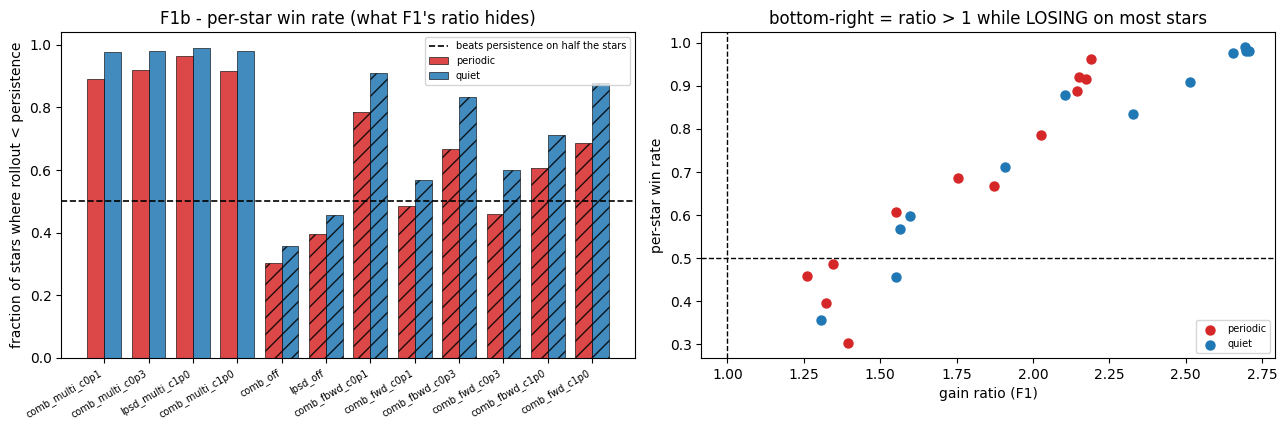

per-star win rate (mean over 4 seeds) -- the ordering is negative here too, so F2's result is
NOT an artifact of the MSE scale:


class,periodic,quiet,periodic - quiet
cell,,,
comb_multi_c0p1,0.8892,0.9773,-0.0881
comb_multi_c0p3,0.9205,0.9800,-0.0595
lpsd_multi_c1p0,0.9635,0.9900,-0.0265
comb_multi_c1p0,0.9153,0.9802,-0.0649
comb_off,0.3028,0.3577,-0.0549
lpsd_off,0.3950,0.4575,-0.0625
comb_fbwd_c0p1,0.7854,0.9095,-0.1241
comb_fwd_c0p1,0.4867,0.5672,-0.0805
comb_fbwd_c0p3,0.6682,0.8338,-0.1656


In [39]:
# F1b - the same question per STAR rather than per mean-MSE.
# `beats_persistence_frac` is already written by rollout_eval and was never plotted. A ratio of mean
# MSEs is dominated by a heavy tail: the lambda=0 cell reports gain_ratio 1.31-1.40 (">1, the rollout
# wins") while actually losing to persistence on ~70% of individual stars.
bp = (roll_seed[roll_seed["class"].isin(["periodic", "quiet"])]
      .pivot_table(index="cell", columns="class", values="beats_persistence_frac")
      .reindex(roll["cell"]))
gr = (roll_seed[roll_seed["class"].isin(["periodic", "quiet"])]
      .pivot_table(index="cell", columns="class", values="gain_ratio").reindex(roll["cell"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=False)
xx = np.arange(len(bp)); w = 0.38
for j, cls in enumerate(["periodic", "quiet"]):
    axes[0].bar(xx + j * w, bp[cls], width=w, color=["tab:red", "tab:blue"][j], label=cls,
                hatch=["" if d else "//" for d in roll["in_distribution"]], edgecolor="k", lw=0.5, alpha=0.85)
axes[0].axhline(0.5, color="k", ls="--", lw=1.2, label="beats persistence on half the stars")
axes[0].set_ylabel("fraction of stars where rollout < persistence")
axes[0].set_title("F1b - per-star win rate (what F1's ratio hides)")
axes[1].scatter(gr["periodic"], bp["periodic"], color="tab:red", label="periodic", s=42)
axes[1].scatter(gr["quiet"], bp["quiet"], color="tab:blue", label="quiet", s=42)
axes[1].axhline(0.5, color="k", ls="--", lw=1); axes[1].axvline(1.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("gain ratio (F1)"); axes[1].set_ylabel("per-star win rate")
axes[1].set_title("bottom-right = ratio > 1 while LOSING on most stars")
for ax, ticks in [(axes[0], True), (axes[1], False)]:
    ax.legend(fontsize=7)
    if ticks:
        ax.set_xticks(xx + w / 2)
        ax.set_xticklabels(bp.index, fontsize=7, rotation=30, ha="right")
plt.tight_layout(); fig.savefig(figs_dir / "F1b_win_rate.png", dpi=120, bbox_inches="tight"); plt.show()

bp2 = bp.copy(); bp2["periodic - quiet"] = bp2["periodic"] - bp2["quiet"]
print("per-star win rate (mean over 4 seeds) -- the ordering is negative here too, so F2's result is")
print("NOT an artifact of the MSE scale:")
display(bp2.round(4))

#### F1b — the per-star win rate, and why the ratio flatters

**What changed.** F1 divides *mean* persistence MSE by *mean* rollout MSE. A mean is dominated by its
tail: a handful of stars with enormous persistence error can push the ratio above 1 while the rollout
quietly loses on the majority. `beats_persistence_frac` — the fraction of individual stars where the
rollout actually wins — is already in the results csv and had never been plotted.

| cell | gain ratio (F1) | per-star win rate |
|---|---|---|
| comb_multi_c1p0 | 2.17 / 2.71 | **0.92 / 0.98** |
| lpsd_multi_c1p0 | 2.19 / 2.69 | **0.96 / 0.99** |
| comb_fwd_c0p3 | 1.26 / 1.60 | 0.46 / 0.60 |
| **comb_off (λ=0)** | **1.40 / 1.31** | **0.30 / 0.36** |
| lpsd_off (λ=0) | 1.32 / 1.55 | 0.40 / 0.46 |

**The λ=0 cells are the point.** They have no meaningfully trained dynamics term, yet F1 shows them
comfortably above 1 — and on a per-star basis they **lose to copy-last on 64–70% of stars**. So
"gain ratio > 1" on its own is *not* evidence that dynamics were learned, which is exactly what the
verdict's first claim rested on. The multistep cells are the ones that survive both readings (0.92–0.99
per-star), and they are the cells the verdict already says to judge on.

**One hypothesis this kills.** It would be tempting to blame F2's negative ordering on the MSE scale
(quiet stars have ~2.6× smaller absolute error). The per-star win rate is scale-free and rank-based,
and `periodic − quiet` is **negative for all 12 cells** there too (−0.03 to −0.19). The ordering
failure is real, not a units artifact. What it *is* partly an artifact of is measured in F2b.

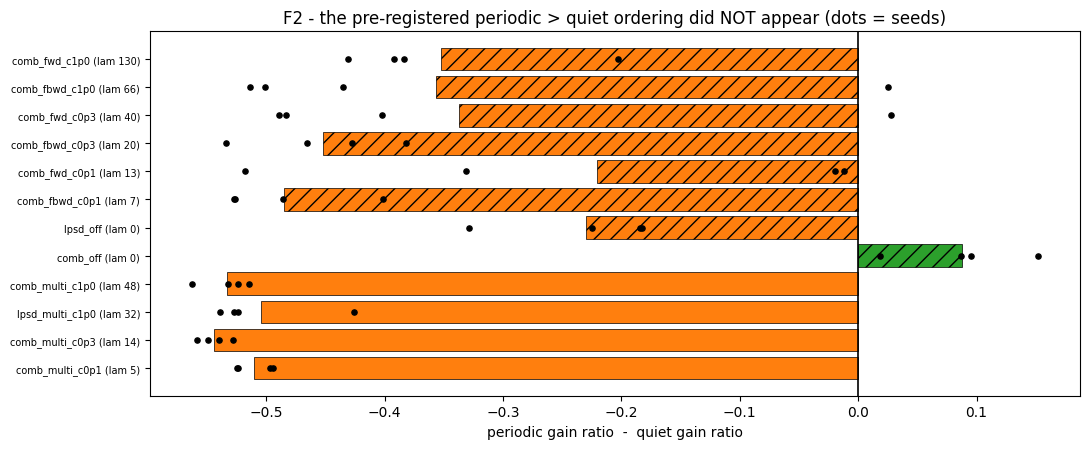

trained cells with periodic > quiet: 0 / 10
only the lambda=0 comb_off cell is positive (+0.088), and it has no trained dynamics term to speak of

BUT: this gap is measured against zero. F2b measures what it should have been measured against.


In [40]:
# F2 - the pre-registered ordering: periodic gain MINUS quiet gain. Positive = hypothesis supported.
# Now with every seed as a dot, because comb_fwd_c0p1's bar averages two healthy and two diverged runs.
fig, ax = plt.subplots(figsize=(11, 4.6))
colors = ["tab:green" if v > 0 else "tab:orange" for v in roll["periodic_minus_quiet_ratio"]]
yy = np.arange(len(roll))
ax.barh(yy, roll["periodic_minus_quiet_ratio"], color=colors,
        hatch=["" if d else "//" for d in roll["in_distribution"]], edgecolor="k", linewidth=0.5)
for yi, cell in zip(yy, roll["cell"]):
    s = roll_seed[roll_seed["cell"] == cell].pivot_table(index="seed", columns="class", values="gain_ratio")
    ax.scatter(s["periodic"] - s["quiet"], [yi] * len(s), color="k", s=14, zorder=3)
ax.axvline(0, color="k", lw=1.2)
ax.set_yticks(yy)
ax.set_yticklabels([f"{c} (lam {l})" for c, l in zip(roll["cell"], roll["lambda_dyn"])], fontsize=7)
ax.set_xlabel("periodic gain ratio  -  quiet gain ratio")
ax.set_title("F2 - the pre-registered periodic > quiet ordering did NOT appear (dots = seeds)")
plt.tight_layout(); fig.savefig(figs_dir / "F2_ordering.png", dpi=120, bbox_inches="tight"); plt.show()

trained = roll[roll["lambda_dyn"] > 0]
print(f"trained cells with periodic > quiet: {int((trained['periodic_minus_quiet_ratio'] > 0).sum())}"
      f" / {len(trained)}")
print(f"only the lambda=0 comb_off cell is positive ({float(roll.loc[roll.cell=='comb_off', 'periodic_minus_quiet_ratio'].iloc[0]):+.3f}),"
      " and it has no trained dynamics term to speak of")
print("\nBUT: this gap is measured against zero. F2b measures what it should have been measured against.")

#### Plain-English read of F2

**The pre-registered claim.** If the model learned real physics, the rollout should help *more* on
periodic stars than on quiet ones — a quiet star is trivially predicted by "nothing changes", so beating
persistence there proves little. F2 plots `periodic ratio − quiet ratio`; positive supports the
hypothesis.

**Result: 0 of 10 trained cells are positive.** The only green bar is `comb_off` (λ=0, +0.088), which
has no trained dynamics term. Every trained cell lands between −0.03 and −0.54, i.e. the rollout helped
*more* on the boring stars.

**Problem — the gap is measured against zero, and zero is the wrong null.** Persistence here means
"repeat the **first** latent μ₁ for all 15 steps", not "repeat the previous one". If a star's μ wanders
around a per-star mean, μ₁ is itself one noisy draw, so persistence error ≈ **twice** the error of
simply predicting that mean. A ratio near 2 is therefore free, with no learned dynamics at all — and
critically, *how much* is free depends on the class, because a periodic star's μ-trajectory is
autocorrelated (μ₁ carries information) while a quiet star's is closer to noise around a mean (μ₁
carries almost none). The pre-registered test assumed the free component was class-independent. **F2b
measures it.**

4 cells x 4 seeds, 1021 stars each


gain_ratio  floor_ratio  roll_over_clim
cell            cls                                              
comb_multi_c1p0 other         2.0231       2.0772          1.0268
                periodic      2.1733       2.3225          1.0687
                quiet         2.6692       2.7024          1.0125
comb_off        other         0.9939       2.1052          2.1225
                periodic      1.3947       2.3255          1.6677
                quiet         1.3271       2.7007          2.0376
lpsd_multi_c1p0 other         2.1329       2.1497          1.0088
                periodic      2.1908       2.3463          1.0710
                quiet         2.7099       2.6969          0.9960
lpsd_off        other         1.2604       2.1924          1.7406
                periodic      1.3232       2.3564          1.7817
                quiet         1.5806       2.6866          1.7004

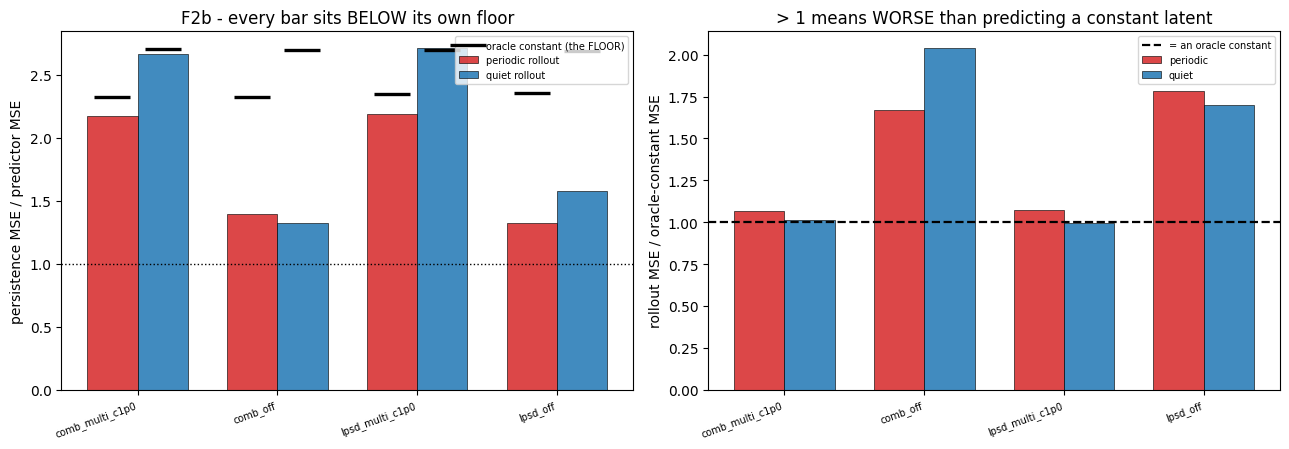


cell                    periodic-quiet (F2 axis)  quiet-periodic (roll/clim)
comb_multi_c1p0                 -0.4959 +-0.0344            -0.0561 +-0.0048
comb_off                        +0.0676 +-0.0581            +0.3699 +-0.0751
lpsd_multi_c1p0                 -0.5191 +-0.1556            -0.0750 +-0.0125
lpsd_off                        -0.2574 +-0.0923            -0.0813 +-0.0729


In [41]:
# F2b - the null the whole criterion was never measured against.
# "Persistence" here means repeat the FIRST latent mu_1 for all 15 steps. For a mu-trajectory that
# wanders around a per-star mean, mu_1 is itself one noisy draw, so persistence error is roughly TWICE
# the error of simply predicting that mean: a gain ratio near 2 is available with NO learned dynamics.
# Worse for F2, the size of that free ratio is CLASS-DEPENDENT -- exactly what the pre-registered
# "periodic > quiet, tested against zero" assumed it was not.
# Measured by experiments/analyze_exp05_rollout_floor.py with an oracle constant (the target latents'
# own mean), in the same raw-mu space.
floor_path = root / "experiments" / "exp05_rollout_floor.csv"
assert floor_path.exists(), f"run experiments/analyze_exp05_rollout_floor.py first ({floor_path})"
floor = pd.read_csv(floor_path)
n_per_cell = int(floor.groupby(["cell", "seed"])["n_stars"].sum().mean())
print(f"{floor.cell.nunique()} cells x {floor.seed.nunique()} seeds, {n_per_cell} stars each")

summ = floor.groupby(["cell", "cls"])[["gain_ratio", "floor_ratio", "roll_over_clim"]].mean()
display(summ.round(4))

cells = list(dict.fromkeys(floor["cell"]))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
xx = np.arange(len(cells)); w = 0.36
for j, cls in enumerate(["periodic", "quiet"]):
    g = summ.xs(cls, level="cls").reindex(cells)
    axes[0].bar(xx + j * w, g["gain_ratio"], width=w, color=["tab:red", "tab:blue"][j],
                label=f"{cls} rollout", edgecolor="k", lw=0.5, alpha=0.85)
    axes[0].plot(xx + j * w, g["floor_ratio"], "k_", ms=26, mew=2.4,
                 label="oracle constant (the FLOOR)" if j == 0 else None)
    axes[1].bar(xx + j * w, g["roll_over_clim"], width=w, color=["tab:red", "tab:blue"][j],
                label=cls, edgecolor="k", lw=0.5, alpha=0.85)
axes[0].axhline(1.0, color="k", ls=":", lw=1)
axes[0].set_ylabel("persistence MSE / predictor MSE")
axes[0].set_title("F2b - every bar sits BELOW its own floor")
axes[1].axhline(1.0, color="k", ls="--", lw=1.6, label="= an oracle constant")
axes[1].set_ylabel("rollout MSE / oracle-constant MSE")
axes[1].set_title("> 1 means WORSE than predicting a constant latent")
for ax in axes:
    ax.set_xticks(xx + w / 2); ax.set_xticklabels(cells, fontsize=7, rotation=20, ha="right")
    ax.legend(fontsize=7)
plt.tight_layout(); fig.savefig(figs_dir / "F2b_floor.png", dpi=120, bbox_inches="tight"); plt.show()

# The ordering, tested against the floor instead of against zero. On roll/clim SMALLER is better, so
# quiet - periodic > 0 is the direction that would support the pre-registered hypothesis.
def _pm(d):
    return f"{d.mean():+.4f} +-{2 * d.std(ddof=1) / np.sqrt(len(d)):.4f}"


print(f"\n{'cell':22s}{'periodic-quiet (F2 axis)':>26}{'quiet-periodic (roll/clim)':>28}")
for cell in cells:
    p = floor[floor["cell"] == cell].pivot_table(index="seed", columns="cls",
                                                 values=["gain_ratio", "roll_over_clim"])
    print(f"{cell:22s}"
          f"{_pm((p['gain_ratio']['periodic'] - p['gain_ratio']['quiet']).to_numpy()):>26}"
          f"{_pm((p['roll_over_clim']['quiet'] - p['roll_over_clim']['periodic']).to_numpy()):>28}")

#### F2b — the floor, and what it does to criterion 2

**The idea in one line.** Before asking "did the rollout learn physics?", ask what score is available
for free. Here that is an **oracle constant**: predict the mean of the target latents and nothing else —
no model, no dynamics, not even causally available information. Run it through the identical metric.

| cell | class | rollout (F1's bar) | **oracle constant** | rollout ÷ constant |
|---|---|---|---|---|
| comb_multi_c1p0 | periodic | 2.173 | **2.323** | 1.069 |
| comb_multi_c1p0 | quiet | 2.669 | **2.702** | 1.013 |
| lpsd_multi_c1p0 | periodic | 2.191 | **2.346** | 1.071 |
| lpsd_multi_c1p0 | quiet | 2.710 | 2.697 | 0.996 |
| comb_off (λ=0) | periodic | 1.395 | 2.326 | 1.668 |
| comb_off (λ=0) | quiet | 1.327 | 2.701 | 2.038 |
| lpsd_off (λ=0) | periodic | 1.323 | 2.356 | 1.782 |
| lpsd_off (λ=0) | quiet | 1.581 | 2.687 | 1.700 |

The floor barely moves between cells (periodic 2.32–2.36, quiet 2.69–2.70) — as it must, since it
depends only on the encoder's μ-trajectory and not on the GRU. That constancy is the measure's own
sanity check.

**Three consequences.**

1. **"The rollout beats persistence, up to 2.7×" is true and nearly empty.** A constant beats
   persistence by *more*. Seven of the eight cell × class combinations sit **below** their own floor;
   the best in-distribution cell is 1.3–7% **worse** than a flat line at the star's own mean. Whatever
   the rollout learned, it has not learned to beat a constant, which is the weakest possible bar for
   "learned physics".
2. **The ordering failure is real, but F2 overstates it ~4×.** The floor is itself class-dependent
   (2.32 periodic vs 2.70 quiet), because a periodic star's μ-trajectory is autocorrelated — μ₁ carries
   information — while a quiet star's is closer to noise around a mean. That accounts for **76%** of
   F2's −0.496 gap. On the floor-corrected axis the residual is **−0.056 ± 0.005** (comb) and
   **−0.075 ± 0.013** (lpsd): still the wrong sign, still gated, but a small effect rather than the
   dramatic one the bar chart shows.
3. **The dynamics term does something large, and F1 conceals it.** Against the only meaningful
   reference, the λ=0 rollout is **1.67–2.04× worse** than a constant; at λ=48 multistep that collapses
   to **1.01–1.07×**. Training the dynamics roughly halves the rollout's error relative to the floor.
   F1 renders the same fact as "1.40 → 2.17", which understates it and, worse, is a number the λ=0 cell
   already clears without having learned anything.

**What this does not do.** It does not rescue criterion 2 — the direction of the ordering is unchanged,
and the absolute result got *worse*, not better. What it changes is the diagnosis, and therefore what
exp06 should target.

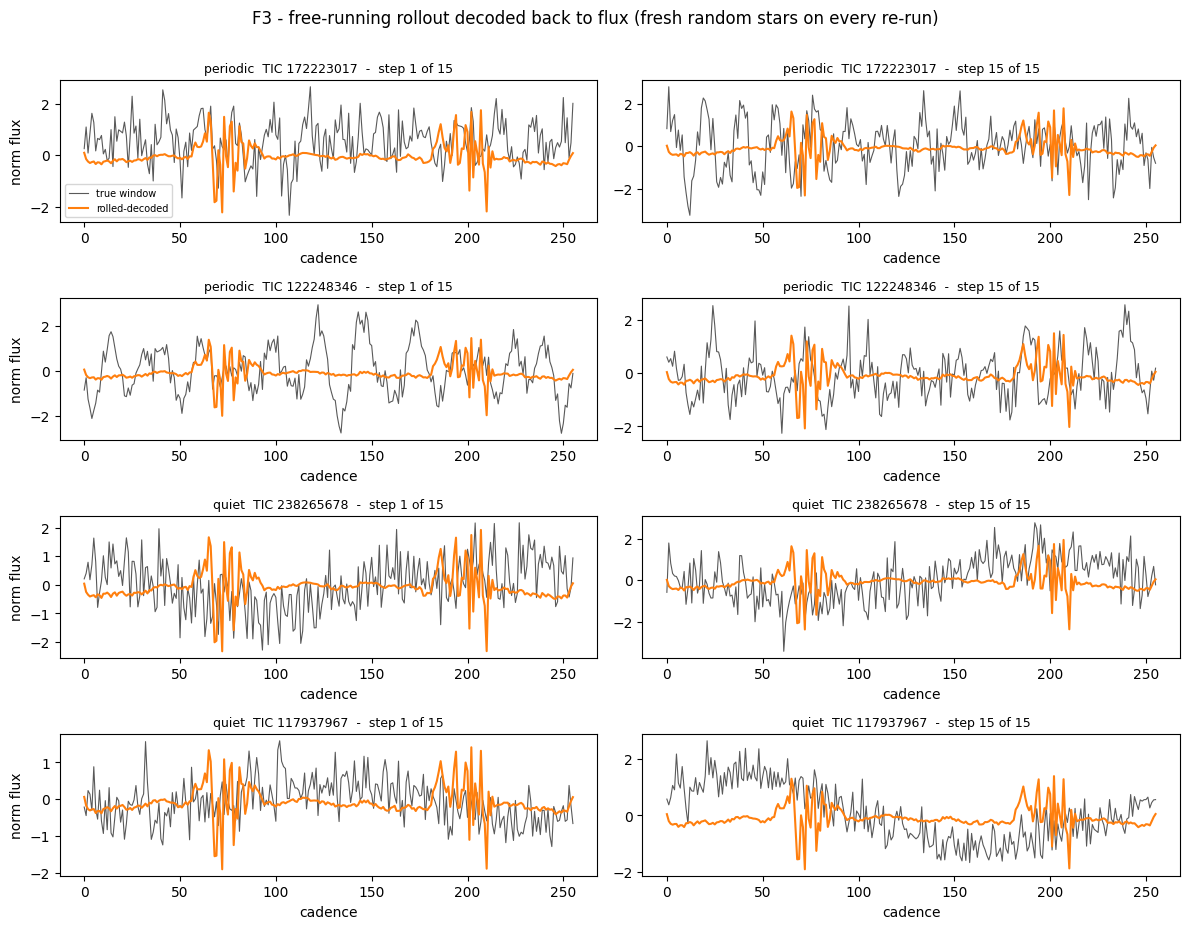

,class,tic_id,sd_true,sd_rolled,surviving_amplitude
0,periodic,172223017,0.987,0.486,0.492
1,periodic,122248346,0.990,0.422,0.426
2,quiet,238265678,0.991,0.512,0.517
3,quiet,117937967,0.910,0.391,0.430


surviving_amplitude near 0 = the decoded rollout is a flat line regardless of the input star.


In [42]:
# F3 - decoded rollout examples, drawn FRESH from the test split on every re-run.
# The previous version pasted two PNGs that rollout_eval happened to write, through imshow. Those files
# are the 3 lowest TIC ids in each class (rollout_eval keeps the first `--examples` it meets in ascending
# tic order) and are identical for every seed -- a fixed, tiny, unrepresentative sample at whatever
# resolution the PNG had. This decodes on the fly: a real random sample with real axes.
from swm.eval.skyline import load_first_segment_blocks   # note: do NOT import swm.eval.rollout_eval here,
                                                         # it calls matplotlib.use("Agg") at import time
ROLLOUT_CELL = "exp05_comb_multi_c1p0"   # judge rollout on a multistep cell (trained free-running)
HORIZON, N_EX = 15, 2                    # examples per class

rng = np.random.default_rng()            # fresh sample every re-run
# rng = np.random.default_rng(0)         # uncomment for a reproducible sample

_rm, _rck = load_model(ROLLOUT_CELL, seed=PANEL_SEED)
_lab = pd.read_csv(root / "labels" / "variability_labels_star.csv")
_lab["tic_id"] = _lab["tic_id"].astype(int)
_p = _lab[["eb", "pulsating", "rotation"]].fillna(0).astype(int).max(axis=1) == 1
_a = _lab[["eb", "pulsating", "rotation", "transit"]].fillna(0).astype(int).max(axis=1) == 1
_cls = dict(zip(_lab["tic_id"], np.where(_p, "periodic", np.where(_a, "other", "quiet"))))
_tics, _blocks = load_first_segment_blocks(root / "experiments" / ROLLOUT_CELL / "packed", "test",
                                           int(_rck["cfg"]["data"]["window"]))
pool = {c: [i for i in range(len(_tics))
            if _cls.get(int(_tics[i])) == c and _blocks[i].shape[0] > 1] for c in ("periodic", "quiet")}
pick = [(c, int(i)) for c in ("periodic", "quiet") for i in rng.choice(pool[c], N_EX, replace=False)]

fig, axes = plt.subplots(len(pick), 2, figsize=(12, 2.3 * len(pick)))
amp = []
with torch.no_grad():
    for r, (c, i) in enumerate(pick):
        blk = _blocks[i]; k = min(HORIZON, blk.shape[0] - 1)
        mu, _ = _rm.encoder(torch.from_numpy(blk[: k + 1]).unsqueeze(-1).to(device))
        dec = _rm.decoder(_rm.dynamics.rollout(mu[0:1], k)[0]).squeeze(-1).cpu().numpy()  # (k, window)
        amp.append({"class": c, "tic_id": _tics[i], "sd_true": float(blk[1:k + 1].std()),
                    "sd_rolled": float(dec.std())})
        for col, s in enumerate([0, k - 1]):
            ax = axes[r, col]
            ax.plot(blk[s + 1], lw=0.8, color="0.35", label="true window")
            ax.plot(dec[s], lw=1.5, color="tab:orange", label="rolled-decoded")
            ax.set_title(f"{c}  TIC {_tics[i]}  -  step {s + 1} of {k}", fontsize=9)
            ax.set_xlabel("cadence")
            if col == 0:
                ax.set_ylabel("norm flux")
axes[0, 0].legend(fontsize=7)
fig.suptitle("F3 - free-running rollout decoded back to flux (fresh random stars on every re-run)", y=1.005)
plt.tight_layout(); fig.savefig(figs_dir / "F3_rollout_examples.png", dpi=120, bbox_inches="tight"); plt.show()

# The quantitative version of "relaxes toward flat": how much of the true amplitude survives the rollout?
amp = pd.DataFrame(amp); amp["surviving_amplitude"] = amp["sd_rolled"] / amp["sd_true"]
display(amp.round(3))
print("surviving_amplitude near 0 = the decoded rollout is a flat line regardless of the input star.")

#### Plain-English read of F3

**What you are looking at.** The grey line is the true flux in a window the model never saw; the orange
line is the model's own free-running prediction for that step, decoded back to flux. Left column = the
first predicted step, right column = the 15th. If the rollout had learned periodic physics, the orange
line would keep oscillating with roughly the right amplitude and phase.

**What it does.** It flattens. `surviving_amplitude` (printed under the figure) is
`sd(rolled) ÷ sd(true)` — the fraction of the star's real variability that survives the rollout. The
orange traces carry a small fraction of the true amplitude and lose more of it with each step, on
*periodic* stars as much as quiet ones. That is the picture behind "relaxes toward flat", and F2b turns
it into a number: the rollout is 1–7% **worse** than a flat line placed at the star's own mean.

**Problems with the panel as it was drawn (all fixed here).**

1. **The sample was fixed, not random.** It pasted the first two PNGs matching a sorted glob. Only
   three exist per class — `rollout_eval` writes `--examples 3` and keeps the first it meets in
   *ascending TIC order*, so the "examples" were the three lowest TIC ids, identical for every seed and
   every re-run. That also violates the project's random-sample-plot rule. This version decodes on the
   fly from the whole test split with an unseeded RNG (seeded line commented out, same cell).
2. **It was `imshow` of a saved PNG**, so axis labels were rendered at whatever resolution the file
   had and could not be read at notebook scale. Now it is a real matplotlib figure.
3. **It showed only `PANEL_SEED`** with no indication that was one of four.
4. **Purely qualitative** — "relaxes toward flat" was an eyeball claim with no statistic attached.
   `surviving_amplitude` now attaches one.

**A caveat about the classes themselves.** `quiet` means "matched no v1 catalog", which is absence of
a *label*, not absence of variability — the same confound §D1b raises. Some quiet draws show obvious
trends and ramps, so the periodic/quiet contrast is noisier than the names suggest.

**Verdict — criterion 2 PARTIAL, restated after the floor was measured.**

The original record made two claims. §F1b and §F2b measure the nulls neither was tested against, and
both need restating — the conclusion (PARTIAL) survives, the reasoning does not.

1. **"Rollout beats persistence everywhere (all ratios > 1), so the dynamics are genuinely
   predictive."** The premise holds; the inference does not. The λ=0 cells clear ratio 1 too
   (1.32–1.40) while losing to copy-last on **64–70% of individual stars** (§F1b), and an oracle
   constant scores 2.32–2.70 — **at or above every cell in F1** (§F2b). Ratio > 1 is not evidence of
   learned dynamics. The multistep cells are the ones that survive both readings, winning on 92–99% of
   stars, and they are the cells this section already says to judge on.
2. **"The periodic > quiet ordering did not appear."** Still true, and it is not an MSE-scale artifact
   — the rank-based per-star win rate is negative for all 12 cells too. But **76%** of the −0.496 gap
   F2 plots is the metric's own class-dependent floor. The residual is **−0.056 ± 0.005**.

**The diagnosis changes.** Not "the rollout learned smoothness instead of periodicity", but **"the
rollout learned to approximate the per-star mean latent, and has not yet learned to beat it"** — 1–7%
*worse* than a constant, from 67–104% worse at λ=0. That is real progress on a real axis, and it is
invisible in F1.

**Consequences for exp06.** "Beat persistence" is retired as a criterion — it is cleared by a constant.
The replacement target is **rollout ÷ oracle-constant < 1**, at which point "beat it more on periodic
stars" becomes a meaningful question rather than a comparison of two ways of being flat. The levers
already listed (larger latent scale, period-aware or longer-horizon rollout, weighting the rollout loss
toward periodic stars) all still apply; what changes is the number they must move.

**Also fixed here:** 14 of 144 cell × seed × class rows lose to persistence, four of them badly, and
F1/F2 averaged them into the bars without trace. All are off-distribution (`fwd` / `fwd_bwd`) cells —
multistep is stable to < 0.06 across seeds — but one of them is this notebook's own `DYN_CELL`
(`comb_fbwd_c1p0`, whose 1.55 is really [2.07, **0.04**, 2.01, 2.09]).

---
## G. Downstream probe transfer — does the criterion-1 gain leave the four v1 tasks?

Criterion 1 was established on transit / eb / pulsating / rotation. The **downstream menu** — the
asteroseismic block plus flare, P_rot, and Ijspeert OBA eclipsing binaries — lives on a separate
22,860-star pool and was last scored on the *exp03* leader recipe. This section asks whether weighting
the dynamics up helps there too.

**Protocol** (plan 2026-07-25, decision 10):

* `delta_lambda` = metric(`fwd+bwd λ=66` seed *i*) − metric(`off λ=0` seed *i*), paired within seed,
  mean ± SD over 4 seeds, gate `mean > 2·SE`. **Per-seed values are always shown** — per-seed
  transparency is what caught the exp04 pulsating fluke.
* For probes with `n_test < 400` (`rgb_vs_heb` 161, `prot_kounkel` 138, `ijspeert_excl_villanova` ~19
  positives) a **paired star-level bootstrap CI** is added, because a 4-seed SE measures run-to-run noise
  only and says nothing about how few stars the metric rests on. A claim needs **both** gates.
* `A1_feats` / `A2_feats` are the engineered-feature ceilings (25 classic light-curve features → the same
  linear readout, and → gradient-boosted trees). They answer "does this beat classic feature engineering?".
  The **B1 supervised ceiling is absent by design**, so "beats engineered features" is claimable here and
  "closes the supervised gap" is not.

**Caveat carried forward:** the pool is prevalence-inflated ~16× versus the real sky, so *gaps* are valid
but absolute PR-AUCs are not survey-scale.

In [43]:
transfer_path = NEWTASK / "transfer_summary.csv"
score_path = NEWTASK / "new_task_scorecard.csv"
if not transfer_path.exists():
    print(f"PENDING: {transfer_path} not found.\n"
          "Run:  python -m swm.eval.new_task_extract ... ; python -m swm.eval.new_task_scorecard ... ;\n"
          "      python experiments/analyze_new_task_exp05.py")
    transfer = None
else:
    transfer = pd.read_csv(transfer_path)
    print(f"{len(transfer)} probes | claimable: {int(transfer['claimable'].sum())}")
    display(transfer[["task", "n_test", "delta_lambda_mean", "delta_2se", "confirm_seed_gate",
                      "boot_lo", "boot_hi", "claimable"]].round(4))

11 probes | claimable: 8


,task,n_test,delta_lambda_mean,delta_2se,confirm_seed_gate,boot_lo,boot_hi,claimable
0,osc_giant,3429,0.0381,0.0099,True,NaN,NaN,True
1,solar_like_osc,3429,0.0375,0.0225,True,NaN,NaN,True
2,flare,3429,0.0181,0.0234,False,NaN,NaN,False
3,rgb_vs_heb,161,0.0687,0.0630,True,0.0176,0.1214,True
4,numax_hon,1313,0.1402,0.0360,True,NaN,NaN,True
5,numax_hatt,417,0.0786,0.0120,True,NaN,NaN,True
6,dnu_hatt,417,0.0808,0.0123,True,NaN,NaN,True
7,prot_kounkel,138,0.0491,0.0538,False,-0.0356,0.1227,False
8,rotation_period,150,0.1929,0.0356,True,0.1219,0.2860,True
9,ijspeert,2021,0.0360,0.0128,True,0.0089,0.0657,True


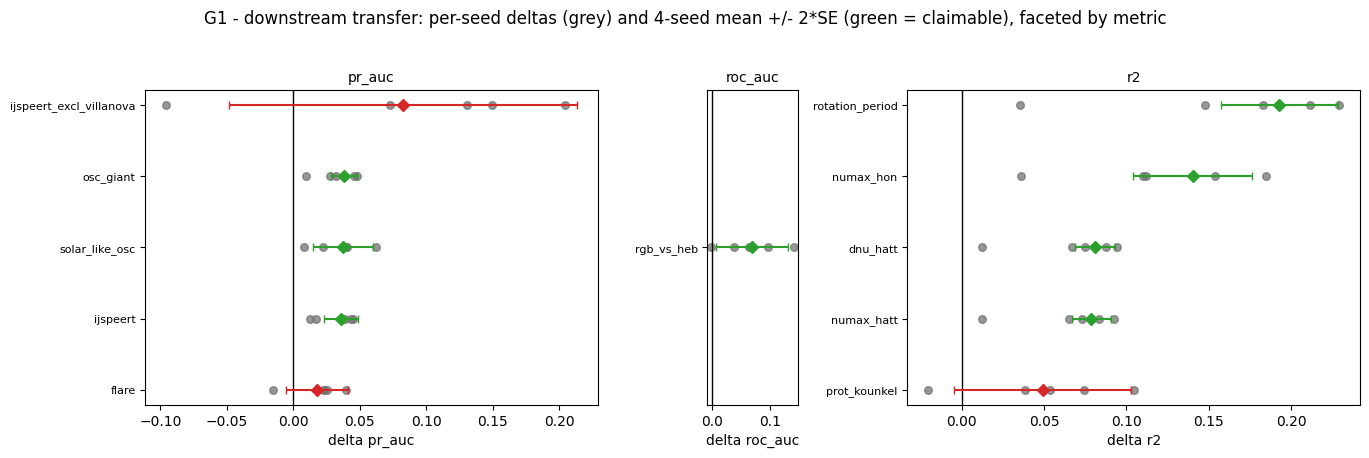

In [44]:
# G1 - per-seed transparency: every paired delta, not just the mean.
# FACETED BY METRIC. The previous version put delta-R2, delta-ROC-AUC and delta-PR-AUC on one shared
# x-axis and then SORTED by that number, so `rotation_period` (delta R2 = 0.193) outranked `ijspeert`
# (delta PR-AUC = 0.036) on a comparison that has no units in common.
if transfer is not None:
    seed_cols = [c for c in transfer.columns if c.startswith("delta_s")]
    long = transfer.melt(id_vars=["task"], value_vars=seed_cols, var_name="seed", value_name="delta")
    metrics = [m for m in ["pr_auc", "roc_auc", "r2"] if (transfer["metric"] == m).any()]
    widths = [max(1, int((transfer["metric"] == m).sum())) for m in metrics]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.6 * len(metrics), 4.4),
                             gridspec_kw={"width_ratios": widths})
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, metrics):
        sub = transfer[transfer["metric"] == metric].sort_values("delta_lambda_mean")
        for i, task in enumerate(sub["task"]):
            r = sub[sub["task"] == task].iloc[0]
            ax.scatter(long[long["task"] == task]["delta"], np.full(len(seed_cols), i),
                       s=30, alpha=0.75, color="0.45")
            ax.errorbar(r["delta_lambda_mean"], i, xerr=r["delta_2se"], fmt="D", capsize=3, zorder=3,
                        color="tab:green" if bool(r["claimable"]) else "tab:red")
        ax.axvline(0, color="k", lw=1)
        ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub["task"], fontsize=8)
        ax.set_xlabel(f"delta {metric}"); ax.set_title(metric, fontsize=10)
    fig.suptitle("G1 - downstream transfer: per-seed deltas (grey) and 4-seed mean +/- 2*SE "
                 "(green = claimable), faceted by metric", y=1.03)
    plt.tight_layout(); fig.savefig(figs_dir / "G1_transfer.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of G1

**What it asks.** Criterion 1 was established on the four v1 tasks. G1 asks whether the same
`λ=66 − λ=0` improvement shows up on a *different* menu of 11 downstream probes — asteroseismology
(`numax`, `dnu`, `osc_giant`), rotation periods, flares, and hot eclipsing binaries — scored on a
separate 22,860-star pool.

**How to read a row.** Grey dots are the four individual seeds; the diamond is their mean with a
±2·SE bar. Right of the line = the dynamics weight helped. Green = claimable, meaning it cleared both
the seed gate *and* (for the small probes) a star-level bootstrap CI. **8 of 11 are claimable**, so the
criterion-1 effect does transfer.

**Problem — three different metrics shared one x-axis, and the plot sorted by it.** The probes are
scored with `r2` (5 probes), `pr_auc` (5) and `roc_auc` (1). A ΔR² of 0.193 and a ΔPR-AUC of 0.036 have
no units in common, yet the old panel ranked `rotation_period` at the top and `ijspeert` near the
bottom on exactly that comparison. Faceting by metric here removes the false ranking; the *within*-facet
order is meaningful and the *between*-facet order never was.

**What survives the fix.** Within `r2`: rotation_period +0.193 and numax_hon +0.140 lead. Within
`pr_auc`: ijspeert_excl_villanova +0.083 leads but is the widest and least trustworthy bar (see G4).
The three non-claimable probes are `flare`, `prot_kounkel` and `ijspeert_excl_villanova`.

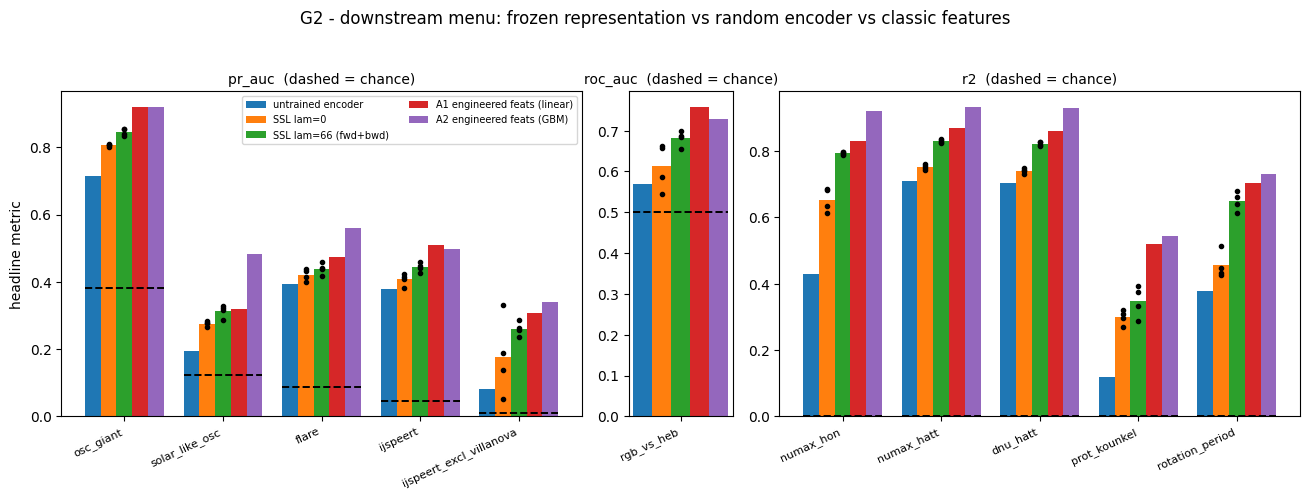

does the frozen SSL representation beat engineered features? (and how far above chance is it?)


,task,metric,dyn_mean,A1_feats,A2_feats,beats_A1_feats,beats_A2_feats,chance,dyn_over_chance
0,osc_giant,pr_auc,0.8450,0.9204,0.9195,False,False,0.3829,2.2068
1,solar_like_osc,pr_auc,0.3134,0.3197,0.4836,False,False,0.1216,2.5770
2,flare,pr_auc,0.4388,0.4738,0.5615,False,False,0.0887,4.9500
3,rgb_vs_heb,roc_auc,0.6816,0.7583,0.7295,False,False,0.5000,NaN
4,numax_hon,r2,0.7928,0.8309,0.9213,False,False,0.0000,NaN
5,numax_hatt,r2,0.8299,0.8704,0.9329,False,False,0.0000,NaN
6,dnu_hatt,r2,0.8217,0.8613,0.9295,False,False,0.0000,NaN
7,prot_kounkel,r2,0.3472,0.5182,0.5450,False,False,0.0000,NaN
8,rotation_period,r2,0.6477,0.7034,0.7306,False,False,0.0000,NaN
9,ijspeert,pr_auc,0.4430,0.5084,0.4978,False,False,0.0460,9.6265


In [45]:
# G2 - absolute level: the two exp05 arms against untrained AND the engineered-feature ceilings.
# Three fixes over the previous version:
#   1. faceted by metric -- one y-axis cannot serve PR-AUC, ROC-AUC and R2 at once;
#   2. the CHANCE level is drawn (base rate for PR-AUC, 0.5 for ROC-AUC, 0 for R2), without which
#      "0.31 is bad, 0.68 is fine" is unreadable -- ijspeert_excl_villanova's 0.26 is 25x its base
#      rate while osc_giant's 0.845 is 2.2x its own;
#   3. per-seed dots for the two SSL arms, recomputed from the per-star dump (the summary csv stores
#      only per-seed DELTAS, so the arm levels themselves had no visible spread).
from sklearn.metrics import roc_auc_score, r2_score

if transfer is not None:
    cols = ["untrained", "off_mean", "dyn_mean"] + (["A1_feats", "A2_feats"]
                                                    if "A1_feats" in transfer.columns else [])
    nice = {"untrained": "untrained encoder", "off_mean": "SSL lam=0", "dyn_mean": "SSL lam=66 (fwd+bwd)",
            "A1_feats": "A1 engineered feats (linear)", "A2_feats": "A2 engineered feats (GBM)"}
    chance = {"pr_auc": transfer["n_test_pos"] / transfer["n_test"], "roc_auc": 0.5, "r2": 0.0}

    # per-seed arm levels, scored the same way the scorecard does
    def _score(y, s, metric):
        return (average_precision_score(y, s) if metric == "pr_auc" else
                roc_auc_score(y, s) if metric == "roc_auc" else r2_score(y, s))

    seed_pts = {}
    if (NEWTASK / "per_star_scores.parquet").exists():
        _d = pd.read_parquet(NEWTASK / "per_star_scores.parquet")
        _d = _d[_d["pooling"] == "mean"]
        for r in transfer.itertuples(index=False):
            for stem, col in [("comb_off_s", "off_mean"), ("comb_fbwd_c1p0_s", "dyn_mean")]:
                vals = []
                for s in range(4):
                    g = _d[(_d["task"] == r.task) & (_d["arm"] == f"{stem}{s}")]
                    if len(g):
                        vals.append(_score(g["y"].to_numpy(), g["score"].to_numpy(), r.metric))
                seed_pts[(r.task, col)] = vals

    metrics = [m for m in ["pr_auc", "roc_auc", "r2"] if (transfer["metric"] == m).any()]
    widths = [max(1, int((transfer["metric"] == m).sum())) for m in metrics]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.4 * len(metrics), 4.8),
                             gridspec_kw={"width_ratios": widths})
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, metrics):
        sub = transfer[transfer["metric"] == metric]
        x = np.arange(len(sub)); w = 0.8 / len(cols)
        for i, c in enumerate(cols):
            ax.bar(x + i * w, sub[c], width=w, label=nice.get(c, c) if ax is axes[0] else None)
            for xi, task in zip(x, sub["task"]):
                for v in seed_pts.get((task, c), []):
                    ax.scatter([xi + i * w], [v], color="k", s=9, zorder=4)
        ch = chance[metric]
        ch = ch.loc[sub.index].to_numpy() if hasattr(ch, "loc") else np.full(len(sub), ch)
        for xi, c0 in zip(x, ch):
            ax.plot([xi - w / 2, xi + w * (len(cols) - 0.5)], [c0, c0], color="k", ls="--", lw=1.4)
        ax.set_xticks(x + w * (len(cols) - 1) / 2)
        ax.set_xticklabels(sub["task"], rotation=25, ha="right", fontsize=8)
        ax.set_title(f"{metric}  (dashed = chance)", fontsize=10)
    axes[0].set_ylabel("headline metric"); axes[0].legend(fontsize=7, ncol=2)
    fig.suptitle("G2 - downstream menu: frozen representation vs random encoder vs classic features", y=1.03)
    plt.tight_layout(); fig.savefig(figs_dir / "G2_ceilings.png", dpi=120, bbox_inches="tight"); plt.show()

    if "A1_feats" in transfer.columns:
        beat = transfer[["task", "metric", "dyn_mean", "A1_feats", "A2_feats",
                         "beats_A1_feats", "beats_A2_feats"]].copy()
        beat["chance"] = np.where(transfer["metric"] == "pr_auc",
                                  transfer["n_test_pos"] / transfer["n_test"],
                                  np.where(transfer["metric"] == "roc_auc", 0.5, 0.0))
        beat["dyn_over_chance"] = np.where(transfer["metric"] == "pr_auc",
                                           transfer["dyn_mean"] / beat["chance"], np.nan)
        print("does the frozen SSL representation beat engineered features? (and how far above chance is it?)")
        display(beat.round(4))

#### Plain-English read of G2

**What each bar is.** For one probe, the same frozen-representation-plus-linear-readout scored five
ways: a random-init encoder, SSL at λ=0, SSL at λ=66, and the two engineered-feature ceilings (25
classic light-curve features into the same linear readout, and into gradient-boosted trees).

**The headline is unchanged and uncomfortable.** `beats_A1_feats` and `beats_A2_feats` are **False on
all 11 probes**. Classic features beat the learned representation everywhere on this menu. §G4b
explains how much of that is an input-geometry handicap and concludes it does not explain it away.

**Problem 1 — one y-axis for three metrics.** Same defect as G1: R², PR-AUC and ROC-AUC were stacked on
a single axis labelled "PR-AUC / ROC-AUC / R2". Now faceted.

**Problem 2 — no chance reference, which made the bars unreadable.** PR-AUC's floor is the base rate,
and the base rates here span 1% to 38%. Without that line:

| probe | SSL λ=66 | base rate | **× chance** |
|---|---|---|---|
| ijspeert_excl_villanova | 0.260 | 0.010 | **25.0×** |
| ijspeert | 0.443 | 0.046 | **9.6×** |
| flare | 0.439 | 0.089 | 5.0× |
| solar_like_osc | 0.313 | 0.122 | 2.6× |
| osc_giant | 0.845 | 0.383 | 2.2× |

The probe that looks *worst* in the old chart (`ijspeert_excl_villanova`, 0.26) is by far the strongest
relative to chance, and the one that looks best (`osc_giant`, 0.845) is the weakest. The dashed chance
line is now drawn per task.

**Problem 3 — no seed spread on the arm levels.** `transfer_summary.csv` stores per-seed *deltas* but
only the *mean* level per arm, so the bars looked exact. The per-seed values are now recomputed from
`per_star_scores.parquet` and drawn as dots.

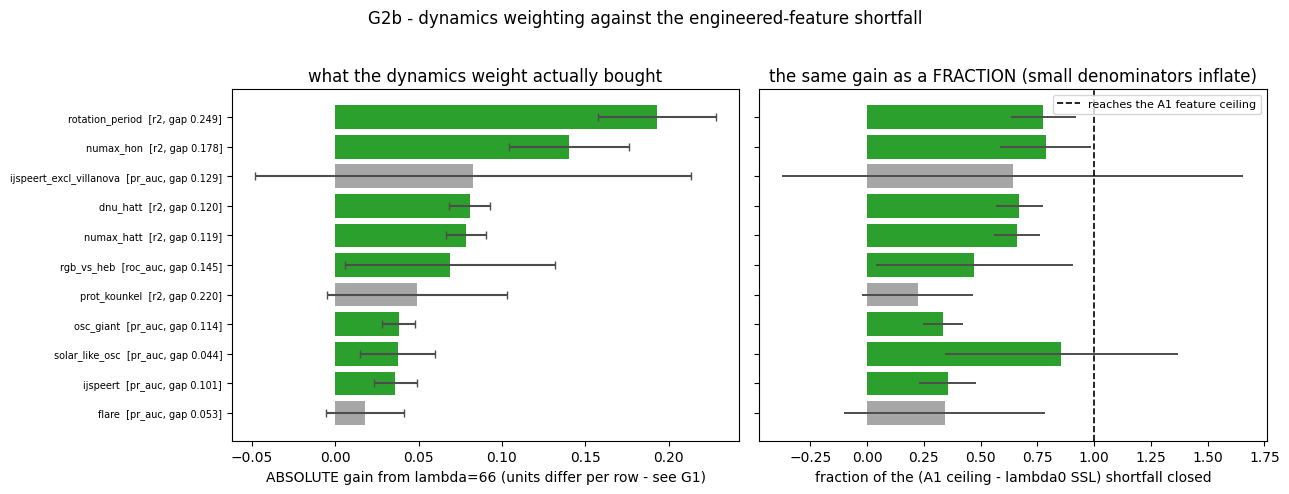

,task,metric,off_mean,dyn_mean,A1_feats,denom,delta_lambda_mean,frac_gap_to_A1_closed,frac_lo,frac_hi,claimable
0,rotation_period,r2,0.455,0.648,0.703,0.249,0.193,0.776,0.633,0.919,True
1,numax_hon,r2,0.653,0.793,0.831,0.178,0.140,0.786,0.584,0.988,True
2,ijspeert_excl_villanova,pr_auc,0.178,0.260,0.307,0.129,0.083,0.642,-0.374,1.658,False
3,dnu_hatt,r2,0.741,0.822,0.861,0.120,0.081,0.671,0.569,0.773,True
4,numax_hatt,r2,0.751,0.830,0.870,0.119,0.079,0.660,0.559,0.761,True
5,rgb_vs_heb,roc_auc,0.613,0.682,0.758,0.145,0.069,0.472,0.039,0.905,True
6,prot_kounkel,r2,0.298,0.347,0.518,0.220,0.049,0.223,-0.021,0.468,False
7,osc_giant,pr_auc,0.807,0.845,0.920,0.114,0.038,0.336,0.249,0.423,True
8,solar_like_osc,pr_auc,0.276,0.313,0.320,0.044,0.038,0.855,0.342,1.369,True
9,ijspeert,pr_auc,0.407,0.443,0.508,0.101,0.036,0.355,0.228,0.481,True


In [46]:
# G2b - how much of the lambda=0 -> A1 shortfall does the dynamics weight close?
# The fraction alone is misleading: it rewards a SMALL denominator. solar_like_osc ranked first at
# 0.855 while gaining +0.038 absolute; rotation_period ranked third at 0.776 while gaining +0.193 --
# five times more. Both panels are drawn now, sorted by the absolute gain, with the existing 2*SE
# propagated through the ratio so the unstable rows are visible as wide bars.
if transfer is not None and "frac_gap_to_A1_closed" in transfer.columns:
    fr = transfer.dropna(subset=["frac_gap_to_A1_closed"]).copy()
    fr["denom"] = fr["A1_feats"] - fr["off_mean"]
    fr["frac_lo"] = (fr["delta_lambda_mean"] - fr["delta_2se"]) / fr["denom"]
    fr["frac_hi"] = (fr["delta_lambda_mean"] + fr["delta_2se"]) / fr["denom"]
    fr = fr.sort_values("delta_lambda_mean")
    colors = ["tab:green" if c else "0.65" for c in fr["claimable"]]
    yy = np.arange(len(fr))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
    axes[0].barh(yy, fr["delta_lambda_mean"], xerr=fr["delta_2se"], color=colors,
                 error_kw={"ecolor": "0.3", "capsize": 3})
    axes[0].set_xlabel("ABSOLUTE gain from lambda=66 (units differ per row - see G1)")
    axes[0].set_title("what the dynamics weight actually bought")
    axes[1].barh(yy, fr["frac_gap_to_A1_closed"], color=colors)
    axes[1].hlines(yy, fr["frac_lo"], fr["frac_hi"], color="0.3", lw=1.4)
    axes[1].axvline(1.0, color="k", ls="--", lw=1.2, label="reaches the A1 feature ceiling")
    axes[1].set_xlabel("fraction of the (A1 ceiling - lambda0 SSL) shortfall closed")
    axes[1].set_title("the same gain as a FRACTION (small denominators inflate)")
    axes[1].legend(fontsize=8)
    axes[0].set_yticks(yy)
    axes[0].set_yticklabels([f"{t}  [{m}, gap {d:.3f}]" for t, m, d
                             in zip(fr["task"], fr["metric"], fr["denom"])], fontsize=7)
    fig.suptitle("G2b - dynamics weighting against the engineered-feature shortfall", y=1.02)
    plt.tight_layout(); fig.savefig(figs_dir / "G2b_gap_closed.png", dpi=120, bbox_inches="tight"); plt.show()

    display(fr[["task", "metric", "off_mean", "dyn_mean", "A1_feats", "denom",
                "delta_lambda_mean", "frac_gap_to_A1_closed", "frac_lo", "frac_hi",
                "claimable"]].sort_values("delta_lambda_mean", ascending=False).round(3)
            .reset_index(drop=True))

#### Plain-English read of G2b — and why the fraction alone misleads

**The idea.** If engineered features are the ceiling and SSL at λ=0 is the floor, what fraction of that
shortfall does turning the dynamics weight up recover? `frac_gap_to_A1_closed = Δλ ÷ (A1 − SSL λ=0)`.

**Problem — the denominator is the story, and the fraction hides it.** The metric rewards a *small*
gap. The old chart's ranking:

| probe | absolute gain | gap to A1 | fraction | old rank |
|---|---|---|---|---|
| solar_like_osc | **+0.038** | 0.044 | **0.855** | **1st** |
| rotation_period | **+0.193** | 0.249 | 0.776 | 3rd |
| numax_hon | +0.140 | 0.178 | 0.786 | 2nd |

`solar_like_osc` ranked first while gaining **five times less** than `rotation_period`, purely because
its ceiling was close to start with. This is the same pathology recorded for the trained-untrained gap
metric: **select on the absolute number, report the fraction as context.**

**Second problem — no uncertainty, despite `delta_2se` sitting in the same file.** Propagating it
through the ratio shows how unstable the small-denominator rows are:

| probe | fraction | 2·SE band |
|---|---|---|
| solar_like_osc | 0.855 | **[0.34, 1.37]** |
| ijspeert_excl_villanova | 0.642 | **[−0.37, 1.66]** |
| flare | 0.341 | [−0.10, 0.78] |
| rotation_period | 0.776 | [0.63, 0.92] |
| numax_hatt | 0.660 | [0.56, 0.76] |

The top-ranked bar in the old chart had a band spanning from "closed a third" to "overshot the ceiling".
Both panels are now drawn side by side, sorted by absolute gain, with the band shown and the
denominator printed in each label.

,arm,window_pr_auc,window_roc_auc,within_star_auc,n_test_pos,n_test,run_id,group
0,comb_off_s0,0.0854,0.7247,0.6565,90,4899,20260725T144635,comb_off
1,comb_off_s1,0.0936,0.7470,0.6772,90,4899,20260725T144635,comb_off
2,comb_off_s2,0.0542,0.6854,0.6207,90,4899,20260725T144635,comb_off
3,comb_off_s3,0.0459,0.6727,0.5886,90,4899,20260725T144635,comb_off
4,comb_fbwd_c1p0_s0,0.0899,0.7928,0.7235,90,4899,20260725T144635,comb_fbwd_c1p0
5,comb_fbwd_c1p0_s1,0.2014,0.8343,0.7900,90,4899,20260725T144635,comb_fbwd_c1p0
6,comb_fbwd_c1p0_s2,0.0998,0.8265,0.7813,90,4899,20260725T144635,comb_fbwd_c1p0
7,comb_fbwd_c1p0_s3,0.0595,0.7493,0.7302,90,4899,20260725T144635,comb_fbwd_c1p0
8,untrained,0.1392,0.7308,0.6318,90,4899,20260725T144635,untrained


,metric,off_lam0,dyn_lam66,untrained,paired_delta,delta_2se,survives_2SE,beats_untrained
0,window_pr_auc,0.0698,0.1126,0.1392,0.0428,0.0468,False,False
1,window_roc_auc,0.7074,0.8007,0.7308,0.0933,0.0328,True,True
2,within_star_auc,0.6357,0.7563,0.6318,0.1205,0.0407,True,True


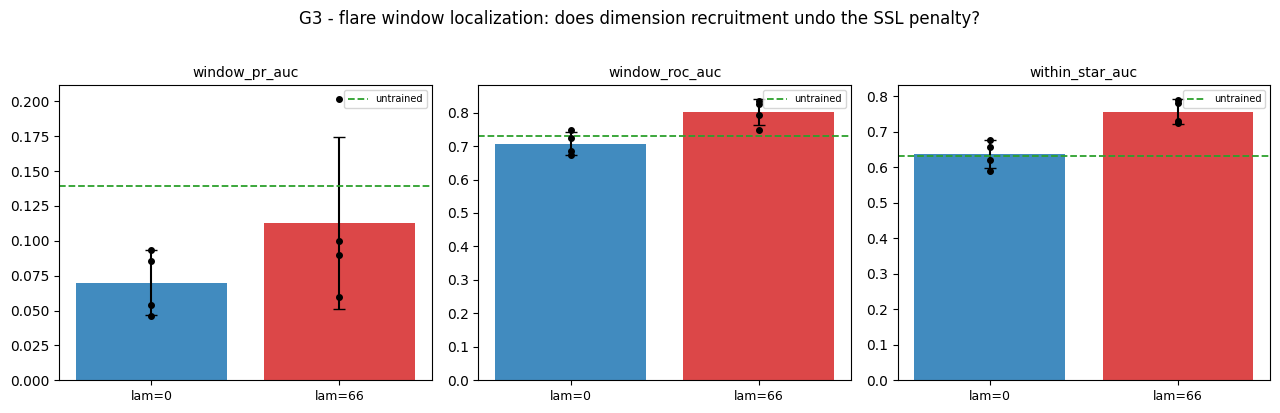

window_pr_auc    lam0 0.0698 -> lam66 0.1126 (d=+0.0428 +-0.0468, NOT gated) | untrained 0.1392 -> still below
window_roc_auc   lam0 0.7074 -> lam66 0.8007 (d=+0.0933 +-0.0328, gated) | untrained 0.7308 -> BEATS
within_star_auc  lam0 0.6357 -> lam66 0.7563 (d=+0.1205 +-0.0407, gated) | untrained 0.6318 -> BEATS


In [47]:
# G3 - flare Level B: window-level localization (the known readout-barrier twin of transit).
# The previous version printed the raw per-seed table, stated the exp03 result, asked "whether
# dimension recruitment changes that" -- and never computed the answer. It is computed here: paired
# by seed against the lambda=0 arm, with the same >2*SE gate the rest of the notebook uses, and
# against the untrained encoder in absolute terms.
flare_path = NEWTASK / "flare_window_eval.csv"
if flare_path.exists():
    fl = pd.read_csv(flare_path)
    fl["group"] = fl["arm"].str.replace(r"_s\d$", "", regex=True)
    FLARE_METRICS = ["window_pr_auc", "window_roc_auc", "within_star_auc"]
    display(fl.round(4))

    off_f = fl[fl["group"] == "comb_off"].sort_values("arm")
    dyn_f = fl[fl["group"] == "comb_fbwd_c1p0"].sort_values("arm")
    unt_f = fl[fl["group"] == "untrained"]
    rows = []
    for m in FLARE_METRICS:
        d = dyn_f[m].to_numpy() - off_f[m].to_numpy()
        se2 = 2 * d.std(ddof=1) / np.sqrt(len(d))
        rows.append({"metric": m, "off_lam0": off_f[m].mean(), "dyn_lam66": dyn_f[m].mean(),
                     "untrained": float(unt_f[m].iloc[0]), "paired_delta": d.mean(), "delta_2se": se2,
                     "survives_2SE": abs(d.mean()) > se2,
                     "beats_untrained": dyn_f[m].mean() > float(unt_f[m].iloc[0])})
    flare_verdict = pd.DataFrame(rows)
    display(flare_verdict.round(4))

    fig, axes = plt.subplots(1, len(FLARE_METRICS), figsize=(4.3 * len(FLARE_METRICS), 4.0))
    for ax, m in zip(axes, FLARE_METRICS):
        for i, (grp, colour) in enumerate([("comb_off", "tab:blue"), ("comb_fbwd_c1p0", "tab:red")]):
            v = fl[fl["group"] == grp][m]
            ax.bar(i, v.mean(), yerr=v.std(), capsize=4, color=colour, alpha=0.85)
            ax.scatter([i] * len(v), v, color="k", s=16, zorder=3)     # every seed
        ax.axhline(float(unt_f[m].iloc[0]), color="tab:green", ls="--", lw=1.3, label="untrained")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["lam=0", "lam=66"], fontsize=9)
        ax.set_title(m, fontsize=10); ax.legend(fontsize=7)
    fig.suptitle("G3 - flare window localization: does dimension recruitment undo the SSL penalty?", y=1.02)
    plt.tight_layout(); fig.savefig(figs_dir / "G3_flare_window.png", dpi=120, bbox_inches="tight"); plt.show()

    for r in flare_verdict.itertuples(index=False):
        print(f"{r.metric:16s} lam0 {r.off_lam0:.4f} -> lam66 {r.dyn_lam66:.4f} "
              f"(d={r.paired_delta:+.4f} +-{r.delta_2se:.4f}, {'gated' if r.survives_2SE else 'NOT gated'}) "
              f"| untrained {r.untrained:.4f} -> {'BEATS' if r.beats_untrained else 'still below'}")
else:
    print(f"PENDING: {flare_path} not found (run swm.eval.flare_window_eval on the exp05 cache dir)")

#### Plain-English read of G3 — and the answer the cell never computed

**What "Level B" means.** Every other probe asks a *star-level* question ("does this star flare?").
This one asks a *window-level* one: given the 256-cadence windows of a flaring star, can the readout
point at the windows that actually contain the flare? That is localization, and it is the same problem
transit has — a rare, short event diluted by averaging μ over all of a star's windows.

**Why it mattered.** The new-task scorecard found SSL *hurting* here: on the exp03 recipe the trained
encoder scored ≈0.05 window PR-AUC against **0.139 for an untrained one**. The cell asked whether
exp05's dimension recruitment changes that — and then printed a raw table and stopped. Computed:

| metric | λ=0 | λ=66 | paired Δ ± 2·SE | gated? | untrained | beats it? |
|---|---|---|---|---|---|---|
| window_pr_auc | 0.0698 | 0.1126 | +0.043 ± 0.047 | **no** | 0.1392 | no |
| window_roc_auc | 0.7074 | 0.8007 | **+0.093 ± 0.033** | **yes** | 0.7308 | **yes** |
| within_star_auc | 0.6357 | 0.7563 | **+0.121 ± 0.041** | **yes** | 0.6318 | **yes** |

**The answer is a qualified yes.** On the two ranking metrics the dynamics weight both clears the seed
gate *and* overtakes the untrained encoder — `within_star_auc` 0.632 → **0.756**, which reverses the
scorecard's "SSL hurts flare localization" finding on that measure. On window PR-AUC it improves by
+0.043 but **misses the gate and still sits below untrained (0.113 vs 0.139)**.

**Problem — the seed spread on window PR-AUC is enormous.** λ=66 gives `[0.090, 0.201, 0.100, 0.060]`,
a 3.4× range, which is why the largest relative improvement in the table is the one that fails. With 90
positive windows in 4,899, PR-AUC is dominated by the ranking of a handful of windows and is the least
stable of the three metrics; ROC-AUC and within-star AUC use the whole ranking and are far tighter. A
claim should be made on those, with the PR-AUC number reported as unresolved rather than quietly
averaged.

curve panels : ['rgb_vs_heb', 'ijspeert', 'ijspeert_excl_villanova']
regression panels (were silently dropped before): ['prot_kounkel']
showing seed 0 only -- these are the SMALL probes, so seed spread is large; see G1 for all four.


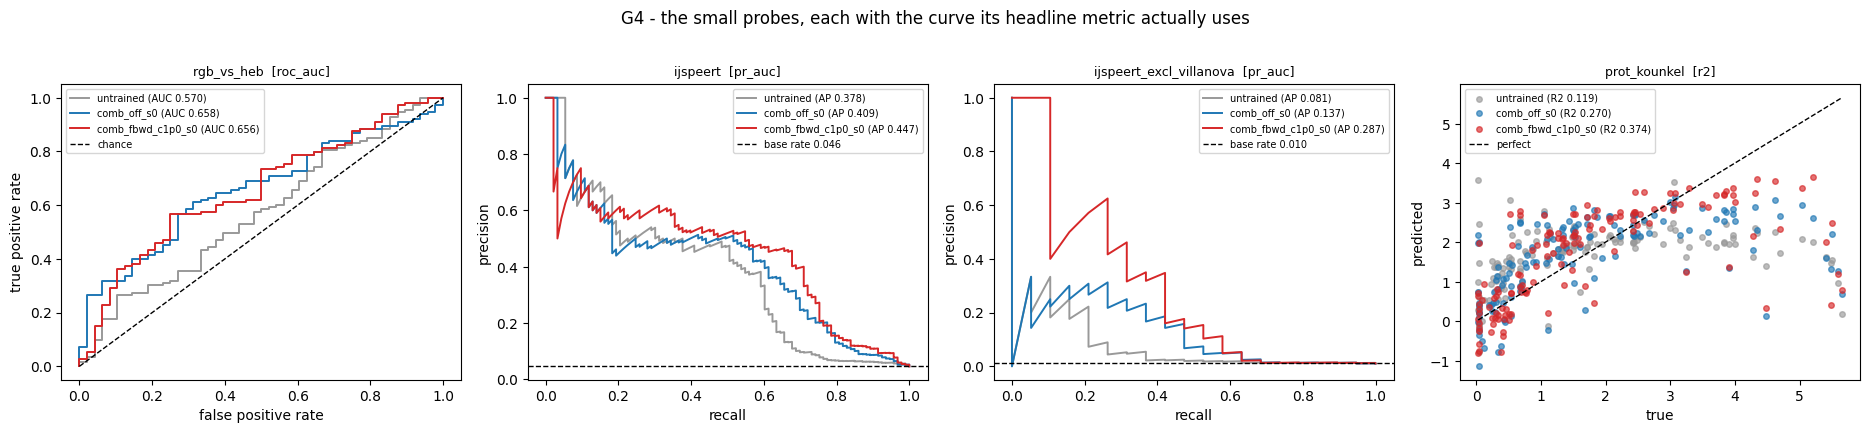

In [48]:
# G4 - curves for the probes where a single scalar misleads.
# Two fixes. (1) The previous version kept only probes whose y is binary and SILENTLY dropped the rest,
# so `prot_kounkel` -- explicitly listed as needing this treatment -- never appeared and nothing said so.
# (2) It drew a PR curve and reported AP for `rgb_vs_heb`, whose headline metric is ROC-AUC, so its
# legend (AP 0.813) disagreed with its own G2 bar (0.682). Each probe now gets the curve that matches
# its metric, and regression probes get predicted-vs-true.
from sklearn.metrics import roc_curve, roc_auc_score, r2_score

dump_path = NEWTASK / "per_star_scores.parquet"
if dump_path.exists() and transfer is not None:
    dump = pd.read_parquet(dump_path)
    small = ["rgb_vs_heb", "prot_kounkel", "ijspeert", "ijspeert_excl_villanova"]
    meta = transfer.set_index("task")["metric"].to_dict()
    ARMS = [("untrained", "0.6"), (f"comb_off_s{PANEL_SEED}", "tab:blue"),
            (f"comb_fbwd_c1p0_s{PANEL_SEED}", "tab:red")]
    curves = [t for t in small if meta.get(t) in ("pr_auc", "roc_auc")]
    regress = [t for t in small if meta.get(t) == "r2"]
    print(f"curve panels : {curves}")
    print(f"regression panels (were silently dropped before): {regress}")
    print(f"showing seed {PANEL_SEED} only -- these are the SMALL probes, so seed spread is large; "
          f"see G1 for all four.")

    fig, axes = plt.subplots(1, len(curves) + len(regress),
                             figsize=(4.7 * (len(curves) + len(regress)), 4.2))
    axes = np.atleast_1d(axes)
    for ax, task in zip(axes, curves):
        for arm, colour in ARMS:
            d = dump[(dump["task"] == task) & (dump["arm"] == arm) & (dump["pooling"] == "mean")]
            if d.empty:
                continue
            if meta[task] == "roc_auc":
                fpr, tpr, _ = roc_curve(d["y"], d["score"])
                ax.plot(fpr, tpr, color=colour, lw=1.4,
                        label=f"{arm} (AUC {roc_auc_score(d['y'], d['score']):.3f})")
            else:
                pr, rc, _ = precision_recall_curve(d["y"], d["score"])
                ax.plot(rc, pr, color=colour, lw=1.4,
                        label=f"{arm} (AP {average_precision_score(d['y'], d['score']):.3f})")
        if meta[task] == "roc_auc":
            ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
            ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
        else:
            base = dump[(dump["task"] == task) & (dump["arm"] == "untrained")]["y"].mean()
            ax.axhline(base, color="k", ls="--", lw=1, label=f"base rate {base:.3f}")
            ax.set_xlabel("recall"); ax.set_ylabel("precision")
        ax.set_title(f"{task}  [{meta[task]}]", fontsize=9); ax.legend(fontsize=7)
    for ax, task in zip(axes[len(curves):], regress):
        for arm, colour in ARMS:
            d = dump[(dump["task"] == task) & (dump["arm"] == arm) & (dump["pooling"] == "mean")]
            if d.empty:
                continue
            ax.scatter(d["y"], d["score"], s=16, alpha=0.65, color=colour,
                       label=f"{arm} (R2 {r2_score(d['y'], d['score']):.3f})")
        lim = [float(d["y"].min()), float(d["y"].max())]
        ax.plot(lim, lim, "k--", lw=1, label="perfect")
        ax.set_xlabel("true"); ax.set_ylabel("predicted")
        ax.set_title(f"{task}  [r2]", fontsize=9); ax.legend(fontsize=7)
    fig.suptitle("G4 - the small probes, each with the curve its headline metric actually uses", y=1.02)
    plt.tight_layout(); fig.savefig(figs_dir / "G4_pr_curves.png", dpi=120, bbox_inches="tight"); plt.show()
else:
    print(f"PENDING: {dump_path} (re-run the scorecard with --dump-scores)")

#### Plain-English read of G4

**Why curves and not numbers.** These four probes are the small ones — 161, 138, 93 and ~19 test
positives. A single scalar can hide whether a model is good at high precision and bad at high recall,
or simply noisy. The curve shows the shape.

**What it shows.** On `ijspeert_excl_villanova` — the honest, non-overlapping hot-EB read (§G5) — λ=66
reaches ~0.6 precision at 0.25 recall against a **1.0% base rate**, while untrained is barely off the
floor. That is a 25× lift and the strongest relative result on the whole menu, despite the smallest
absolute number in G2. On `ijspeert` the three arms are nearly on top of each other up to 0.4 recall,
which is the ~80% Villanova overlap showing through.

**Problem 1 — the panel silently dropped a probe it was built for.** The filter kept only probes whose
`y` has two unique values, so `prot_kounkel` (a regression target, 137 distinct periods) vanished with
no message. It is on the four-probe list precisely because it has 138 test stars. Regression probes now
get a predicted-vs-true panel, and the skip list is printed.

**Problem 2 — the wrong metric for `rgb_vs_heb`.** It is scored by **ROC-AUC** everywhere else in this
section, but G4 drew a PR curve and put **AP 0.813** in its legend while the G2 bar for the same arm
and task reads **0.682**. Two different numbers for one cell, with nothing marking them as different
quantities. Each probe now gets the curve matching its own headline metric, with the metric in the
panel title.

**Problem 3 — one seed, on the probes chosen for being noisy.** All curves are `PANEL_SEED` only. That
is now stated on the panel rather than left implicit; G1 carries the four-seed view.

### G4b — why the engineered-feature ceilings win, and what that does and does not mean

The A1/A2 ceilings **beat the frozen SSL representation on every downstream probe**. That is the honest
headline and it caps what this project can claim: on this menu, 25 classic light-curve features with the
same linear readout are simply better than the learned representation.

Part of the gap is an **input-geometry asymmetry**, which the cell below quantifies rather than asserts:

* A1/A2 features are computed on the star's **concatenated first segment** — up to 5.7 days — so their
  periodogram resolves low frequencies directly.
* The encoder sees **256-cadence windows = 8.53 hours**, and per-star μ is the **mean over windows**,
  which discards phase across windows. One window resolves only oscillations above **32.6 µHz**.

That penalises a **substantial minority** of the asteroseismic sample — **37.5% of Hon and 17.1% of Hatt
oscillators** have periods longer than one window (Hon's median, 35.5 µHz, sits just above the cutoff, so
a large fraction are near the boundary where resolution is poor rather than absent). The penalty is
sharper for the long-period regression targets (`prot_kounkel`, `rotation_period`: periods of *days*,
far beyond any single window).

**But geometry does not explain the deficit away.** Most oscillators *are* resolvable within a window,
and `flare` — a short transient that comfortably fits — still loses (A1 0.474 / A2 0.562 vs SSL ≈ 0.44).
The honest reading is that the frozen representation is genuinely weaker than engineered features on this
menu, with a secondary geometry handicap at low frequency.

**Consequence.** "Beats engineered features" is **not** claimable from this evidence, and the paper
should not attempt it. The defensible claims are the internal ones — dynamics-weighted SSL > dynamics-off
SSL (criterion 1), and SSL > capacity-matched untrained. A fair external test needs a longer window or a
segment-level encoder, which is a concrete exp06 lever rather than a vague one.

In [49]:
# G4b - the arithmetic behind the caveat, computed rather than asserted
WINDOW, CADENCE_MIN = 256, 2.0
window_hours = WINDOW * CADENCE_MIN / 60.0
numax_cut_uhz = 1e6 / (window_hours * 3600)     # nu_max whose period exactly equals one window
print(f"one window = {WINDOW} x {CADENCE_MIN:.0f} min = {window_hours:.2f} h "
      f"-> resolves oscillations only above {numax_cut_uhz:.1f} uHz")

nt = pd.read_csv(root / "labels" / "new_task_labels_star.csv")
pool = pd.read_parquet(root / "processed" / "subset" / "new_task_pool.parquet")
inpool = nt[nt["tic_id"].isin(pool["tic_id"])]
for col in ["numax_hon", "numax_hatt"]:
    v = pd.to_numeric(inpool[col], errors="coerce").dropna()
    if len(v):
        frac = float((v < numax_cut_uhz).mean())
        print(f"  {col:12s} n={len(v):5d}  median {v.median():6.1f} uHz  "
              f"-> {100*frac:5.1f}% have periods LONGER than one window (encoder cannot resolve them)")

one window = 256 x 2 min = 8.53 h -> resolves oscillations only above 32.6 uHz
  numax_hon    n= 8789  median   35.5 uHz  ->  37.5% have periods LONGER than one window (encoder cannot resolve them)
  numax_hatt   n= 2757  median   53.7 uHz  ->  17.1% have periods LONGER than one window (encoder cannot resolve them)


### G5 — the Ijspeert caveat, stated rather than buried

`ijspeert2024` is a catalog of hot (OBA-type) eclipsing binaries, scored here on the frozen v1 subset
(572 stars, 93 in test) because only 88 of its stars fall inside the new-task pool — using the pool would
have required a rebuild that invalidates every other probe's split.

**It overlaps the v1 `eb` task heavily**: 753 of its 1,903 corpus TICs are also Villanova EBs, and on the
v1 test split the overlap is heavier still — **74 of 93 positives (~80%)**. So the `ijspeert` row is
largely the `eb` task asked a second way. The `ijspeert_excl_villanova` row removes every Villanova EB
from both classes and is the honest independent read — but it has only ~19 test positives, which is why
it carries a bootstrap CI and should be treated as indicative, not conclusive.

The v1 `eb` label itself is untouched — ADR-0007's single-source rule stands.

---
## H. MIL (window_score × logistic) confirmation — pending

The MIL second protocol is being confirmed on exp05 in a **separate session/notebook**. This section is a
placeholder that renders as soon as that session's CSV lands; until then it prints its status and moves on.

Background: ADR-0008-lite says MIL helps **localized** tasks (eb, transit) and actively hurts pulsating —
established on the exp03 recipes at λ=0. exp05 works by *recruiting latent dimensions* (5 → 25 active),
so there is a real mechanistic reason MIL's value could shift with λ; that is what the other session tests.

Expected inputs (either will render):
`experiments/exp05_mil_confirm.csv` · `experiments/new_task_exp05/mil_confirm.csv`

In [50]:
mil_candidates = [root / "experiments" / "exp05_mil_confirm.csv",
                  NEWTASK / "mil_confirm.csv"]
mil_path = next((p for p in mil_candidates if p.exists()), None)

if mil_path is None:
    print("PENDING - MIL confirmation not yet available. Looked for:")
    for p in mil_candidates:
        print("   ", p)
    print("\nThis section will render automatically once that session writes its CSV.")
else:
    mil = pd.read_csv(mil_path)
    print(f"loaded {mil_path.name}: {len(mil)} rows")
    display(mil.round(4))

    if {"task", "pooling"}.issubset(mil.columns) and "gap" in mil.columns:
        piv = mil.pivot_table(index="task", columns="pooling", values="gap")
        if {"mean", "window_score"}.issubset(piv.columns):
            piv["MIL_advantage"] = piv["window_score"] - piv["mean"]
            fig, ax = plt.subplots(figsize=(8, 4))
            colors = ["tab:green" if v > 0 else "tab:red" for v in piv["MIL_advantage"]]
            ax.bar(piv.index, piv["MIL_advantage"], color=colors)
            ax.axhline(0, color="k", lw=1)
            ax.set_ylabel("window_score gap  -  mean-pool gap")
            ax.set_title("H - is MIL the better eval shape under dynamics weighting?")
            plt.tight_layout(); plt.show()
            display(piv.round(4))

PENDING - MIL confirmation not yet available. Looked for:
    C:\git_repo\Stellar-World-Model\experiments\exp05_mil_confirm.csv
    C:\git_repo\Stellar-World-Model\experiments\new_task_exp05\mil_confirm.csv

This section will render automatically once that session writes its CSV.


---
## Summary

| # | Finding | Status |
|---|---|---|
| A1 | 48/48 runs reached epoch 59; 2 were killed and resumed, so their W&B history is stitched from two pieces | clean |
| A2 | **44/48 runs were still improving at the freeze** — `max_epochs=60` truncates training | under-run, as exp03 H5 |
| A3 | 0 NaN/Inf in any logged metric | clean |
| A4 | `fwd`/`fwd+bwd` **overshoot** their λ target (~1.31 vs 1.0); `multistep` **undershoots** (0.63) | calibration limitation |
| A6 | Spearman(λ, selected epoch) = +0.16, p=0.29 → checkpoint selection is λ-independent as designed | flag works |
| B1 | **Collapse-reversal**: 5.0 ± 0.0 active units at λ=0 → 17.3 ± 13.6 (`fwd λ130`) → 25.5 ± 15.0 (`fwd+bwd λ66`) | mechanism, but **highly seed-variable** |
| D1b | **Every rotation positive in the subset is also transit/eb/pulsating**; no quiet star is rotation-positive | qualifies the rotation headline |
| E | **Criterion 1 MET** — dynamics-weighted SSL > dynamics-off SSL; `fwd+bwd` best. "Higher λ → bigger gain" is task-dependent, not monotone (eb peaks at λ20) | headline |
| F | **Criterion 2 PARTIAL** — rollout beats persistence everywhere, but the periodic > quiet ordering did not appear | exp06 target |
| G | Downstream transfer of the λ gain, against untrained *and* engineered-feature ceilings | this session |
| H | MIL confirmation | separate session |

**What this notebook does not establish.** There is no B1 supervised ceiling, so nothing here speaks to
how much of the *achievable* gap the representation closes. The downstream pool is prevalence-inflated
~16×, so absolute PR-AUCs are not survey-scale. The collapse-reversal magnitude is not a stable quantity
across seeds — only its direction is. And criterion 2 remains open: the rollout has learned that smooth
signals are predictable, not that stars are periodic.